# Temporal steering with transcoders

This notebook generates **circuit graphs** that explain how a language model produces temporal answers (e.g., "Who won X in 2020?"). It uses transcoders (SAEs) to decompose the model into sparse feature activations, then attributes logit scores to those features via the [circuit_tracer](https://github.com/Anthropics/circuit-tracer) pipeline. The graphs capture which transcoder features drive model predictions, enabling analysis of temporally-specific vs. invariant representations.


## Environment setup

Set Hugging Face cache directories and change to the project root (e.g. `lora-finetuning-saes`). This ensures models, datasets, and transcoders are loaded from the correct paths. Run this cell first.

In [1]:
import os
os.environ['HF_HOME'] = '/g/data4/sz65/sg9944/hugging_face_cache'

# Set specific cache directories (optional, but good for fine-grained control)
os.environ['HF_DATASETS_CACHE'] = '/g/data4/sz65/sg9944/hugging_face_cache_data'
os.environ['TRANSFORMERS_CACHE'] = '/g/data4/sz65/sg9944/hugging_face_cache'
os.environ['HF_HUB_CACHE'] = '/g/data4/sz65/sg9944/hugging_face_cache/hub'
hugging_face_cache_dir = '/g/data4/sz65/sg9944/hugging_face_cache'
new_directory_path = '/g/data4/sz65/sg9944/act_study/lora-finetuning-saes/'
# os.environ["HF_HUB_OFFLINE"] = "1"
os.chdir(new_directory_path)


## Imports

Import `circuit_tracer` (for `ReplacementModel`, `attribute`, `create_graph_files`), `pandas`, `torch`, and project utilities. The `ReplacementModel` wraps a base model with transcoders to produce sparse latent activations.

In [2]:
from pathlib import Path
import torch
import pandas as pd
from alib.evaluation import evaluation_dataset

from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.utils import create_graph_files

torch.cuda.is_available()

/g/data/sz65/sg9944/activation_study_env/lib/python3.10/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-02-20 17:53:53.028580: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-20 17:53:53.783270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771570434.079670 3241906 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771570434.178256 3241906 cuda_blas.cc:1407] Unable to register cuBLA

True

First, load your model and transcoders by name. `model_name` is a normal HuggingFace / [TransformerLens](https://github.com/TransformerLensOrg/TransformerLens) model name; we'll use `google/gemma-2-2b`. We set `transcoder_name` to `gemma`, which is shorthand for the [Gemma Scope](https://arxiv.org/abs/2408.05147) transcoders; we take the transcoders with lowest L0 (mean # of active features) for each layer.

We additionally support `model_name = "meta-llama/Llama-3.2-1B"`, with `"llama"` transcoders; these are ReLU skip-transcoders that we trained, available [here](https://huggingface.co/mntss/skip-transcoder-Llama-3.2-1B-131k-nobos/tree/new-training).

If you want to use other models, you'll have to provide your own transcoders. To do this, set `transcoder_name` to point to your own configuration file, specifying the list of transcoders that you want to use. You can see `circuit_tracer/configs` for example configs.

## Attribution parameters

Configure how the attribution pipeline builds graphs:

- **`max_n_logits`**: Maximum number of output logits to attribute (top predictions).
- **`desired_logit_prob`**: Attribution uses the fewest top logits needed to reach this cumulative probability mass (e.g. 0.95).
- **`max_feature_nodes`**: Cap on transcoder feature nodes to include; lower = faster but less complete graphs.
- **`batch_size`**: Batch size during attribution.
- **`offload`**: `'disk'`, `'cpu'`, or `None` — trade memory for speed.

In [3]:
# model_name = 'google/gemma-2-2b'
# model_short_name = model_name.split('/')[1]
# transcoder_name = "gemma"
# os.environ["HF_HUB_OFFLINE"] = "1"

# model = ReplacementModel.from_pretrained(model_name, "mntss/gemma-scope-transcoders", dtype=torch.bfloat16)
# tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')



# model_name = 'meta-llama/Llama-3.2-1B'
# transcoder_name = "mntss/transcoder-Llama-3.2-1B"
# os.environ["HF_HUB_OFFLINE"] = "1"

# model = ReplacementModel.from_pretrained(model_name, transcoder_name)
# tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')


model_name = 'Qwen/Qwen3-4B'
transcoder_name = "mwhanna/qwen3-4b-transcoders"
# os.environ["HF_HUB_OFFLINE"] = "1"

model = ReplacementModel.from_pretrained(model_name, transcoder_name, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

Fetching 36 files:   0%|          | 0/36 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer


In [4]:
# prompt = "Who is the current president of the United States of America? Answer:"  # What you want to get the graph for
max_n_logits = 10   # How many logits to attribute from, max. We attribute to min(max_n_logits, n_logits_to_reach_desired_log_prob); see below for the latter
desired_logit_prob = 0.95  # Attribution will attribute from the minimum number of logits needed to reach this probability mass (or max_n_logits, whichever is lower)
max_feature_nodes = 17000  # Only attribute from this number of feature nodes, max. Lower is faster, but you will lose more of the graph. None means no limit.
batch_size=256  # Batch size when attributing
offload= 'disk' # Offload various parts of the model during attribution to save memory. Can be 'disk', 'cpu', or None (keep on GPU)
verbose = True  # Whether to display a tqdm progress bar and timing report

# Generate graphs

In this section we generate circuit graphs for different data conditions. The data comes from **ChronosAlign**: temporal QA pairs with confidence scores from `evaluation_f1_explicit`, `correct_answer_consistency_score`, and `consistency_score_explicit`. Confidence bands (`extremely_high`, `high`, `low`) control which questions are used. Each graph is produced by `attribute()` → `graph.to_pt()` → `create_graph_files()` with `node_threshold` and `edge_threshold`. This section only needs to be run once.

In [5]:
# data = pd.read_csv('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency.csv')
# extreme_high_confidence_sample = pd.read_csv('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.csv')
# extremely_high_confidence = data[(data['evaluation_f1_explicit'] > 0.9) & (data['correct_answer_consistency_score'] < 0.5) & (data['consistency_score_explicit'] <0.5)]
# high_confidence = data[(data['evaluation_f1_explicit'] > 0.6) & (data['correct_answer_consistency_score'] < 0.5)]
# test_high_confidence = high_confidence[~high_confidence['question'].isin(extreme_high_confidence_sample['question'])]

/jobfs/157546572.gadi-pbs/ipykernel_1446480/3525468594.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency.csv')


## Generate high confidence graphs

Uses ChronosAlign questions where the model’s answer aligns well with the gold answer (`evaluation_f1_explicit > 0.6`) and there is low consistency across runs (`correct_answer_consistency_score < 0.5`). Samples per `(categories, event_year)` to cover multiple years and event types. Prompts put the year at the **start** or **end** (`new_question_start`, `new_question_end`); `attribute()` and `create_graph_files()` produce JSON graph outputs.

Data paths are under `{model_short_name}/Datasets/`. Confidence bands filter by `evaluation_f1_explicit`, `correct_answer_consistency_score`, and `consistency_score_explicit`. Samples are stratified by `categories` and `event_year` for balanced coverage.

In [ ]:
model_name

In [5]:
## Generate high confidence graphs for any model

# Set parameters
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2015
max_year = 2024

answers_with_consistency_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'
extremely_high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.json'
high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_HIGHCONFIDENCE.json'
low_confidence = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_LOWCONFIDENCE.json'
##explict_write_to = f'./{model_short_name}/Datasets/ChronosAlign_2015_2024_explicit_questions_with_answers_with_score.json'

if model_name in ['meta-llama/Llama-3.2-1B']:
    extreme_limit = 0.7
else: 
    extreme_limit = 0.9


In [12]:
data = pd.read_json(answers_with_consistency_filepath)


In [13]:
## Filter for high and low confidence answers -- We want to generate graphs that they have a strong alignment to, and test that against a set of quesiton they have high alignment with.

extremely_high_confidence = data[(data['evaluation_f1_explicit'] > extreme_limit) & (data['correct_answer_consistency_score'] < 0.5) & (data['consistency_score_explicit'] <0.5)]
high_confidence = data[(data['evaluation_f1_explicit'] > 0.6) & (data['correct_answer_consistency_score'] < 0.5)]
low_confidence = data[(data['evaluation_f1_explicit'] <= 0.6) | (data['correct_answer_consistency_score'] >= 0.5)]



print(f"Extremely High confidence samples: {len(extremely_high_confidence)}")
print(f"High confidence samples: {len(high_confidence)}")
print(f"Low confidence samples: {len(low_confidence)}")

Extremely High confidence samples: 1180
High confidence samples: 7537
Low confidence samples: 162095


In [12]:
# Sample 10 rows from each combination of category and event_year in high_confidence
high_confidence_sample = high_confidence.groupby(['categories', 'event_year'], group_keys=False).apply(
    lambda x: x.sample(n=min(3, len(x)), random_state=42)
).reset_index(drop=True)

extreme_high_confidence_sample = extremely_high_confidence.groupby(['categories', 'event_year'], group_keys=False).apply(
    lambda x: x.sample(n=min(3, len(x)), random_state=42)
).reset_index(drop=True)

high_confidence_sample.to_json(high_confidence_filepath)
extreme_high_confidence_sample.to_json(extremely_high_confidence_filepath)


In [6]:
high_confidence_sample = pd.read_json(high_confidence_filepath)
extreme_high_confidence_sample = pd.read_json(extremely_high_confidence_filepath)


In [20]:
activation_extraction = data[(data['evaluation_f1_explicit'] > 0.8) & (data['correct_answer_consistency_score'] < 0.2)]
activation_extraction[activation_extraction['event_year'] == 2020]['answer'].apply(lambda x: x[0]).unique().tolist()

['Chase Elliott',
 'Otis',
 'Asuka',
 'Lucinda Brand',
 'Berlin',
 'Puck Pieterse',
 'Tiz the Law',
 'Cameron Munster',
 'Alexa Scimeca Knierim and Brandon Frazier',
 'Drew McIntyre',
 'Alexis Lafreniere',
 'Anthony Edwards',
 'Austin Cindric',
 'Denny Hamlin',
 'Phil Heath',
 'Steve Torrence',
 'Spencer Rattler',
 'Marcus Ellis and Chris Langridge',
 'Indian Air Force',
 '140000',
 'Emmanuelle Charpentier, Jennifer Doudna',
 'Sofia Kenin',
 '3,484 km',
 'Naomi Osaka',
 'Lee Wai Sze',
 '31–20',
 '34',
 'Tyson Fury',
 'Kamaru Usman',
 'Trevor Bauer',
 'Cuca',
 'Dustin Johnson',
 '12',
 'Columbus Crew SC',
 'Royal Troon',
 'Lee Johnson',
 'Jordan Walker',
 'TPC Harding Park',
 'Tom Brady',
 'Anthony Hopkins',
 'LeBron James',
 'Jamie Maclaren',
 'Carlton',
 'Chloé Zhao',
 'Stefan Küng',
 '10000',
 'Benevento',
 'Borussia Dortmund II',
 'Golden Sixty',
 'Annemiek van Vleuten',
 'Stockholm',
 'Al-Hilal',
 'Elisa Longo Borghini',
 'John McPhee',
 'Attila Valter',
 'Arsenal',
 'Erling Haalan

In [14]:
extreme_high_confidence_sample.groupby('event_year').count()

,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,url,...,relative_question,id,prompt,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer,evaluation_f1_explicit,correct_answer_consistency_score,consistency_score_explicit
event_year,,,,,,,,,,,,,,,,,,,,,
2015,0,7,7,7,7,0,0,2,2,7,...,7,7,7,7,7,7,7,7,7,7
2016,0,8,8,8,8,0,0,2,2,8,...,8,8,8,8,8,8,8,8,8,8
2017,1,7,7,7,7,0,0,2,2,7,...,7,7,7,7,7,7,7,7,7,7
2018,1,7,7,7,7,0,0,1,1,7,...,7,7,7,7,7,7,7,7,7,7
2019,0,6,6,6,6,0,0,1,1,6,...,6,6,6,6,6,6,6,6,6,6
2020,3,6,6,6,6,0,0,3,3,6,...,6,6,6,6,6,6,6,6,6,6
2021,0,6,6,6,6,0,0,1,1,6,...,6,6,6,6,6,6,6,6,6,6
2022,1,6,6,6,6,0,0,3,3,6,...,6,6,6,6,6,6,6,6,6,6
2023,2,5,5,5,5,0,0,2,2,5,...,5,5,5,5,5,5,5,5,5,5


In [15]:
## Generate time at the start.
extreme_high_confidence_sample['new_question_start'] = extreme_high_confidence_sample.apply(lambda x: f"In {x['event_year']}, {x['new_question']} Answer:", axis=1)

## Generate time at the end.
extreme_high_confidence_sample['new_question_end'] = extreme_high_confidence_sample.apply(lambda x: f"{x['new_question'].replace('?', '')} in {x['event_year']}? Answer:", axis=1)



In [ ]:
# ## Regen procedure
# from circuit_tracer import graph as graph_class
# confidence_type = 'extreme_2015'
# graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}")
# # graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}_archive")


# graph_file_dir = f"./{model_short_name}/CircuitTracerGraphs/files_{confidence_type}"
# question_set_name = 'new_question_start'
# temporal_position = question_set_name.split('_')[2]

# for index, question in extreme_high_confidence_sample.iterrows():
#     # print("processing")
#     graph_id = f"{question['subject'][0].replace(' ','')}_{question['relationship'].replace(' ','')}_{temporal_position}"
#     graph_name = f'{graph_id}.pt'
#     graph_dir.mkdir(exist_ok=True)
#     graph_path = graph_dir / graph_name

#     json_graph_path = Path(graph_file_dir) / f'{graph_id}.json'
    
#     text = question[question_set_name]
    
#     # Don't recreate any old ones
#     if graph_path.exists():
#         print(f'{graph_path}')
#         with open(json_graph_path, 'r') as f:
#             graph_json = json.load(f)
#             if (text == graph_json['metadata']['prompt'].replace('<|begin_of_text|>', '')) == False:
#                 continue
#         # continue
       
        
    
#         # try:
#         graph = attribute(
#             prompt=text,
#             model=model,
#             max_n_logits=max_n_logits,
#             desired_logit_prob=desired_logit_prob,
#             batch_size=batch_size,
#             max_feature_nodes=max_feature_nodes,
#             offload=offload,
#             verbose=verbose
#         )
    
#         graph.to_pt(graph_path)
#         # graph = graph_class.from_pt(graph_path)
#         # slug = "current-us-president"  # this is the name that you assign to the graph
#         # node_threshold=0.8  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
#         # edge_threshold=0.98  # keep only the minimum # of edges whose cumulative influence is >= 0.98
        
#         # create_graph_files(
#         #     graph_or_path=graph_path,  # the graph to create files for
#         #     slug=graph_id,
#         #     output_path=graph_file_dir,
#         #     node_threshold=node_threshold,
#         #     edge_threshold=edge_threshold
#         # )
#     # except:
#     #     print(graph_path)

In [16]:
from circuit_tracer import graph as graph_class
confidence_type = 'extreme_2015'
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}")
graph_file_dir = f"./{model_short_name}/CircuitTracerGraphs/files_{confidence_type}"
question_set_name = 'new_question_start'
temporal_position = question_set_name.split('_')[2]

for index, question in extreme_high_confidence_sample.iterrows():
    # print("processing")
    graph_id = f"{question['subject'][0].replace(' ','')}_{question['relationship'].replace(' ','')}_{temporal_position}"
    graph_name = f'{graph_id}.pt'
    graph_dir.mkdir(exist_ok=True)
    graph_path = graph_dir / graph_name

    json_graph_path = graph_dir / f'{graph_id}.json'
    
    # Don't recreate any old ones
    if graph_path.exists():
        print(f'{graph_path}')
        continue
       

    text = question[question_set_name]
    
    try:
        graph = attribute(
            prompt=text,
            model=model,
            max_n_logits=max_n_logits,
            desired_logit_prob=desired_logit_prob,
            batch_size=batch_size,
            max_feature_nodes=max_feature_nodes,
            offload=offload,
            verbose=verbose
        )
    
        graph.to_pt(graph_path)
        # graph = graph_class.from_pt(graph_path)
        # slug = "current-us-president"  # this is the name that you assign to the graph
        node_threshold=0.8  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
        edge_threshold=0.98  # keep only the minimum # of edges whose cumulative influence is >= 0.98
        
        create_graph_files(
            graph_or_path=graph_path,  # the graph to create files for
            slug=graph_id,
            output_path=graph_file_dir,
            node_threshold=node_threshold,
            edge_threshold=edge_threshold
        )
    except:
        print(graph_path)

Phase 0: Precomputing activations and vectors
Precomputation completed in 70.76s
Found 10130 active features
Phase 1: Running forward pass
Forward pass completed in 0.31s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.5444
Will include 10130 of 10130 feature nodes
Input vectors built in 3.72s
Phase 3: Computing logit attributions
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Logit attributions completed in 0.70s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 10130/10130 [00:05<00:00, 1832.93it/s]
Feature attributions completed in 5.53s
Attribution completed in 112.08s
Phase 0: Precomputing activations and vectors
Precomputation completed in 47.49s
Found 11984 active features
Phase 1: Run

Llama-3.2-1B/CircuitTracerGraphs/extreme_2015/CinemaAudioSocietyAwardforOutstandingAchievementinSoundMixingforaMotionPicture–LiveAction_winner_start.pt


Precomputation completed in 21.89s
Found 12613 active features
Phase 1: Running forward pass
Forward pass completed in 0.19s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.5908
Will include 12613 of 12613 feature nodes
Input vectors built in 3.28s
Phase 3: Computing logit attributions
Logit attributions completed in 0.20s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 12613/12613 [00:05<00:00, 2226.65it/s]
Feature attributions completed in 5.67s
Attribution completed in 62.46s
Phase 0: Precomputing activations and vectors


Llama-3.2-1B/CircuitTracerGraphs/extreme_2015/CityofStars_film_start.pt


Precomputation completed in 45.35s
Found 13111 active features
Phase 1: Running forward pass
Forward pass completed in 0.15s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.6232
Will include 13111 of 13111 feature nodes
Input vectors built in 3.30s
Phase 3: Computing logit attributions
Logit attributions completed in 0.20s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 13111/13111 [00:06<00:00, 2151.94it/s]
Feature attributions completed in 6.10s
Attribution completed in 86.53s
Phase 0: Precomputing activations and vectors


...

Precomputation completed in 4.08s
Found 10327 active features
Phase 1: Running forward pass
Forward pass completed in 0.11s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.3585
Will include 10327 of 10327 feature nodes
Input vectors built in 3.19s
Phase 3: Computing logit attributions
Logit attributions completed in 0.16s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 10327/10327 [00:03<00:00, 2709.69it/s]
Feature attributions completed in 3.81s
Attribution completed in 42.10s
Phase 0: Precomputing activations and vectors
Precomputation completed in 5.96s
Found 8809 active features
Phase 1: Running forward pass
Forward pass completed in 0.18s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.3244
Will include 8809 of 8809 feature nodes
Input vectors built in 3.13s
Phase 3: Computing logit attributions
Logit attributions completed in 0.15s
Phase 4: Computing feature attributions
Feat

Llama-3.2-1B/CircuitTracerGraphs/extreme_2015/WoutvanAert_team_start.pt


Precomputation completed in 8.28s
Found 10595 active features
Phase 1: Running forward pass
Forward pass completed in 0.11s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.4188
Will include 10595 of 10595 feature nodes
Input vectors built in 3.27s
Phase 3: Computing logit attributions
Logit attributions completed in 0.15s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 10595/10595 [00:03<00:00, 2711.99it/s]
Feature attributions completed in 3.91s
Attribution completed in 46.64s
Phase 0: Precomputing activations and vectors
Precomputation completed in 1.58s
Found 12898 active features
Phase 1: Running forward pass
Forward pass completed in 0.17s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.4230
Will include 12898 of 12898 feature nodes
Input vectors built in 3.29s
Phase 3: Computing logit attributions
Logit attributions completed in 0.19s
Phase 4: Computing feature attributions
F

Llama-3.2-1B/CircuitTracerGraphs/extreme_2015/APNFLDefensivePlayeroftheYear_winner_start.pt
Llama-3.2-1B/CircuitTracerGraphs/extreme_2015/RallyEstonia_winner_start.pt


Precomputation completed in 4.02s
Found 10954 active features
Phase 1: Running forward pass
Forward pass completed in 0.11s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.3019
Will include 10954 of 10954 feature nodes
Input vectors built in 3.22s
Phase 3: Computing logit attributions
Logit attributions completed in 0.18s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 10954/10954 [00:04<00:00, 2656.79it/s]
Feature attributions completed in 4.13s
Attribution completed in 42.80s


## Generate high confidence alternative logit

Same pipeline as high-confidence graphs, but uses samples where the **explicit** answer (year-qualified) differs from the **general** answer (`generated_explicit_answer != generated_answer`). This isolates temporal disambiguation: features that steer the model toward the year-specific answer vs. the default answer.

## Generate high confidence graphs

In [5]:
model_name

'google/gemma-2-2b'

In [6]:
## Generate high confidence graphs for any model

# Set parameters
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024

answers_with_consistency_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'
extremely_high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE_alt.json'
high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_HIGHCONFIDENCE_alt.json'
low_confidence = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_LOWCONFIDENCE_alt.json'

if model_name in ['meta-llama/Llama-3.2-1B']:
    extreme_limit = 0.7
else: 
    extreme_limit = 0.9


In [7]:
data = pd.read_json(answers_with_consistency_filepath)


In [8]:
data.columns

Index(['event_year', 'event_date', 'subject', 'relationship', 'answer',
       'question', 'raw_content', 'parse_error', 'event', 'eventLabel', 'url',
       'success', 'title', 'content', 'error', 'content_length',
       'wikipedia_url_id', 'views', 'new_question', 'categories',
       'relative_question', 'id', 'prompt', 'generated_answer',
       'evaluation_f1', 'explict_prompt', 'generated_explicit_answer',
       'evaluation_f1_explicit', 'correct_answer_consistency_score',
       'consistency_score_explicit'],
      dtype='object')

In [9]:
## Filter for high and low confidence answers -- We want to generate graphs that they have a strong alignment to, and test that against a set of quesiton they have high alignment with.

extremely_high_confidence = data[(data['evaluation_f1_explicit'] > extreme_limit) & (data['correct_answer_consistency_score'] < 0.5) & (data['consistency_score_explicit'] <0.5) & (data['generated_explicit_answer'] != data['generated_answer'])]
high_confidence = data[(data['evaluation_f1_explicit'] > 0.6) & (data['correct_answer_consistency_score'] < 0.5)]
low_confidence = data[(data['evaluation_f1_explicit'] <= 0.6) | (data['correct_answer_consistency_score'] >= 0.5)]

print(f"Extremely High confidence samples: {len(extremely_high_confidence)}")
print(f"High confidence samples: {len(high_confidence)}")
print(f"Low confidence samples: {len(low_confidence)}")

Extremely High confidence samples: 768
High confidence samples: 3631
Low confidence samples: 64854


In [10]:
# Sample 10 rows from each combination of category and event_year in high_confidence
high_confidence_sample = high_confidence.groupby(['categories', 'event_year'], group_keys=False).apply(
    lambda x: x.sample(n=min(2, len(x)), random_state=42)
).reset_index(drop=True)

extreme_high_confidence_sample = extremely_high_confidence.groupby(['categories', 'event_year'], group_keys=False).apply(
    lambda x: x.sample(n=min(2, len(x)), random_state=42)
).reset_index(drop=True)

high_confidence_sample.to_json(high_confidence_filepath)
extreme_high_confidence_sample.to_json(extremely_high_confidence_filepath)


/jobfs/157841494.gadi-pbs/ipykernel_634548/422415511.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  high_confidence_sample = high_confidence.groupby(['categories', 'event_year'], group_keys=False).apply(
/jobfs/157841494.gadi-pbs/ipykernel_634548/422415511.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extreme_high_confidence_sample = extremely_high_confidence.groupby(['categories', 'event_year'],

In [41]:
high_confidence_sample = pd.read_json(high_confidence_filepath)
extreme_high_confidence_sample = pd.read_json(extremely_high_confidence_filepath)


In [12]:
extreme_high_confidence_sample.groupby('event_year').count()

,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,url,...,relative_question,id,prompt,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer,evaluation_f1_explicit,correct_answer_consistency_score,consistency_score_explicit
event_year,,,,,,,,,,,,,,,,,,,,,
2020,0,6,6,6,6,0,0,1,1,6,...,6,6,6,6,6,6,6,6,6,6
2021,0,6,6,6,6,0,0,4,4,6,...,6,6,6,6,6,6,6,6,6,6
2022,0,6,6,6,6,0,0,4,4,6,...,6,6,6,6,6,6,6,6,6,6
2023,1,6,6,6,6,0,0,4,4,6,...,6,6,6,6,6,6,6,6,6,6
2024,0,5,5,5,5,0,0,3,3,5,...,5,5,5,5,5,5,5,5,5,5


In [25]:
import ast
## Generate time at the start.
extreme_high_confidence_sample['new_question_start'] = extreme_high_confidence_sample.apply(lambda x: f"In {x['event_year']}, {x['new_question']} Answer:", axis=1)

## Generate time at the end.
extreme_high_confidence_sample['new_question_end'] = extreme_high_confidence_sample.apply(lambda x: f"{x['new_question'].replace('?', '')} in {x['event_year']}? Answer:", axis=1)
extreme_high_confidence_sample['subject'] = extreme_high_confidence_sample['subject'].apply(lambda x: ast.literal_eval(x))

extreme_high_confidence_sample['generated_answer_tokenized'] = extreme_high_confidence_sample['generated_answer'].apply(lambda x:tokenizer.encode(x))
extreme_high_confidence_sample['generated_answer_first_token'] = extreme_high_confidence_sample['generated_answer_tokenized'].apply(lambda x:x[1])





In [27]:
extreme_high_confidence_sample['subject'] [0][0]

'Academy Award for Best Live Action Short Film'

In [20]:
tokenizer.decode([2, 42502, 25651, 235265])

'<bos>Taylor Swift.'

In [ ]:
from circuit_tracer import graph as graph_class
confidence_type = 'extreme'
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/alt_{confidence_type}")

graph_file_dir = f"./{model_short_name}/CircuitTracerGraphs/files_alt_{confidence_type}"
question_set_name = 'new_question_start'
temporal_position = question_set_name.split('_')[2]

for generation_type in ['relative', 'external']:
    for index, question in extreme_high_confidence_sample.iterrows():
        # print("processing")
        graph_id = f"{question['subject'][0].replace(' ','')}_{question['relationship'].replace(' ','')}_{generation_type}"
        graph_name = f'{graph_id}.pt'
        graph_dir.mkdir(exist_ok=True)
        graph_path = graph_dir / graph_name
        
        
        # Don't recreate any old ones
        if graph_path.exists():
            print(f'{graph_path}')
            continue
    
        text = question[question_set_name]
        
        try:
            graph = attribute(
                prompt=text,
                model=model,
                required_logits= [question['generated_answer_first_token']] if generation_type == 'relative' else None ,
                max_n_logits=max_n_logits,
                desired_logit_prob=desired_logit_prob,
                batch_size=batch_size,
                max_feature_nodes=max_feature_nodes,
                offload=offload,
                verbose=verbose
            )
        
            graph.to_pt(graph_path)
            # graph = graph_class.from_pt(graph_path)
            # slug = "current-us-president"  # this is the name that you assign to the graph
            node_threshold=0.8  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
            edge_threshold=0.98  # keep only the minimum # of edges whose cumulative influence is >= 0.98
            
            create_graph_files(
                graph_or_path=graph_path,  # the graph to create files for
                slug=graph_id,
                output_path=graph_file_dir,
                node_threshold=node_threshold,
                edge_threshold=edge_threshold
            )
        except:
            print(graph_path)

In [32]:
import json
def get_all_graphs(graph_file_dir):

    for json_file in graph_file_dir.glob('*-metadata.json'):
        with open(json_file, 'r') as f:
            all_graphs_metadata = json.load(f)
            
    print(f"Loaded metadata from {len(all_graphs_metadata)} graphs")
    for graph_metadata in all_graphs_metadata['graphs']:
        graph_slug = graph_metadata['slug']
        json_file = graph_file_dir / f'{graph_slug}.json'
        
        if json_file.exists():
            graph_data = load_json_as_dict(json_file)
            prompt_tokens = graph_data.get('prompt_tokens', [])
            match = re.search(r'\b\d{4}\b', ''.join(prompt_tokens[3:7]))
            year = match.group(0) if match else None
            graph_data['metadata']['year'] = year
            combined_detailed_graphs.append(graph_data)
    return combined_detailed_graphs



combined_detailed_graphs = get_all_graphs(Path(graph_file_dir))

Loaded metadata from 1 graphs


NameError: name 'load_json_as_dict' is not defined

## Generate low confidence graphs

Uses questions where the model’s answer does **not** align well (`evaluation_f1_explicit <= 0.6`) or has high consistency across runs. Graphs reveal features active when the model produces incorrect or overconfident temporal answers.

In [ ]:
# Set parameters
# model_name = 'Qwen/Qwen3-4B'
# model_name = 'meta-llama/Llama-3.2-1B'
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024

answers_with_consistency_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'
extremely_high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.json'
high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_HIGHCONFIDENCE.json'
low_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_LOWCONFIDENCE.json'

confidence_type = 'low'
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}")
graph_file_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/files_{confidence_type}")
question_set_name = 'new_question_start'
temporal_position = question_set_name.split('_')[2]

In [11]:
from ast import literal_eval

low_confidence_df = low_confidence.groupby(['categories', 'event_year'], group_keys=False).apply(
    lambda x: x.sample(n=min(2, len(x)), random_state=42)
).reset_index(drop=True)
low_confidence_df['subject'] = low_confidence_df['subject'].apply(lambda x: x if isinstance(x, list) else literal_eval(x))

low_confidence_df.to_json(low_confidence_filepath)

/jobfs/157685910.gadi-pbs/ipykernel_3510635/531542753.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  low_confidence_df = low_confidence.groupby(['categories', 'event_year'], group_keys=False).apply(


In [12]:
## Generate time at the start.
low_confidence_df = pd.read_json(low_confidence_filepath)
low_confidence_df['new_question_start'] = low_confidence_df.apply(lambda x: f"In {x['event_year']}, {x['new_question']} Answer:", axis=1)

## Generate time at the end.
low_confidence_df['new_question_end'] = low_confidence_df.apply(lambda x: f"{x['new_question'].replace('?', '')} in {x['event_year']}? Answer:", axis=1)



In [13]:
confidence_type = 'low'
# graph_dir = f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}"
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}")
graph_file_dir = f"./{model_short_name}/CircuitTracerGraphs/files_{confidence_type}"
question_set_name = 'new_question_start'
temporal_position = question_set_name.split('_')[2]

for index, question in low_confidence_df.iterrows():
    # print("processing")
    graph_id = f"{question['subject'][0].replace(' ','')}_{question['relationship'].replace(' ','')}_{temporal_position}"
    graph_name = f'{graph_id}.pt'
    graph_dir.mkdir(exist_ok=True)
    graph_path = graph_dir / graph_name
    
    # Don't recreate any old ones
    if graph_path.exists():
        continue

    text = question[question_set_name]
    
    try:
        graph = attribute(
            prompt=text,
            model=model,
            max_n_logits=max_n_logits,
            desired_logit_prob=desired_logit_prob,
            batch_size=batch_size,
            max_feature_nodes=max_feature_nodes,
            offload=offload,
            verbose=verbose
        )
    
        graph.to_pt(graph_path)
        
        # slug = "current-us-president"  # this is the name that you assign to the graph
        graph_file_dir = graph_file_dir  # where to write the graph files. no need to make this one; create_graph_files does that for you
        node_threshold=0.8  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
        edge_threshold=0.98  # keep only the minimum # of edges whose cumulative influence is >= 0.98
        
        create_graph_files(
            graph_or_path=graph_path,  # the graph to create files for
            slug=graph_id,
            output_path=graph_file_dir,
            node_threshold=node_threshold,
            edge_threshold=edge_threshold
        )
    except
        print(graph_path)

Phase 0: Precomputing activations and vectors
Precomputation completed in 0.47s
Found 19742 active features
Phase 1: Running forward pass
Forward pass completed in 0.15s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.5117
Will include 17000 of 19742 feature nodes
Input vectors built in 2.88s
Phase 3: Computing logit attributions
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Logit attributions completed in 0.26s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 17000/17000 [00:15<00:00, 1124.26it/s]
Feature attributions completed in 15.13s
Attribution completed in 28.47s
Phase 0: Precomputing activations and vectors
Precomputation completed in 0.08s
Found 13454 active features
Phase 1: Runni

## Generate timestatement graphs

Minimal prompts of the form "in 1991", "in 1992", … to probe which transcoder features activate for bare temporal mentions, without semantic content. Helps separate purely temporal representations from content-dependent temporal reasoning.

In [72]:
model_name

'Qwen/Qwen3-4B'

In [76]:
## Generate high confidence graphs for any model

# Set parameters
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 1991
max_year = 2025

graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/timestatements")
graph_file_dir = f"./{model_short_name}/CircuitTracerGraphs/timestatements_files"


In [77]:
time_statements = [f"in {year}" for year in range(1991, 2025)]

In [ ]:

for index, time_statement in enumerate(time_statements):
    # print("processing")
    graph = attribute(
        prompt=time_statement,
        model=model,
        max_n_logits=max_n_logits,
        desired_logit_prob=desired_logit_prob,
        batch_size=batch_size,
        max_feature_nodes=max_feature_nodes,
        offload=offload,
        verbose=verbose
    )

    graph_id = f"{time_statement}"
    graph_dir = graph_dir
    graph_name = f'{graph_id}.pt'
    graph_dir = Path(graph_dir)
    graph_dir.mkdir(exist_ok=True)
    graph_path = graph_dir / graph_name
    graph.to_pt(graph_path)

    Path(graph_file_dir).mkdir(exist_ok=True)
    # slug = "current-us-president"  # this is the name that you assign to the graph
    graph_file_dir = graph_file_dir  # where to write the graph files. no need to make this one; create_graph_files does that for you
    node_threshold=0.8  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
    edge_threshold=0.98  # keep only the minimum # of edges whose cumulative influence is >= 0.98
    
    create_graph_files(
        graph_or_path=graph_path,  # the graph to create files for
        slug=graph_id,
        output_path=graph_file_dir,
        node_threshold=node_threshold,
        edge_threshold=edge_threshold
    )

Phase 0: Precomputing activations and vectors
Precomputation completed in 88.84s
Found 15121 active features


## Generate temporally relative graphs

Uses **relative** temporal questions (e.g. "Who won X last year?") from `ChronosAlign_{min_year}_{max_year}_relative_questions_with_answers_filtered.json`. Same attribution pipeline; graphs capture how the model resolves relative time expressions.

In [8]:
data = pd.read_csv('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency.csv')
## Filter for high and low confidence answers

extremely_high_confidence = data[(data['evaluation_f1_explicit'] > 0.9) & (data['correct_answer_consistency_score'] < 0.5) & (data['consistency_score_explicit'] <0.5)]
high_confidence = data[(data['evaluation_f1_explicit'] > 0.6) & (data['correct_answer_consistency_score'] < 0.5)]
low_confidence = data[(data['evaluation_f1_explicit'] <= 0.6) | (data['correct_answer_consistency_score'] >= 0.5)]

print(f"Extremely High confidence samples: {len(extremely_high_confidence)}")
print(f"High confidence samples: {len(high_confidence)}")
print(f"Low confidence samples: {len(low_confidence)}")


Extremely High confidence samples: 873
High confidence samples: 3631
Low confidence samples: 64854


/scratch/sz65/sg9944/tmp/ipykernel_131307/2313191873.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency.csv')


In [9]:
# high_confidence_sample.to_csv('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency_HIGHCONFIDENCE.csv')
# high_confidence_sample.to_json('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency_HIGHCONFIDENCE.json')

high_confidence_sample = pd.read_csv('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency_HIGHCONFIDENCE.csv')

# extreme_high_confidence_sample.to_csv('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.csv')
# extreme_high_confidence_sample.to_json('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.json')

extreme_high_confidence_sample = pd.read_csv('./chronosalign_output/explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.csv')


In [16]:
## Generate time at the start.
extreme_high_confidence_sample['new_question_start'] = extreme_high_confidence_sample.apply(lambda x: f"{x['relative_question']} Answer:", axis=1)

## Generate time at the end.
# extreme_high_confidence_sample['new_question_end'] = extreme_high_confidence_sample.apply(lambda x: f"{x['new_question'].replace('?', '')} in {x['event_year']}? Answer:", axis=1)



In [17]:
extreme_high_confidence_sample['relative_question'].count()

117

In [ ]:
question_set_name = 'relative_question'
temporal_position = 'relative'

for index, question in extreme_high_confidence_sample.iterrows():
    # print("processing")
    graph = attribute(
        prompt=question[question_set_name],
        model=model,
        max_n_logits=max_n_logits,
        desired_logit_prob=desired_logit_prob,
        batch_size=batch_size,
        max_feature_nodes=max_feature_nodes,
        offload=offload,
        verbose=verbose
    )

    graph_id = f"{question['subject'].replace(' ','')}_{question['relationship'].replace(' ','')}_{temporal_position}"
    graph_dir = 'graphs_extreme_high_confidence_relative'
    graph_name = f'{graph_id}.pt'
    graph_dir = Path(graph_dir)
    graph_dir.mkdir(exist_ok=True)
    graph_path = graph_dir / graph_name
    graph.to_pt(graph_path)


    # slug = "current-us-president"  # this is the name that you assign to the graph
    graph_file_dir = './graph_extreme_files_high_confidence_relative'  # where to write the graph files. no need to make this one; create_graph_files does that for you
    node_threshold=0.8  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
    edge_threshold=0.98  # keep only the minimum # of edges whose cumulative influence is >= 0.98
    
    create_graph_files(
        graph_or_path=graph_path,  # the graph to create files for
        slug=graph_id,
        output_path=graph_file_dir,
        node_threshold=node_threshold,
        edge_threshold=edge_threshold
    )

## Generate math and time invariant graphs

Uses invariant questions (math or non-temporal QA) to generate graphs where temporal cues are absent. Provides a baseline for comparing temporal vs. non-temporal circuit structure.

In [117]:
model_name = 'Qwen/Qwen3-4B'
# model_name = 'google/gemma-2-2b'
# model_name = 'meta-llama/Llama-3.2-1B'
model_short_name = model_name.split('/')[1]


In [118]:

gsm8k = pd.read_csv('./gsm8k/gsm8k_test.csv')
gsm8k['numerical_answer'] = gsm8k['answer'].apply(lambda x: x.split('\n####')[1].replace(' ',''))
gsm8k['altered_prompts'] = gsm8k['question'].apply(lambda x: x + " Answer:")
gsm8k['filename'] = 'gsm8k'

normal_gsm8k_test = gsm8k.copy()

cs_df = pd.read_csv('./commonsense_dataset/commonsense_data.csv')
cs_df['altered_prompts'] = cs_df['prompt'].apply(lambda x: "Answer with a single word. Question:" + x.replace("They are a", "") + " Answer:")
cs_df = cs_df.drop_duplicates(subset='altered_prompts', keep='first')


In [121]:
dfs = []
for df in [cs_df, gsm8k]:
    samples = (
        df[['altered_prompts', 'filename']]
        .groupby('filename', group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), 2), random_state=42))
    )
    dfs.append(samples)
invariant_df = pd.concat(dfs).reset_index(drop=True)
invariant_df

/jobfs/157612714.gadi-pbs/ipykernel_3118180/148098565.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 2), random_state=42))
/jobfs/157612714.gadi-pbs/ipykernel_3118180/148098565.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 2), random_state=42))


,altered_prompts,filename
0,Answer with a single word. Question:What color...,fruit_inside_color.json
1,Answer with a single word. Question:What color...,fruit_inside_color.json
2,Answer with a single word. Question:What color...,fruit_outside_color.json
3,Answer with a single word. Question:What color...,fruit_outside_color.json
4,Answer with a single word. Question:Is a lettu...,object_superclass.json
5,Answer with a single word. Question:Is a grape...,object_superclass.json
6,Answer with a single word. Question:ice cream'...,substance_phase.json
7,Answer with a single word. Question:silver's p...,substance_phase.json
8,Answer with a single word. Question:The task o...,task_done_by_person.json
9,Answer with a single word. Question:The task o...,task_done_by_person.json


In [120]:
# graph_dir = f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}"
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/invariant_math")
graph_file_dir = f"./{model_short_name}/CircuitTracerGraphs/invariant_math_files"


for index, question in invariant_df.iterrows():
    # print("processing")
    graph_id = f"{index}"
    graph_name = f'{graph_id}.pt'
    graph_dir.mkdir(exist_ok=True)
    graph_path = graph_dir / graph_name
    
    # Don't recreate any old ones
    if graph_path.exists():
        continue
        
    text = question['altered_prompts']
    
    try:
        graph = attribute(
            prompt=text,
            model=model,
            max_n_logits=max_n_logits,
            desired_logit_prob=desired_logit_prob,
            batch_size=batch_size,
            max_feature_nodes=max_feature_nodes,
            offload=offload,
            verbose=verbose
        )
    
        graph.to_pt(graph_path)
        
        # slug = "current-us-president"  # this is the name that you assign to the graph
        graph_file_dir = graph_file_dir  # where to write the graph files. no need to make this one; create_graph_files does that for you
        node_threshold=0.8  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
        edge_threshold=0.98  # keep only the minimum # of edges whose cumulative influence is >= 0.98
        
        create_graph_files(
            graph_or_path=graph_path,  # the graph to create files for
            slug=graph_id,
            output_path=graph_file_dir,
            node_threshold=node_threshold,
            edge_threshold=edge_threshold
        )
    except:
        print(graph_path)

Phase 0: Precomputing activations and vectors
Precomputation completed in 204.26s
Found 36993 active features
Phase 1: Running forward pass
Forward pass completed in 1.06s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.8520
Will include 17000 of 36993 feature nodes
Input vectors built in 4.27s
Phase 3: Computing logit attributions
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Logit attributions completed in 1.09s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 17000/17000 [00:23<00:00, 733.52it/s]
Feature attributions completed in 23.18s
Attribution completed in 314.85s
Phase 0: Precomputing activations and vectors
Precomputation completed in 31.17s
Found 33385 active features
Phase 1: Ru

Qwen3-4B/CircuitTracerGraphs/invariant_math/3.pt


Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors


Qwen3-4B/CircuitTracerGraphs/invariant_math/4.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/5.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/6.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/7.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/8.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/9.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/10.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/11.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/12.pt


Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors
Phase 0: Precomputing activations and vectors


Qwen3-4B/CircuitTracerGraphs/invariant_math/13.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/14.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/15.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/16.pt
Qwen3-4B/CircuitTracerGraphs/invariant_math/17.pt


# Load graphs

In [5]:
# Loading graphs by year utils
import json
import json
from pathlib import Path
import re

def load_json_as_dict(filepath):
    """
    Load a JSON file and return its contents as a dictionary.
    
    Args:
        filepath (str or Path): Path to the JSON file to load.
    
    Returns:
        dict: Dictionary containing the parsed JSON data.
    
    Raises:
        FileNotFoundError: If the file does not exist.
        json.JSONDecodeError: If the file contains invalid JSON.
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

def find_common_nodes_by_year(graphs, year_range, threshold=1):
    """
    Find common nodes for each year across multiple graphs, with a threshold.

    Args:
        graphs (list): List of graph dictionaries with 'metadata' and 'nodes' keys.
        year_range (list or tuple): Years to analyze (e.g., ['2020', '2021', '2022', '2023', '2024']).
        threshold (float): Fraction (0.0-1.0] of graphs per year a node must appear in to count as common. Default is 1 (100%).

    Returns:
        dict: Dictionary with years as keys and sets of "common" node IDs as values.
              Nodes starting with '0' are filtered out. Returns None for years with no graphs.

    Example:
        >>> graphs = [{'metadata': {'year': '2020'}, 'nodes': [{'unique_node_id': '1_23_0'}]}]
        >>> find_common_nodes_by_year(graphs, ['2020'])
        {'2020': {'1_23_0'}}
    """
    from collections import defaultdict

    # Collect sets of node_ids for each year
    nodes_per_year = defaultdict(list)
    for graph in graphs:
        graph_year = graph["metadata"]["year"]
        if graph_year not in year_range:
            continue

        # Extract node IDs, filtering out nodes starting with '0'
        node_ids = {
            node["unique_node_id"]
            for node in graph["nodes"]
            if node.get("unique_node_id").split("_")[0] != "0"
        }
        nodes_per_year[graph_year].append(node_ids)

    common_nodes = {}
    for year in year_range:
        year_node_sets = nodes_per_year.get(year, [])
        if not year_node_sets:
            common_nodes[year] = None
            continue

        # Count occurrences of each node across all graphs for this year
        node_count = defaultdict(int)
        for node_set in year_node_sets:
            for nid in node_set:
                node_count[nid] += 1

        min_count = max(1, int(threshold * len(year_node_sets)))
        # Accept nodes that appear in >= threshold percentage of graphs
        common_nodes[year] = {nid for nid, count in node_count.items() if count >= min_count}

        if not common_nodes[year]:  # Optionally, you could return None if nothing meets the threshold
            common_nodes[year] = set()

    return common_nodes


def find_common_nodes(graphs):
    """
    Find common nodes across all graphs.
    
    Args:
        graphs (list): List of graph dictionaries with 'metadata' and 'nodes' keys.
    
    Returns:
        set: Set of node IDs that appear in all graphs. Nodes starting with '0' are filtered out.
             Returns None if the input list is empty.
    
    Example:
        >>> graphs = [{'nodes': [{'node_id': '1_23_0'}]}, {'nodes': [{'node_id': '1_23_0'}]}]
        >>> find_common_nodes(graphs)
        {'1_23_0'}
    """
    common_nodes = None
    
    for graph in graphs:
        # Extract node IDs, filtering out nodes starting with '0'
        node_ids = {node['unique_node_id'] for node in graph['nodes'] if node.get('unique_node_id').split('_')[0] != '0'}
        
        # Initialize or intersect with existing nodes
        if common_nodes is None:
            common_nodes = node_ids
        else:
            common_nodes = common_nodes.intersection(node_ids)
    
    return common_nodes

def extract_expressive_nodes(graphs, common_nodes):
    """
    Extract and aggregate node properties from graphs.
    
    Averages influence and activation values across multiple graphs for common nodes.
    
    Args:
        graphs (list): List of graph dictionaries with 'nodes' keys.
        common_nodes (set): Set of node IDs to extract.
    
    Returns:
        list: List of node dictionaries with averaged influence and activation values.
              Each node includes 'feature_id' extracted from the node_id.
    
    Example:
        >>> graphs = [{'nodes': [{'node_id': '1_23_0', 'influence': 0.5, 'activation': 0.7}]}]
        >>> extract_expressive_nodes(graphs, {'1_23_0'})
        [{'node_id': '1_23_0', 'influence': 0.5, 'activation': 0.7, 'feature_id': '23'}]
    """
    nodes_copy = common_nodes.copy()
    expressive_nodes = []
    node_aggregates = {}
    
    # First pass: collect all nodes and aggregate influence/activation
    for graph_data in graphs:
        for node in graph_data['nodes']:
            node_id = node.get('unique_node_id')
            if node_id in nodes_copy:
                if node_id not in node_aggregates:
                    node_aggregates[node_id] = {
                        'node': node.copy(),
                        'influence_sum': node.get('influence', 0),
                        'activation_sum': node.get('activation', 0),
                        'count': 1
                    }
                else:
                    node_aggregates[node_id]['influence_sum'] += node.get('influence', 0)
                    node_aggregates[node_id]['activation_sum'] += node.get('activation', 0)
                    node_aggregates[node_id]['count'] += 1
    
    # Second pass: calculate averages and build result
    for node_id, data in node_aggregates.items():
        node = data['node']
        node['influence'] = data['influence_sum'] / data['count']
        node['activation'] = data['activation_sum'] / data['count']
        node['feature_id'] = node_id.split('_')[1]
        expressive_nodes.append(node)
    
    return expressive_nodes

def extract_expressive_nodes_unique_layer_id(graphs, common_nodes):
    """
    Extract and aggregate node properties from graphs (unique layer ID variant).
    
    Averages influence and activation values across multiple graphs for common nodes.
    This is an alternative version of extract_expressive_nodes that may handle layer IDs differently.
    
    Args:
        graphs (list): List of graph dictionaries with 'nodes' keys.
        common_nodes (set): Set of node IDs to extract.
    
    Returns:
        list: List of node dictionaries with averaged influence and activation values.
              Each node includes 'feature_id' extracted from the node_id.
    
    Example:
        >>> graphs = [{'nodes': [{'node_id': '1_23_0', 'influence': 0.5, 'activation': 0.7}]}]
        >>> extract_expressive_nodes_unique_layer_id(graphs, {'1_23_0'})
        [{'node_id': '1_23_0', 'influence': 0.5, 'activation': 0.7, 'feature_id': '23'}]
    """
    nodes_copy = common_nodes.copy()
    expressive_nodes = []
    node_aggregates = {}
    
    # First pass: collect all nodes and aggregate influence/activation
    for graph_data in graphs:
        for node in graph_data['nodes']:
            node_id = node.get('unique_node_id')
            if node_id in nodes_copy:
                if node_id not in node_aggregates:
                    node_aggregates[node_id] = {
                        'node': node.copy(),
                        'influence_sum': node.get('influence', 0),
                        'activation_sum': node.get('activation', 0),
                        'count': 1
                    }
                else:
                    node_aggregates[node_id]['influence_sum'] += node.get('influence', 0)
                    node_aggregates[node_id]['activation_sum'] += node.get('activation', 0)
                    node_aggregates[node_id]['count'] += 1
    
    # Second pass: calculate averages and build result
    for node_id, data in node_aggregates.items():
        node = data['node']
        node['influence'] = data['influence_sum'] / data['count']
        node['activation'] = data['activation_sum'] / data['count']
        node['feature_id'] = node_id.split('_')[1]
        expressive_nodes.append(node)
    
    return expressive_nodes


def extract_expressive_nodes_temporal(graphs, common_nodes_dict, unique_nodes_dict, all_common_nodes):
    """
    Extract expressive nodes with temporal segmentation by year.
    
    Separates nodes into year-specific and common (cross-year) categories, 
    aggregating influence and activation values for each.
    
    Args:
        graphs (list): List of graph dictionaries with 'metadata' and 'nodes' keys.
        unique_nodes_dict (dict): Dictionary mapping years to sets of unique nodes for that year.
        all_common_nodes (set): Set of nodes common across all years.
    
    Returns:
        dict: Dictionary with year strings as keys and lists of aggregated node dictionaries as values.
              Includes a 'common_temporal' key for cross-year common nodes.
              Each node includes 'feature_id' and averaged 'influence' and 'activation' values.
    
    Example:
        >>> graphs = [{'metadata': {'year': '2020'}, 'nodes': [{'node_id': '1_23_0', 'influence': 0.5}]}]
        >>> unique_nodes_dict = {'2020': {'1_23_0'}}
        >>> all_common_nodes = {'1_23_0'}
        >>> result = extract_expressive_nodes_temporal(graphs, common_nodes_dict, unique_nodes_dict, all_common_nodes)
        >>> '2020' in result and 'common_temporal' in result
        True
    """
    import copy

    expressive_nodes = {}

    # Make a deep copy of unique_nodes_dict where values are copied sets
    unique_nodes_copy = {year: set(node_set) if node_set is not None else set() for year, node_set in unique_nodes_dict.items()}

    # Process unique nodes for each year
    for year, node_set in unique_nodes_copy.items():
        if node_set is None or len(node_set) == 0:
            expressive_nodes[year] = []
            continue

        node_aggregates = {}
        # Make a copy so the per-year set isn't affected outside this function
        node_set_local = set(node_set)
        for graph_data in graphs:
            if graph_data['metadata']['year'] != year:
                continue
            
            for node in graph_data['nodes']:
                node_id = node.get('unique_node_id')
                if node_id in node_set_local:
                    if node_id not in node_aggregates:
                        node_aggregates[node_id] = {
                            'node': node.copy(),
                            'influence_sum': node.get('influence', 0),
                            'activation_sum': node.get('activation', 0),
                            'count': 1
                        }
                    else:
                        node_aggregates[node_id]['influence_sum'] += node.get('influence', 0)
                        node_aggregates[node_id]['activation_sum'] += node.get('activation', 0)
                        node_aggregates[node_id]['count'] += 1
                    node_set_local.discard(node_id)
            
            if not node_set_local:
                break
        
        year_expressive = []
        for node_id, data in node_aggregates.items():
            node = data['node']
            node['influence'] = data['influence_sum'] / data['count']
            node['activation'] = data['activation_sum'] / data['count']
            node['feature_id'] = node_id.split('_')[1]
            year_expressive.append(node)
        
        expressive_nodes[year] = year_expressive

    # Process common nodes across all years
    # Make a local copy so all_common_nodes is never mutated
    common_copy = set(all_common_nodes) if all_common_nodes is not None else set()
    node_aggregates = {}

    for graph_data in graphs:
        for node in graph_data['nodes']:
            node_id = node.get('unique_node_id')
            if node_id in common_copy:
                if node_id not in node_aggregates:
                    node_aggregates[node_id] = {
                        'node': node.copy(),
                        'influence_sum': node.get('influence', 0),
                        'activation_sum': node.get('activation', 0),
                        'count': 1
                    }
                else:
                    node_aggregates[node_id]['influence_sum'] += node.get('influence', 0)
                    node_aggregates[node_id]['activation_sum'] += node.get('activation', 0)
                    node_aggregates[node_id]['count'] += 1
                common_copy.discard(node_id)
        if not common_copy:
            break

    expressive_common = []
    for node_id, data in node_aggregates.items():
        node = data['node']
        node['influence'] = data['influence_sum'] / data['count']
        node['activation'] = data['activation_sum'] / data['count']
        node['feature_id'] = node_id.split('_')[1]
        expressive_common.append(node)
    
    expressive_nodes['common_temporal'] = expressive_common
    return expressive_nodes

## Find common nodes

Identifies transcoder nodes that appear across multiple years (temporal-invariant) vs. year-specific nodes. Used to separate shared temporal representations from year-anchored features.
def get_all_graphs(graph_file_dir, sample_filepath=None):
    """
    Load all graphs from a directory and extract year information from prompts.
    
    Reads graph metadata and individual graph JSON files, extracting the year 
    from the prompt tokens and attaching it to the graph metadata.
    
    Args:
        graph_file_dir (Path): Directory containing graph JSON files and a metadata file.
                              Should have files matching '*-metadata.json' pattern.
    
    Returns:
        list: List of graph dictionaries with 'metadata' and 'nodes' keys.
              Each graph's metadata includes a 'year' field extracted from the prompt.
    
    Raises:
        FileNotFoundError: If the metadata file or graph files do not exist.
        json.JSONDecodeError: If JSON files are invalid.
    
    Note:
        - Extracts year from prompt tokens at indices 3-7
        - Only includes graphs where the JSON file exists
    """
    combined_detailed_graphs = []
    for json_file in graph_file_dir.glob('*-metadata.json'):
        with open(json_file, 'r') as f:
            all_graphs_metadata = json.load(f)
    is_sample_filepath = True if sample_filepath is not None else False
    if is_sample_filepath:
        df = pd.read_json(sample_filepath)
        
    print(f"Loaded metadata from {len(all_graphs_metadata)} graphs")
    counter = 0
    for graph_metadata in all_graphs_metadata['graphs']:
        
        graph_slug = graph_metadata['slug']
        json_file = graph_file_dir / f'{graph_slug}.json'

        if is_sample_filepath:
            category = df[df['graph_id'] == graph_slug]['categories'].tolist()[0]
        
        if json_file.exists():
            graph_data = load_json_as_dict(json_file)
            prompt_tokens = graph_data['metadata'].get('prompt_tokens', [])
            match = re.search(r'\b\d{4}\b', ''.join(prompt_tokens[3:7]))
            year = match.group(0) if match else None
            graph_data['metadata']['year'] = year
            graph_data['metadata']['category'] = category if is_sample_filepath else None
            combined_detailed_graphs.append(graph_data)
            counter = counter + 1
    print(f"Loaded {counter}")
    return combined_detailed_graphs

from collections import Counter
def generate_intervention_node_lists(all_graph_details, lower_ctx_pos = 3, upper_ctx_pos = 6, upper_layer=40):
    """
    Filter and prepare nodes for intervention analysis.
    
    Filters nodes based on context index, layer ID, and layer number.
    Creates a unique node ID combining layer and feature IDs.
    
    Args:
        all_graph_details (list): List of graph dictionaries with 'nodes' and 'metadata' keys.
    
    Returns:
        tuple: (filtered_detailed_graphs, filtered_nodes)
            - filtered_detailed_graphs (list): Graphs with filtered nodes replacing original nodes.
            - filtered_nodes (list): Final list of filtered nodes from the last processed graph.
    
    Filtering Criteria:
        - Context index between 3 and 6 (inclusive)
        - Layer ID is not 'E' and is not None
        - Layer number is between 1 and 20 (inclusive)
    
    Modified Fields:
        - Adds 'unique_node_id' field to each node (format: layer_feature, e.g., '1_23')
    
    Example:
        >>> all_graph_details = [{'nodes': [{'node_id': '1_23_0', 'ctx_idx': 4, 'layer': '5'}], 'metadata': {}}]
        >>> graphs, nodes = generate_intervention_node_lists(all_graph_details)
        >>> nodes[0]['unique_node_id']
        '1_5'
    """
   
    filtered_detailed_graphs = []
    for graph_data in all_graph_details:
        
        
        ## Focus on the year
        filtered_nodes = [
            node for node in graph_data['nodes']
            if node.get('ctx_idx') is not None and lower_ctx_pos <= node.get('ctx_idx') <= upper_ctx_pos
        ]
    
        
        # Filter nodes by layer (exclude 'E' layer, keep only layers 3-15)
        filtered_nodes = [
            node for node in filtered_nodes
            if node.get('layer') != 'E' and node.get('layer') is not None
        ]

        # Filter for layers. We don't care about layers higher than 20
        layer_int_list = []
        for node in filtered_nodes:
            try:
                layer_int = int(node.get('layer', -1))
                if 1 <= layer_int <= upper_layer:
                    layer_int_list.append(node)
            except (ValueError, TypeError):
                print(node.get('layer'))
                pass
    
        filtered_nodes = layer_int_list    
        
        # Create unique node_id, which is feature and layer ids. We remove pos because this is irrelevant for our purpose
        for node in filtered_nodes:
            node['unique_node_id'] = '_'.join(node['node_id'].split('_')[0:2])
            
        # nodes_aggs.add(filtered_nodes)
        # Create a copy of the graph with filtered nodes
        filtered_graph = {
            **graph_data,
            'nodes': filtered_nodes
        }
        
        filtered_detailed_graphs.append(filtered_graph)
    return filtered_detailed_graphs  



## Load high confidence graphs explicit years

Loads JSON graphs produced for explicit-year questions. Uses `load_json_as_dict`, `find_common_nodes_by_year`, `find_common_nodes`, and `extract_expressive_nodes` to identify nodes that appear across years vs. year-specific nodes.

In [9]:
# Set parameters
# model_name = 'Qwen/Qwen3-4B'
# model_name = 'meta-llama/Llama-3.2-1B'
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024

answers_with_consistency_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'
extremely_high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.json'
high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_HIGHCONFIDENCE.json'
low_confidence = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_LOWCONFIDENCE.json'

confidence_type = 'extreme'
# graph_dir = f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}"
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}")
graph_file_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/files_{confidence_type}")
question_set_name = 'new_question_start'
temporal_position = question_set_name.split('_')[2]

In [10]:


year_range = ['2020', '2021', '2022', '2023', '2024']


all_graph_details = get_all_graphs(graph_file_dir)
filtered_detailed_graphs = generate_intervention_node_lists(all_graph_details)
print(f"Total filtered graphs: {len(filtered_detailed_graphs)}")
print(f"Total nodes across all filtered graphs: {sum(len(g['nodes']) for g in filtered_detailed_graphs)}")


# Usage
common_nodes = find_common_nodes_by_year(filtered_detailed_graphs, year_range)

# Print results
for year, nodes in common_nodes.items():
    print(f"Common nodes in {year} graphs: {len(nodes) if nodes else 0}")

# Find nodes common across all years
all_common_nodes = set.intersection(*[nodes for nodes in common_nodes.values() if nodes is not None])

# Find unique nodes per year
unique_nodes = {year: (nodes - all_common_nodes if nodes else set()) for year, nodes in common_nodes.items()}

# Usage
# Assuming you have the output from find_common_nodes_by_year()
expressive_nodes_result = extract_expressive_nodes_temporal(
    filtered_detailed_graphs,
    common_nodes,
    unique_nodes,
    all_common_nodes
)

# Access results by key
# high_confidence_2021_nodes = expressive_nodes_result.get('2021', [])
# high_confidence_common_temporal_nodes = expressive_nodes_result.get('common_temporal', [])

Loaded metadata from 1 graphs
Loaded 52
Total filtered graphs: 52
Total nodes across all filtered graphs: 12063
Common nodes in 2020 graphs: 140
Common nodes in 2021 graphs: 147
Common nodes in 2022 graphs: 151
Common nodes in 2023 graphs: 157
Common nodes in 2024 graphs: 176


## Load low confidence graphs

Loads graphs from low-confidence samples. Same utilities as above; enables comparison of feature patterns between correct (high-confidence) and incorrect (low-confidence) temporal answers.

In [ ]:
# Set parameters
# model_name = 'Qwen/Qwen3-4B'
# model_name = 'meta-llama/Llama-3.2-1B'
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024

answers_with_consistency_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'
extremely_high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.json'
high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_HIGHCONFIDENCE.json'
low_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_LOWCONFIDENCE.json'

confidence_type = 'low'
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}")
graph_file_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/files_{confidence_type}")
question_set_name = 'new_question_start'
temporal_position = question_set_name.split('_')[2]

In [ ]:


year_range = ['2020', '2021', '2022', '2023', '2024']


all_graph_details = get_all_graphs(graph_file_dir)
filtered_detailed_graphs, filtered_nodes = generate_intervention_node_lists(all_graph_details)
print(f"Total filtered graphs: {len(filtered_detailed_graphs)}")
print(f"Total nodes across all filtered graphs: {sum(len(g['nodes']) for g in filtered_detailed_graphs)}")


# Usage
common_nodes = find_common_nodes_by_year(filtered_detailed_graphs, year_range)

# Print results
for year, nodes in common_nodes.items():
    print(f"Common nodes in {year} graphs: {len(nodes) if nodes else 0}")

# Find nodes common across all years
all_common_nodes = set.intersection(*[nodes for nodes in common_nodes.values() if nodes is not None])

# Find unique nodes per year
unique_nodes = {year: (nodes - all_common_nodes if nodes else set()) for year, nodes in common_nodes.items()}

# Usage
# Assuming you have the output from find_common_nodes_by_year()
expressive_nodes_result = extract_expressive_nodes_temporal(
    filtered_detailed_graphs,
    common_nodes,
    unique_nodes,
    all_common_nodes
)

# Access results by key
low_confidence_2021_nodes = expressive_nodes_result.get('2021', [])
low_confidence_common_temporal_nodes = expressive_nodes_result.get('common_temporal', [])

## Load high confidence relative graphs

Loads graphs from temporally relative questions (e.g. "last year"). Uses `extract_expressive_nodes_temporal` for relative-time-specific node analysis.

In [ ]:
# Set parameters
# model_name = 'Qwen/Qwen3-4B'
# model_name = 'meta-llama/Llama-3.2-1B'
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024

answers_with_consistency_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_relative_questions_with_answers_filtered.json'

confidence_type = 'relative'
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}")
graph_file_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/files_{confidence_type}")
question_set_name = 'new_question_start'
temporal_position = 'relative'

In [ ]:
# import json
# from pathlib import Path

# ## Find common nodes
# # Find common nodes between high_confidence graphs

# graph_files_dir = Path('./graph_extreme_files_high_confidence_relative')
# all_graphs_metadata = {}

# # Load metadata from all graph files
# for json_file in graph_files_dir.glob('*-metadata.json'):
#     with open(json_file, 'r') as f:
#         all_graphs_metadata = json.load(f)


# print(f"Loaded metadata from {len(all_graphs_metadata)} graphs")

# # Extract year from prompt_tokens for each graph
# for graph in all_graphs_metadata['graphs']:
#     prompt_tokens = graph.get('prompt_tokens', [])
#     # Join tokens at indices 4-6 (0-indexed: positions 4, 5, 6)
#     year = ''.join(prompt_tokens[3:7])
#     graph['year'] = year


In [ ]:


year_range = ['2020', '2021', '2022', '2023', '2024']


all_graph_details = get_all_graphs(graph_file_dir)
filtered_detailed_graphs, filtered_nodes = generate_intervention_node_lists(all_graph_details)
print(f"Total filtered graphs: {len(filtered_detailed_graphs)}")
print(f"Total nodes across all filtered graphs: {sum(len(g['nodes']) for g in filtered_detailed_graphs)}")


# Usage
common_nodes = find_common_nodes_by_year(filtered_detailed_graphs, year_range)

# Print results
for year, nodes in common_nodes.items():
    print(f"Common nodes in {year} graphs: {len(nodes) if nodes else 0}")

# Find nodes common across all years
all_common_nodes = set.intersection(*[nodes for nodes in common_nodes.values() if nodes is not None])

# Find unique nodes per year
unique_nodes = {year: (nodes - all_common_nodes if nodes else set()) for year, nodes in common_nodes.items()}

# Usage
# Assuming you have the output from find_common_nodes_by_year()
expressive_nodes_result = extract_expressive_nodes_temporal(
    filtered_detailed_graphs,
    common_nodes,
    unique_nodes,
    all_common_nodes
)

# Access results by key
relative_confidence_2021_nodes = expressive_nodes_result.get('2021', [])
relative_confidence_common_temporal_nodes = expressive_nodes_result.get('common_temporal', [])

In [20]:


# Load all graph files for year 2020
combined_detailed_graphs = []
for graph_metadata in combined_graphs:
    graph_slug = graph_metadata['slug']
    json_file = graph_files_dir / f'{graph_slug}.json'
    if json_file.exists():
        graph_data = load_json_as_dict(json_file)
        # graph_data['metadata']['year'] = graph_metadata.get('year')
        combined_detailed_graphs.append(graph_data)

# print(f"Loaded {len(graphs_2020)} graphs for year 2020")

In [21]:
len(combined_detailed_graphs)

101

In [22]:
from collections import Counter

filtered_detailed_graphs = []

for graph_data in combined_detailed_graphs:
    # filtered_nodes = [
    #     node for node in graph_data['nodes']
    #     if node.get('ctx_idx') is not None and 3 <= node.get('ctx_idx') <= 6
    # ]

    
    # Filter nodes by layer (exclude 'E' layer, keep only layers 3-15)
    filtered_nodes = [
        node for node in filtered_nodes
        if node.get('layer') != 'E' and node.get('layer') is not None
    ]

    layer_int_list = []
    for node in filtered_nodes:
        try:
            layer_int = int(node.get('layer', -1))
            if 1 <= layer_int <= 20:
                layer_int_list.append(node)
        except (ValueError, TypeError):
            pass

    filtered_nodes = layer_int_list    
    # Create a copy of the graph with filtered nodes
    filtered_graph = {
        **graph_data,
        'nodes': filtered_nodes
    }
    filtered_detailed_graphs.append(filtered_graph)

print(f"Total filtered graphs: {len(filtered_detailed_graphs)}")
print(f"Total nodes across all filtered graphs: {sum(len(g['nodes']) for g in filtered_detailed_graphs)}")





Total filtered graphs: 101
Total nodes across all filtered graphs: 29391


In [23]:

# Usage
all_common_nodes = find_common_nodes(filtered_detailed_graphs)




In [24]:

# Usage
# Assuming you have the output from find_common_nodes_by_year()
expressive_common_temporal_relative_nodes = extract_expressive_nodes(
    filtered_detailed_graphs,
    all_common_nodes
)

len(expressive_common_temporal_relative_nodes)

262

## Load time statement graphs

Loads graphs from minimal prompts ("in YYYY"). Used to identify purely temporal features that activate without semantic content.

Specify the year, "in 2020" as a prompt.

In [ ]:
# Set parameters
# model_name = 'Qwen/Qwen3-4B'
# model_name = 'meta-llama/Llama-3.2-1B'
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 1995
max_year = 2024

# confidence_type = 'extreme'
# graph_dir = f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}"
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/graphs_timestatement")
graph_file_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/graph_files_timestatement")
question_set_name = 'new_question_start'
temporal_position = question_set_name.split('_')[2]

In [ ]:
confidence_type = 'extreme'
# graph_dir = f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}"
graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/graphs_timestatement")
graph_file_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/graph_files_timestatement")
question_set_name = 'new_question_start'
temporal_position = question_set_name.split('_')[2]

In [ ]:


year_range = [str(time) for time in range(min_year, max_year + 1)]


all_graph_details = get_all_graphs(graph_file_dir)
filtered_detailed_graphs, filtered_nodes = generate_intervention_node_lists(all_graph_details)
print(f"Total filtered graphs: {len(filtered_detailed_graphs)}")
print(f"Total nodes across all filtered graphs: {sum(len(g['nodes']) for g in filtered_detailed_graphs)}")


# Usage
common_nodes = find_common_nodes_by_year(filtered_detailed_graphs, year_range)

# Print results
for year, nodes in common_nodes.items():
    print(f"Common nodes in {year} graphs: {len(nodes) if nodes else 0}")

# Find nodes common across all years
all_common_nodes = set.intersection(*[nodes for nodes in common_nodes.values() if nodes is not None])

# Find unique nodes per year
unique_nodes = {year: (nodes - all_common_nodes if nodes else set()) for year, nodes in common_nodes.items()}

# Usage
# Assuming you have the output from find_common_nodes_by_year()
expressive_nodes_result = extract_expressive_nodes_temporal(
    filtered_detailed_graphs,
    common_nodes,
    unique_nodes,
    all_common_nodes
)

# Access results by key
time_statement_2021_nodes = expressive_nodes_result.get('2021', [])
time_statement_common_temporal_nodes = expressive_nodes_result.get('common_temporal', [])

## Load Invariant nodes

Loads graphs from **invariant** (non-temporal) questions. Has a unique load pattern because these questions do not involve explicit temporal statements; used to compare temporal vs. non-temporal feature usage.

In [8]:
model_name

'meta-llama/Llama-3.2-1B'

In [25]:
# Set parameters
# model_name = 'meta-llama/Llama-3.2-1B'
# model_name = 'Qwen/Qwen3-4B'
# model_name = 'google/gemma-2-2b'


model_short_name = model_name.split('/')[1]
# min_year = 2020
# max_year = 2024


graph_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/invariant")
graph_file_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/invariant_files")


In [26]:
import json
from pathlib import Path
import re

## Find common nodes

Identifies transcoder nodes that appear across multiple years (temporal-invariant) vs. year-specific nodes. Used to separate shared temporal representations from year-anchored features.
# Find common nodes between high_confidence graphs

# graph_files_dir = Path('./graph_files_extreme_high_confidence')
all_graphs_metadata = {}

# Load metadata from all graph files
for json_file in graph_file_dir.glob('*-metadata.json'):
    with open(json_file, 'r') as f:
        all_graphs_metadata = json.load(f)


print(f"Loaded metadata from {len(all_graphs_metadata)} graphs")

# Extract year from prompt_tokens for each graph
for graph in all_graphs_metadata['graphs']:
    prompt_tokens = graph.get('prompt_tokens', [])


Loaded metadata from 1 graphs


In [27]:
unique_layer_feature_combinations = set()
invariant_graph_nodes_list = []  # List to store dict objects from graph data
unique_layer_feature = set()
counter = 0
for graph in all_graphs_metadata["graphs"][:50]:
    graph_slug = graph['slug']
    json_file = graph_file_dir / f"{graph_slug}.json"
    if json_file.exists():
        graph_data = load_json_as_dict(json_file)
        if "nodes" in graph_data:
            for node in graph_data["nodes"]:
                layer = node.get("layer")
                feature = node.get("feature")
                # Only add if both layer and feature exist
                if layer is not None and feature is not None:
                    if layer != 'E':
                        unique_layer_feature_combinations.add((layer, feature))
                        if len(unique_layer_feature_combinations) > counter:
                            # Add the node dict to the list
                            node['feature_id'] = node['node_id'].split('_')[1]
                            invariant_graph_nodes_list.append(node)
                            counter = len(unique_layer_feature_combinations)

# Convert to list (as tuples)
invariant_nodes_unique_combinations_list = list(unique_layer_feature_combinations)

# Optionally sort for easier viewing
invariant_nodes_unique_combinations_list.sort()

print(
    f"Found {len(invariant_nodes_unique_combinations_list)} unique (layer, feature) combinations"
)
print(f"First 10 combinations: {invariant_nodes_unique_combinations_list[:10]}")
print(f"Found {len(invariant_graph_nodes_list)} node dict objects from graph data")


Found 5400 unique (layer, feature) combinations
First 10 combinations: [('0', -1), ('0', 90), ('0', 3080), ('0', 8127), ('0', 11627), ('0', 40185), ('0', 44550), ('0', 58652), ('0', 92234), ('0', 94394)]
Found 5400 node dict objects from graph data


In [28]:
pd_inv = pd.DataFrame(invariant_graph_nodes_list)
pd_inv['layer']  = pd_inv['layer'].apply(lambda x: int(x)) 
filtered = pd_inv[(pd_inv['layer'] >= 2) & (pd_inv['layer'] <= 5)]
sampled_invariant = filtered.sample(n=50, random_state=42)  # random_state for reproducibility
sampled_invariant

,node_id,feature,layer,ctx_idx,feature_type,token_prob,is_target_logit,run_idx,reverse_ctx_idx,jsNodeId,clerp,influence,activation,feature_id
641,2_5091_2,12976962,2,2,cross layer transcoder,0.0,False,0,0,2_5091-0,,0.621723,0.248925,5091
1810,2_80584_10,3247172575,2,10,cross layer transcoder,0.0,False,0,0,2_80584-0,,0.769134,0.196006,80584
2271,3_83188_9,3460496024,3,9,cross layer transcoder,0.0,False,0,0,3_83188-0,,0.789851,0.464025,83188
3166,2_85327_17,3640647112,2,17,cross layer transcoder,0.0,False,0,0,2_85327-0,,0.751959,0.321795,85327
4686,2_6701_10,22475157,2,10,cross layer transcoder,0.0,False,0,0,2_6701-0,,0.798608,0.513728,6701
2573,3_98033_8,4805675699,3,8,cross layer transcoder,0.0,False,0,0,3_98033-0,,0.750015,0.364558,98033
4761,2_48928_42,1197145843,2,42,cross layer transcoder,0.0,False,0,0,2_48928-0,,0.798129,0.576519,48928
3143,2_32762_10,536788992,2,10,cross layer transcoder,0.0,False,0,0,2_32762-0,,0.770461,0.180759,32762
696,2_4624_5,10706875,2,5,cross layer transcoder,0.0,False,0,0,2_4624-0,,0.482482,0.436964,4624
5363,2_87178_16,3800306968,2,16,cross layer transcoder,0.0,False,0,0,2_87178-0,,0.740472,1.061112,87178


In [10]:
# Collect (layer, feature) combinations for each graph
graph_layer_feature_sets = []

for graph in all_graphs_metadata['graphs'][:50]:
    graph_slug = graph['slug']
    json_file = graph_file_dir / f'{graph_slug}.json'
    if json_file.exists():
        graph_data = load_json_as_dict(json_file)
        if 'nodes' in graph_data:
            graph_combinations = set()
            for node in graph_data['nodes']:
                layer = node.get('layer')
                feature = node.get('feature')
                # Only add if both layer and feature exist
                if layer is not None and feature is not None:
                    graph_combinations.add((layer, feature))
            if graph_combinations:  # Only add if graph has nodes
                graph_layer_feature_sets.append(graph_combinations)

# Find common invariant nodes (intersection of all graphs)
if graph_layer_feature_sets:
    common_invariant_nodes = graph_layer_feature_sets[0]
    for graph_set in graph_layer_feature_sets[1:]:
        common_invariant_nodes = common_invariant_nodes.intersection(graph_set)
    
    # Convert to list (as tuples) - ensure uniqueness by converting set to list
    invariant_nodes_common_list = sorted(list(set(common_invariant_nodes)))
    
    print(f"Found {len(invariant_nodes_common_list)} common invariant (layer, feature) combinations across {len(graph_layer_feature_sets)} graphs")
    print(f"First 10 common combinations: {invariant_nodes_common_list[:10]}")
else:
    print("No graphs found with nodes")

Found 484 common invariant (layer, feature) combinations across 17 graphs
First 10 common combinations: [('0', -1), ('0', 5026034), ('0', 112612527), ('0', 113078240), ('0', 151127804), ('0', 155276252), ('0', 171430385), ('0', 233917634), ('0', 426655865), ('0', 492870105)]


# Analysis

In [20]:
from circuit_tracer import Graph
from circuit_tracer.graph import compute_graph_scores

model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024

answers_with_consistency_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency.json'
extremely_high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.json'
high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_HIGHCONFIDENCE.json'
low_confidence = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_LOWCONFIDENCE.json'

confidence_type = 'extreme'
# graph_dir = f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}"
pt_file_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/{confidence_type}")
graph_file_dir = Path(f"./{model_short_name}/CircuitTracerGraphs/files_{confidence_type}")
question_set_name = 'new_question_start'
temporal_position = question_set_name.split('_')[2]

In [8]:
model_short_name

'gemma-2-2b'

## Get Graph Scores

Computes `compute_graph_scores` (replacement and completeness) to measure how well the circuit explains model behavior. Replacement: how much ablation of the circuit changes the output; completeness: fraction of attributable effect captured.

In [21]:
# ## Find common nodes
# # Find common nodes between high_confidence graphs

# # graph_files_dir = Path('./graph_files_extreme_high_confidence')
# # all_graphs_metadata = {}

# # # Load metadata from all graph files

# # for json_file in graph_file_dir.glob('*-metadata.json'):
# #     with open(json_file, 'r') as f:
# #         all_graphs_metadata = json.load(f)


# # print(f"Loaded metadata from {len(all_graphs_metadata)} graphs")
# all_graph_details = get_all_graphs(graph_file_dir)

# # # Extract year from prompt_tokens for each graph
# # for graph in all_graph_details:
# #     prompt_tokens = graph.get('prompt_tokens', [])
# #     # Join tokens at indices 4-6 (0-indexed: positions 4, 5, 6)
# #     match = re.search(r'\b\d{4}\b', ''.join(prompt_tokens[3:7]))
# #     year = match.group(0) if match else None
# #     graph['year'] = year


# for year in ['2020', '2021', '2022', '2023', '2024']:
#     replacement_scores = []
#     completeness_scores = []
#     for graph_metadata in all_graph_details:
#         if graph_metadata['metadata']['year'] != year:
#             continue
#         graph_slug = graph_metadata['metadata']['slug']
#         json_file = pt_file_dir / f'{graph_slug}.pt'
#         if json_file.exists():
#             selected_graph = Graph.from_pt(json_file)
#             replacement, completeness = compute_graph_scores(selected_graph)
#             replacement_scores.append(replacement)
#             completeness_scores.append(completeness)
            
#     print(year)
#     print(sum(replacement_scores) / len(replacement_scores))
#     print(sum(completeness_scores) / len(completeness_scores))

# replacement_scores = []
# completeness_scores = []
# for graph_metadata in all_graph_details:
#     try:
#         graph_slug = graph_metadata['metadata']['slug']
#         json_file = pt_file_dir / f'{graph_slug}.pt'
#         if json_file.exists():
#             selected_graph = Graph.from_pt(json_file)
#             replacement, completeness = compute_graph_scores(selected_graph)
#             replacement_scores.append(replacement)
#             completeness_scores.append(completeness)
#     except:
#         print(graph_slug)

# print(sum(replacement_scores) / len(replacement_scores))
# print(sum(completeness_scores) / len(completeness_scores))


## Plot activation and influence

Visualizes transcoder feature activations and their influence on output logits. Plots show which nodes drive predictions and how activation strength correlates with temporal correctness.

In [22]:
def get_nodes_list(entire_nodes_list, filter_nodes_list):
    common_nodes_list = [
        node_dict
        for node_dict in entire_nodes_list
        if node_dict.get("unique_node_id") in filter_nodes_list
    ]

    # Remove duplicates based on unique_node_id
    seen_unique_ids = set()
    deduplicated_common_nodes = []
    for node_dict in common_nodes_list:
        unique_node_id = node_dict.get("unique_node_id")
        if unique_node_id not in seen_unique_ids:
            seen_unique_ids.add(unique_node_id)
            deduplicated_common_nodes.append(node_dict)
        
    return deduplicated_common_nodes


In [23]:
combined_detailed_graphs = get_all_graphs(graph_file_dir)
filtered_detailed_graphs = generate_intervention_node_lists(combined_detailed_graphs)

print(f"Total filtered graphs: {len(filtered_detailed_graphs)}")
print(f"Total nodes across all filtered graphs: {sum(len(g['nodes']) for g in filtered_detailed_graphs)}")
# print(f"Length of filtered nodes list: {len(filtered_nodes)}")



Loaded metadata from 1 graphs
Loaded 52
Total filtered graphs: 52
Total nodes across all filtered graphs: 12063


In [24]:

# Usage
from enum import unique


year_range = ['2020', '2021', '2022', '2023', '2024']
common_nodes = find_common_nodes_by_year(filtered_detailed_graphs, year_range)

# Print results
for year, nodes in common_nodes.items():
    print(f"Common nodes in {year} graphs: {len(nodes) if nodes else 0}")

# Find nodes common across all years
all_common_nodes = set.intersection(*[nodes for nodes in common_nodes.values() if nodes is not None])

# Find unique nodes per year
unique_nodes = {year: (nodes - all_common_nodes if nodes else set()) for year, nodes in common_nodes.items()}
len(all_common_nodes)

expressive_nodes_result = extract_expressive_nodes_temporal(
    filtered_detailed_graphs,
    common_nodes,
    unique_nodes,
    all_common_nodes
)

## Add all common nodes into the common nodes dict for convenience

Merges common-node sets from different graph subsets (high/low confidence, explicit/relative) into a single lookup for downstream analysis and intervention.
common_nodes['all'] = all_common_nodes
unique_nodes['all'] = all_common_nodes

# Get the unique node objects, ignoring pos/ctx_id
# temporal_common_nodes = get_nodes_list(filtered_nodes, all_common_nodes)
# common_nodes_2022 = get_nodes_list(filtered_nodes, common_nodes['2022']) ## Contains all nodes that 2022 needs
# unique_nodes_2022 = get_nodes_list(filtered_nodes, unique_nodes['2022']) ## Contains the unique nodes of 2022 

# len(temporal_common_nodes)

Common nodes in 2020 graphs: 140
Common nodes in 2021 graphs: 147
Common nodes in 2022 graphs: 151
Common nodes in 2023 graphs: 157
Common nodes in 2024 graphs: 176


In [25]:

# ### ADHOC
# ## Stats check on the nodes:

# stats_check_df = pd.DataFrame(common_nodes_2022)
# stats_check_df.groupby('layer').count()
# # stats_check_df[stats_check_df['layer']=='14']

# ## Create a convenient dataframe for further analysis
# pd.set_option('display.max_colwidth', None)
# nodes_df = pd.DataFrame(common_nodes_2022)
# nodes_df['layer'] =nodes_df['layer'].astype(int)
# nodes_df['feature_id'] = nodes_df.apply(lambda x: x['node_id'].split('_')[1], axis=1)
# nodes_df['explaination_url'] = nodes_df.apply(lambda x: f"https://www.neuronpedia.org/gemma-2-2b/{x['layer']}-gemmascope-transcoder-16k/{x['feature_id']}", axis=1)
# len(nodes_df[nodes_df['layer'] > 3])

# ## Direct connection
# # Which nodes go to layers 12-13-14-15?

# filtered_nodes_df = nodes_df[nodes_df['layer'].isin([4,6,7,8,9,10,11,12,13,14,15])]
# list_of_sources = filtered_nodes_df['node_id'].tolist()


## Create focussed node list

Aggregates edge weights across graphs to produce a ranked list of intervention targets. Used for ablation or steering experiments: nodes with highest aggregate influence are prime candidates for temporal intervention.

In [26]:
## Create stats for the source target weights from the links key in the graphs

Aggregates edge weights from the `links` key across graphs to compute summary statistics (e.g. mean, sum) per source→target pair. Informs which edges dominate the circuit.

link_stats = []
min_layer = 1
max_layer = 30


for year in ['2022', 'all', '2020', '2021', '2023', '2024']:
# for year in ['2020']:
    
    unique_node_filter = set(['_'.join(node.split('_')[0:2]) for node in common_nodes[year]])
    for graph in filtered_detailed_graphs:
        if graph['metadata']['year'] != year and year != 'all': ## Give me year specific graphs, or all graphs if we are using the common set
            continue
        if 'links' in graph:
            for link in graph['links']:
                source = link.get('source')
    
                source_id = '_'.join(source.split('_')[0:2])
                if source_id not in unique_node_filter:
                    continue
                target = link.get('target')
                weight = link.get('weight', 0)
    
                target_id = '_'.join(link.get('target').split('_')[0:2])
                source_id = '_'.join(link.get('source').split('_')[0:2])
                # Extract layer from source node_id (first element after split by '_')
                try:
                    source_layer = int(source.split('_')[0])
                    # Filter: only keep if layer is between 4 and 15 (inclusive)
                    if source_layer < min_layer or source_layer > max_layer:
                        continue
                except (ValueError, IndexError):
                    continue
    
                link_stats.append({
                    'year': year,
                    'source': source,
                    'target': target,
                    'weight': weight,
                    'source_id': source_id,
                    'target_id': target_id
                })

# Convert to DataFrame for easier analysis
links_df = pd.DataFrame(link_stats)

# Group by source and target, calculate statistics
link_grouped_stats = links_df.groupby(['year', 'source_id', 'target_id'])['weight'].agg([
    'sum', 'mean', 'var', 'median', 'min', 'max', 'count'
]).reset_index()

link_grouped_stats.columns = ['year','source_id', 'target_id', 'weight_sum', 'weight_mean', 'weight_variance', 'weight_median', 'weight_min', 'weight_max', 'weight_count']

## Add some convinient columns
link_grouped_stats['target_layer'] = link_grouped_stats['target_id'].apply(lambda x: x.split("_")[0])
link_grouped_stats['source_layer'] = link_grouped_stats['source_id'].apply(lambda x: x.split("_")[0])
link_grouped_stats['target_feature'] = link_grouped_stats['target_id'].apply(lambda x: x.split("_")[1])
link_grouped_stats['source_feature'] = link_grouped_stats['source_id'].apply(lambda x: x.split("_")[1])

link_grouped_stats_filtered = link_grouped_stats.sort_values('weight_sum', ascending=False)

link_grouped_stats_filtered

,year,source_id,target_id,weight_sum,weight_mean,weight_variance,weight_median,weight_min,weight_max,weight_count,target_layer,source_layer,target_feature,source_feature
1941785,all,4_50538,35_10607,168.431810,0.189249,4.759165e-02,0.095705,-0.089441,1.032503,890,35,4,10607,50538
1774035,all,1_162595,3_72044,159.248906,0.788361,4.710421e-02,0.830581,0.234254,1.121172,202,3,1,72044,162595
2109286,all,7_17929,8_32303,146.052731,1.177845,1.076316e+00,0.634802,0.027080,2.365426,124,8,7,32303,17929
2022879,all,5_39402,6_102740,142.769076,2.745559,4.984731e-13,2.745559,2.745558,2.745560,52,6,5,102740,39402
2109152,all,7_17929,8_141831,136.559624,2.626147,4.483171e-13,2.626146,2.626146,2.626148,52,8,7,141831,17929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989375,2023,16_45664,18_152973,-192.809501,-1.031067,2.809282e+00,0.016712,-5.497331,0.082505,187,18,16,152973,45664
1934876,all,4_50538,19_114972,-202.469531,-0.070794,1.188358e-02,-0.033698,-0.603551,0.020839,2860,19,4,114972,50538
1943084,all,4_50538,5_30818,-206.175628,-0.039902,2.560732e-02,0.007078,-0.679289,0.140871,5167,5,4,30818,50538
1934528,all,4_50538,16_45664,-241.720639,-0.065471,1.228668e-02,-0.022525,-0.468921,0.055597,3692,16,4,45664,50538


In [27]:
# link_grouped_stats_filtered.to_json('./gemma_source_circuits_links.json', orient='records')

In [28]:
filter_list =  link_grouped_stats[
    # (link_grouped_stats['weight_mean'] > 0.5) & 
    # (link_grouped_stats['weight_count'] > 1) & 
    # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
    # (link_grouped_stats['target_layer'].astype(int) >= 10) &
    (link_grouped_stats['source_layer'].astype(int) >= 2) &

    # (link_grouped_stats['target_layer'].astype(int) <= 18) &
    # (link_grouped_stats['weight_variance'].astype(float) < 0.1) &
    (link_grouped_stats['year'] == '2020')
].drop_duplicates('source_id')['source_id'].tolist()
filter_list


['10_103693',
 '10_162202',
 '10_31099',
 '10_40861',
 '10_95874',
 '11_148703',
 '11_161307',
 '11_26910',
 '11_36693',
 '11_56886',
 '12_23517',
 '13_25350',
 '14_161693',
 '14_86559',
 '15_148555',
 '2_111473',
 '2_112245',
 '2_118806',
 '2_123604',
 '2_151131',
 '2_21846',
 '2_23215',
 '2_23851',
 '2_28365',
 '2_34736',
 '2_47840',
 '2_55768',
 '2_61792',
 '2_83207',
 '2_84984',
 '2_93625',
 '2_97768',
 '3_107965',
 '3_112329',
 '3_11555',
 '3_137430',
 '3_142353',
 '3_27694',
 '3_41972',
 '3_49837',
 '3_82678',
 '4_110983',
 '4_124586',
 '4_131228',
 '4_132260',
 '4_143187',
 '4_157266',
 '4_161283',
 '4_17688',
 '4_20821',
 '4_34882',
 '4_42339',
 '4_50538',
 '4_51214',
 '4_5147',
 '4_73141',
 '4_74101',
 '4_97148',
 '5_102252',
 '5_115688',
 '5_140311',
 '5_152708',
 '5_24892',
 '5_27477',
 '5_30818',
 '5_31637',
 '5_32205',
 '5_39402',
 '5_4891',
 '5_54381',
 '5_58952',
 '5_97527',
 '6_100148',
 '6_102740',
 '6_124026',
 '6_127207',
 '6_144114',
 '6_159130',
 '6_159905',
 '6_16

In [14]:
# ## SOurce only
# # Convert to DataFrame for easier analysis
# links_df = pd.DataFrame(link_stats)

# # Group by source and target, calculate statistics
# source_grouped_stats = links_df.groupby(['year', 'source_id'])['weight'].agg([
#     'sum', 'mean', 'var', 'median', 'min', 'max', 'count'
# ]).reset_index()

# source_grouped_stats.columns = ['year','source_id', 'weight_sum', 'weight_mean', 'weight_variance', 'weight_median', 'weight_min', 'weight_max', 'weight_count']

# ## Add some convinient columns
# source_grouped_stats['source_layer'] = source_grouped_stats['source_id'].apply(lambda x: x.split("_")[0])
# source_grouped_stats['source_feature'] = source_grouped_stats['source_id'].apply(lambda x: x.split("_")[1])


# source_grouped_stats_filtered = source_grouped_stats.sort_values('weight_sum', ascending=False)

# source_grouped_stats_filtered

,year,source_id,weight_sum,weight_mean,weight_variance,weight_median,weight_min,weight_max,weight_count,source_layer,source_feature
535,all,2_14015,369.273519,0.052799,0.033033,0.027995,-1.473965,1.306924,6994,2,14015
509,all,1_104485,205.833748,0.020618,0.015683,0.009256,-1.735273,1.358797,9983,1,104485
531,all,2_11522,195.268813,0.034888,0.019940,0.012625,-1.636233,1.229646,5597,2,11522
513,all,1_126815,185.097040,0.015023,0.025300,0.004442,-1.759562,1.847160,12321,1,126815
548,all,2_67377,181.499448,0.032387,0.008406,0.024618,-0.669735,0.674985,5604,2,67377
...,...,...,...,...,...,...,...,...,...,...,...
528,all,1_98039,-75.668560,-0.010925,0.005627,-0.007684,-0.825543,0.645250,6926,1,98039
551,all,2_82286,-86.574113,-0.024993,0.008568,-0.006366,-0.611726,0.642639,3464,2,82286
516,all,1_31458,-94.372571,-0.012722,0.007964,-0.004320,-1.002689,0.820566,7418,1,31458
522,all,1_61317,-144.787416,-0.015129,0.009034,-0.001396,-1.031397,1.015856,9570,1,61317


In [57]:
# source_grouped_stats_filtered.to_json('./gemma_source_circuits.json', orient='records')

In [58]:
# source_filter_list =  source_grouped_stats_filtered[
#     (source_grouped_stats_filtered['weight_mean'] > 0.00) & 
#     (source_grouped_stats_filtered['weight_count'] > 250) & 
#     (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
#     (source_grouped_stats_filtered['source_layer'].astype(int) >= 4) &
#     # (source_grouped_stats_filtered['target_layer'].astype(int) <= 18) &
#     # (link_grouped_stats['weight_variance'].astype(float) < 0.1) &
#     (source_grouped_stats_filtered['year'] == 'all')
# ].drop_duplicates('source_id')['source_id'].tolist()
# source_filter_list


[]

In [59]:
# # store = []
# # for
# # for link in first_graph['links']:
# #     if link['source'] in list_of_sources:
# #         link
# #         store.append(link)
# # store_df = pd.DataFrame(store)

# link_grouped_stats['target_layer'] = link_grouped_stats['target_id'].apply(lambda x: x.split("_")[0])
# link_grouped_stats['source_layer'] = link_grouped_stats['source_id'].apply(lambda x: x.split("_")[0])

# filter_list = link_grouped_stats[
#     # (link_grouped_stats['weight_mean'] > 6.5) & 
#     # (link_grouped_stats['target_layer'].astype(int) >= 1) &
#     # (link_grouped_stats['target_layer'].astype(int) <= 18) &
#     (link_grouped_stats['weight_variance'].astype(float) < 1)
# ].drop_duplicates('source_id')['source_id'].tolist()

# len(filter_list)

222

In [60]:
# ## ENTIRE
# ##weighted_linked_entire_graph
# entire_graph = generate_intervention_node_lists(combined_detailed_graphs,upper_ctx_pos=40)

# entire_link_stats = []
# min_layer = 1
# max_layer = 30

# year_range = [str(year) for year in range(2020, 2025)]
# year_range.append('all')
# for year in year_range:
# # for year in ['2020']:
    
#     unique_node_filter = set(['_'.join(node.split('_')[0:2]) for node in common_nodes[year]])
#     for graph in entire_graph:
#         if graph['metadata']['year'] != year and year != 'all': ## Give me year specific graphs, or all graphs if we are using the common set
#             continue
#         if 'links' in graph:
#             for link in graph['links']:
#                 source = link.get('source')
    
#                 source_id = '_'.join(source.split('_')[0:2])
#                 # if source_id == '14_9976':
#                 #     print(source_id)
#                 # if source_id not in unique_node_filter and source_id not in ['16_6843']:

#                 if source_id not in unique_node_filter:
#                     continue
#                 target = link.get('target')
#                 weight = link.get('weight', 0)
    
#                 target_id = '_'.join(link.get('target').split('_')[0:2])
#                 source_id = '_'.join(link.get('source').split('_')[0:2])
#                 target_pos = '_'.join(link.get('target').split('_')[2])
#                 source_pos = '_'.join(link.get('source').split('_')[2])
                
#                 # Extract layer from source node_id (first element after split by '_')
#                 try:
#                     source_layer = int(source.split('_')[0])
#                     # Filter: only keep if layer is between 4 and 15 (inclusive)
#                     if source_layer < min_layer or source_layer > max_layer:
#                         continue
#                 except (ValueError, IndexError):
#                     continue
    
#                 entire_link_stats.append({
#                     'year': year,
#                     'source': source,
#                     'target': target,
#                     'weight': weight,
#                     'category': graph['metadata']['category'],
#                     'source_id': source_id,
#                     'target_id': target_id,
#                     'target_pos': int(target_pos.strip()),
#                     'source_pos': int(source_pos.strip())
                    
#                 })

KeyError: 'category'

In [ ]:
# entire_link_stats_df = pd.DataFrame(entire_link_stats)

# # Group by source and target, calculate statistics on weight and average target_pos
# source_grouped_stats = entire_link_stats_df.groupby(['year', 'source_id', 'target_id']).agg(
#     weight_sum=('weight', 'sum'),
#     weight_mean=('weight', 'mean'),
#     weight_variance=('weight', 'var'),
#     weight_median=('weight', 'median'),
#     weight_min=('weight', 'min'),
#     weight_max=('weight', 'max'),
#     weight_count=('weight', 'count'),
#     target_pos_mean=('target_pos', 'mean'),
#     source_pos_mean=('source_pos', 'mean'),
#     category_count_distinct=('category', 'nunique')
# ).reset_index()

# ## Add some convenient columns
# source_grouped_stats['source_layer'] = source_grouped_stats['source_id'].apply(lambda x: x.split("_")[0])
# source_grouped_stats['source_feature'] = source_grouped_stats['source_id'].apply(lambda x: x.split("_")[1])
# source_grouped_stats['target_layer'] = source_grouped_stats['target_id'].apply(lambda x: x.split("_")[0])
# source_grouped_stats['target_feature'] = source_grouped_stats['target_id'].apply(lambda x: x.split("_")[1])

# source_grouped_stats_filtered = source_grouped_stats.sort_values('weight_sum', ascending=False)

# source_grouped_stats_filtered

# Intervene

In [15]:
model_name

'Qwen/Qwen3-4B'

In [12]:
def get_logit_position_after_last_answer(generation_text, tokenizer):
    """
    Find the token position after the last "Answer:" in the tokenized generation.
    Tokenizes the generation (which already includes the question), finds the last occurrence 
    of "Answer:" tokens, and returns the position + 1 (first token after "Answer:").
    
    Args:
        generation_text: The generated text (includes question)
        tokenizer: Tokenizer object
        
    Returns:
        int: Token position (last "Answer:" position + 1), or None if "Answer:" not found
    """
    # Tokenize "Answer:" to get the token sequence we're looking for
    try:
        answer_tokens = tokenizer.encode("Answer:", add_special_tokens=True)
        answer_tokens_2 = [16141,510]
    except TypeError:
        answer_tokens = tokenizer.encode("Answer:")
    
    if not answer_tokens:
        return None
    
    # Tokenize the generation (which already includes the question)
    try:
        generation_tokens = tokenizer.encode(generation_text, add_special_tokens=True)
    except TypeError:
        generation_tokens = tokenizer.encode(generation_text)
    
    # Find the last occurrence of "Answer:" tokens in the tokenized sequence
    answer_len = len(answer_tokens)
    last_answer_pos = None
    
    for i in range(len(generation_tokens) - answer_len + 1):
        if generation_tokens[i:i + answer_len] == answer_tokens or generation_tokens[i:i + answer_len] == answer_tokens_2 :
            last_answer_pos = i + answer_len - 1  # Position of last token in "Answer:"
    
    if last_answer_pos is None:
        return None
    
    # Return position + 1 (first token after "Answer:")
    return last_answer_pos + 1
    
def trim_generation_to_token_position(generation_text, token_position, tokenizer):
    """
    Trim the generation text to a specific token position.
    
    Args:
        generation_text: The full generation text
        token_position: The token position to trim to (inclusive)
        tokenizer: Tokenizer object
        
    Returns:
        str: Trimmed generation text
    """
    # Tokenize the generation
    try:
        generation_tokens = tokenizer.encode(generation_text, add_special_tokens=True)
    except TypeError:
        generation_tokens = tokenizer.encode(generation_text)
    
    # Trim to the specified position
    if token_position <= len(generation_tokens):
        trimmed_tokens = generation_tokens[:token_position]
        # Decode back to text
        try:
            trimmed_text = tokenizer.decode(trimmed_tokens, skip_special_tokens=True)
        except TypeError:
            trimmed_text = tokenizer.decode(trimmed_tokens)
        return trimmed_text
    else:
        # If position exceeds tokens, return original
        return generation_text
    
def extract_text_after_last_answer(generation_text):
    """
    Extract the text after the last occurrence of 'Answer:' in the generation text.
    """
    last_answer_idx = generation_text.rfind('Answer:')
    if last_answer_idx == -1:
        return ''
    return generation_text[last_answer_idx + len('Answer:'):].strip()
        
def generate_ablation_answer(model_name, question, expressive_common_temporal_nodes, ignore_layers_below, activation_additive =0, activation_m_coefficient=-2, filter_with_invariant=None, tokenizer=tokenizer):

    if model_name == 'Qwen/Qwen3-4B':
        messages = [{"role": "user", "content": question}]
        question = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
        )

    prompt_properties = tokenizer.tokenize(question)
    
    # Pre-compute values used multiple times
    prompt_len = len(prompt_properties)
    max_pos = prompt_len - 2
    # prompt_len_plus_3 will be computed dynamically after generation
    
    # Convert invariant list to set for O(1) lookup if filtering is enabled
    if filter_with_invariant:
        invariant_set = set(filter_with_invariant)
    else:
        invariant_set = None

    # Build negative_supernode_features more efficiently using list comprehension
    negative_supernode_features = []
    for temporal_feature in expressive_common_temporal_nodes:
        layer = int(temporal_feature['layer'])
        if layer < ignore_layers_below:  # DO NOT CHANGE
            continue
        if filter_with_invariant and (temporal_feature['layer'], temporal_feature['feature']) in invariant_set:
            continue
        
        feature_idx = int(temporal_feature['feature_id'])
        # Use list comprehension for inner loop
        negative_supernode_features.extend(
            Feature(layer=layer, pos=index, feature_idx=feature_idx)
            for index in range(1, max_pos)
        )
        
    _, activations = model.get_activations(question, sparse=False)
    
    # Create intervention_tuples
    intervention_tuples = [
        (*supernode_feature, activation_m_coefficient * (activation_additive+activations[supernode_feature]))
        for supernode_feature in negative_supernode_features
    ]
    
    
    
    with torch.inference_mode():
        generation_capped = None
        original_generation_capped = None
        ## We want to capture the first answer logit, not the structure output "Answer:"
        if model_name == 'Qwen/Qwen3-4B':
            
            original_generation, original_logits, _ = model.feature_intervention_generate(question, [], freeze_attention = False, temperature=0.1, max_new_tokens=200, verbose = False)
            
            generation, logits, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=200, verbose = False)
            
            # Extract text after last "Answer:" for trimmed generation
            trimmed_generation = extract_text_after_last_answer(generation).split('\n')[0].strip()
            
            # Find token positions after last "Answer:" for both generations
            original_target_position = get_logit_position_after_last_answer(original_generation, tokenizer)
            new_target_position = get_logit_position_after_last_answer(generation, tokenizer)
            
            # Fallback to prompt_len + 3 if we couldn't find "Answer:"
            if original_target_position is None:
                original_target_position = prompt_len + 3
                print('Warning: Could not find "Answer:" in original_generation, using fallback position')
            if new_target_position is None:
                new_target_position = prompt_len + 3
                print('Warning: Could not find "Answer:" in generation, using fallback position')
            
            # Slice logits up to the first token after the last "Answer:"
            if logits.shape[1] >= new_target_position:
                new_logits = logits[:,:new_target_position+3,:]
            else:
                print(f'answer issue: logits shape insufficient. Expected at least {new_target_position}, got {logits.shape[1]}')
                new_logits = logits
            
            if original_logits.shape[1] >= original_target_position:
                original_logits = original_logits[:,:original_target_position+3,:]
            else:
                print(f'answer issue: original_logits shape insufficient. Expected at least {original_target_position}, got {original_logits.shape[1]}')
            
            # Create trimmed generation arrays capped by token position limits
            generation_capped = trim_generation_to_token_position(generation, new_target_position+1, tokenizer)
            original_generation_capped = trim_generation_to_token_position(original_generation, original_target_position+1, tokenizer)
        else:
            original_logits = model(question)
            generation, logits, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
            new_logits, activation_cache = model.feature_intervention(question, intervention_tuples, freeze_attention = False)
            
            # Extract trimmed generation text (everything after last "Answer:" or after question)
            trimmed_generation = extract_text_after_last_answer(generation).split('\n')[0].strip()
            if not trimmed_generation:
                # Fallback: extract text after question if no "Answer:" found
                trimmed_generation = generation[len(question):].split('\n')[0].strip()
    
    return new_logits, original_logits, generation, trimmed_generation, generation_capped, original_generation_capped

We want to test the graphs and features identified.

## Intervention - High confidence test CA

In [13]:
# Set parameters
# model_name = 'meta-llama/Llama-3.2-1B'
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

answers_with_consistency_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency.json'
extremely_high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.json'
low_confidence = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_LOWCONFIDENCE.json'
 

if model_name in ['meta-llama/Llama-3.2-1B']:
    extreme_limit = 0.7
else: 
    extreme_limit = 0.9


In [19]:
model_name

'google/gemma-2-2b'

In [14]:
data = pd.read_json(answers_with_consistency_filepath)
entire_dataset = pd.read_parquet('./chronosalign/chronosalign.parquet')
extreme_high_confidence_sample = pd.read_json(extremely_high_confidence_filepath)
extremely_high_confidence = data[(data['evaluation_f1_explicit'] > extreme_limit) & (data['correct_answer_consistency_score'] < 0.5) & (data['consistency_score_explicit'] <0.5)]
high_confidence = data[(data['evaluation_f1_explicit'] > 0.6) & (data['correct_answer_consistency_score'] < 0.5)]
test_high_confidence = high_confidence[~high_confidence['question'].isin(extreme_high_confidence_sample['question'])]

In [15]:
#UTils: 
import numpy as np
from ast import literal_eval
import re
import pandas as pd
from ast import literal_eval

def avg_abs_prob_log_diff_generic(row, orig_col, new_col):
    """
    Computes the mean absolute difference between two probability vectors.
    """
    orig = np.array(row[orig_col])
    new = np.array(row[new_col])
    abs_diff = np.abs(orig - new)
    return abs_diff.mean()

def targeted_answer_index_prob_log_diff_generic(row, answers_over_time_col, answer_col, orig_col, new_col):
    """
    Computes the difference between the probabilities assigned to the selected answer
    (by index) in two probability vectors.
    """
    answers_list = row[answers_over_time_col]
    selected_answers = row[answer_col]
    # Handle stringified lists
    if isinstance(selected_answers, str):
        try:
            selected_answers = literal_eval(selected_answers)
        except Exception:
            pass
    if isinstance(selected_answers, list):
        answer = selected_answers[0]
    else:
        answer = selected_answers  # fallback in case it's not a list

    try:
        answer_index = answers_list.index(answer)
    except (ValueError, AttributeError):
        return np.nan

    orig = np.array(row[orig_col])
    new = np.array(row[new_col])
    diff = orig[answer_index] - new[answer_index]
    return diff

def safely_eval_prob_column(df, colnames):
    """
    Applies literal_eval to columns that are lists but stored as strings, in place.
    """
    for col in colnames:
        if df[col].dtype == object:
            # Only try to eval if first entry is string-like
            if len(df) > 0 and isinstance(df.iloc[0][col], str):
                df[col] = df[col].apply(lambda x: literal_eval(x) if isinstance(x, str) and (x.startswith('[') or x.startswith('(')) else x)


# Example script for calculating all values for a given DataFrame `df`
def compute_prob_diff_metrics(df, settings):
    # Evaluate any probability columns if stored as strings
    prob_cols = []
    answer_cols = []
    for cfg in settings:
        prob_cols.append(cfg["orig_prob_col"])
        prob_cols.append(cfg["new_prob_col"])
        answer_cols.append(cfg["answer_col"])
        
    safely_eval_prob_column(df, prob_cols + answer_cols + ['answers_over_time'])

    subset = df.copy()

    for cfg in settings:
        label = cfg["label"]
        orig_col = cfg["orig_prob_col"]
        new_col = cfg["new_prob_col"]
        answer_col = cfg["answer_col"]
        
        answers_over_time_col = cfg["answers_over_time_col"]

        # Calculate mean absolute probability log difference
        subset[f"{label}_abs_avg_probs_log_difference"] = subset.apply(
            lambda row: avg_abs_prob_log_diff_generic(row, orig_col, new_col), axis=1
        )

        # Calculate targeted answer index probability log difference
        subset[f"{label}_targeted_answer_index_log_diff"] = subset.apply(
            lambda row: targeted_answer_index_prob_log_diff_generic(
                row, answers_over_time_col, answer_col, orig_col, new_col
            ), axis=1
        )
    return subset




# Filter out rows where answer starts with a number
def answer_starts_with_digit(ans):
    try:
        parsed = literal_eval(ans)
    except (ValueError, SyntaxError):
        return False
    if isinstance(parsed, list) and parsed and isinstance(parsed[0], str):
        s = parsed[0].lstrip()
        return bool(re.match(r"^\d", s))
    return False

def collapse_single_answer_value(val):
    try:
        parsed = literal_eval(val)
    except (ValueError, SyntaxError):
        return val
    return parsed[0]



def collapse_if_single(x):
    if isinstance(x, list):
        # Remove duplicates while preserving order
        # Try efficient method for hashable items (most common case)
        try:
            unique_list = list(dict.fromkeys(x))  # Preserves order, O(n)
        except TypeError:
            # Fallback for unhashable items (e.g., lists, dicts)
            unique_list = []
            seen = []
            for item in x:
                if item not in seen:
                    seen.append(item)
                    unique_list.append(item)

        return unique_list
    return x


# answers_over_time["answers_over_time"] = answers_over_time["answers_over_time"].apply(
#     collapse_if_single
# )
test_high_confidence_benchmark = test_high_confidence[
    ~test_high_confidence["answer"].apply(answer_starts_with_digit)
]

## Create relative question set
unique_questions = test_high_confidence_benchmark["prompt"].unique()

# answers_over_time = data.loc[
#     (data["event_year"] >= 2000) & (data["event_year"] <= 2024)
# ].copy()


answers_over_time = entire_dataset.loc[
    (entire_dataset["event_year"] >= 2000) & (entire_dataset["event_year"] <= 2024)
].copy()


answers_over_time["single_answer"] = answers_over_time["answer"].apply(lambda x: str(" "+x[0]))
answers_over_time = (
    answers_over_time.groupby("question")["single_answer"]
    .apply(set)
    .reset_index()
    )


# answers_throughout_time = g7_leaders.groupby('single_subject')['single_answer'].apply(lambda x: list(set(x))).reset_index()
# g7_leaders = g7_leaders.merge(answers_throughout_time, on='single_subject', how='left', suffixes=('', '_throughout_time'))
# g7_leaders.rename(columns={'single_answer_throughout_time': 'answers_throughout_time'}, inplace=True)


test_high_confidence_benchmark = test_high_confidence_benchmark.merge(
    answers_over_time, on="question", how="left"
)

# test_high_confidence_benchmark = test_high_confidence_benchmark.merge(
#     data[['question','event_year', 'invariant_prompt', 'generated_invariant_answer', 'evaluation_f1_invariant']], on=["question", 'event_year'], how="left"
# )


### Ablate explicit

expressive_common_temporal_nodes = The nodes from the common high confidence graphs
</br>
invariant_nodes_unique_combinations_list = Unique invariant layers and features
</br>
expressive_timestatement_nodes_result.get('common_temporal_nodes')
</br>
invariant_graph_nodes_list a list to perturb. Demonstrates that the temporal nodes work with time

In [16]:
## Create dataset - limit to a single year 2023
explicit_abalation_questions = test_high_confidence_benchmark[test_high_confidence_benchmark['prompt'].isin(unique_questions)]
explicit_abalation_questions = explicit_abalation_questions[~explicit_abalation_questions['generated_explicit_answer'].isna() == True]
# explicit_abalation_questions = explicit_abalation_benchmark[explicit_abalation_benchmark['event_year'] == 2024]

explicit_prompts_list = explicit_abalation_questions["explict_prompt"].tolist()
questions = explicit_abalation_questions["question"].tolist()
answers_over_time = explicit_abalation_questions["single_answer"].tolist()


## Create a list of answers over time



In [41]:
## Define ablation filters:
ablation_filter_list =  link_grouped_stats[
    # (link_grouped_stats['weight_mean'] > 0.5) & 
    # (link_grouped_stats['weight_mean'] > 0.1) & 

    # (link_grouped_stats['weight_count'] > 100) & 
    # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
    # (link_grouped_stats['target_layer'].astype(int) >= 4) &
    (link_grouped_stats['source_layer'].astype(int) >= 2) &
    # (link_grouped_stats['target_layer'].astype(int) == 15) &


    # (link_grouped_stats['target_layer'].astype(int) <= 18) &
    # (link_grouped_stats['weight_variance'].astype(float) < 0.2) &
    (link_grouped_stats['year'] == 'all')
].drop_duplicates('source_id')['source_id'].tolist()
len(ablation_filter_list)

ablation_filtered_nodes = [
    node for node in expressive_nodes_result.get('common_temporal', [])
    if node['unique_node_id'] in ablation_filter_list
]
len(ablation_filtered_nodes)





## Gemma 2
## Best 5
# ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['node_id'] in ['4_15166_6'	, '4_6098_6', '4_9816_6', '4_2959_6', '6_234_4']]

## Next best 5
# ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['node_id'] in ['4_15604_4'	, '6_9642_5', '6_13965_6', '4_14857_4', '4_10994_4']]


## Top temporal anchors - 2020:
# ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['unique_node_id'] in ['14_1622', '14_7958', '13_12239', '14_9976', '12_12050']]
# ablation_filtered_nodes = [
#     node for node in expressive_nodes_result.get('2020', [])
#     if node['unique_node_id'] in ['14_7958', '14_1622']
# ]

# ablation_filtered_nodes = [
#     node for node in expressive_nodes_result.get('2021', [])
#     if node['unique_node_id'] in ['14_13483', '14_16226']
# ]


# ablation_filtered_nodes = [
#     node for node in expressive_nodes_result.get('2022', [])
#     if node['unique_node_id'] in ['14_7958', '14_1622']
# ]
# ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['unique_node_id'] in ['14_7958', '14_1622']]

# 14_1622',
#  '14_7958',
# 14_1622     0.068673
# 14_7958     0.068662
# 13_12239    0.037726
# 14_9976     0.009358
# 12_12050   -0.000314



# ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['node_id'] in['6_2267_6'
# ,'5_16376_4'
# ,'6_1446_6'
# ,'5_11392_6'
# ,'4_13704_4']]
# len(ablation_filtered_nodes)


## Qwen 

## Top temporal reps:


# Gather all nodes with the desired unique_node_id values
filtered_nodes_candidates = [
    node for node in (
        expressive_nodes_result.get('2020', []) +
        expressive_nodes_result.get('2021', []) +
        expressive_nodes_result.get('2022', []) +
        expressive_nodes_result.get('2023', []) +
        expressive_nodes_result.get('2024', [])
    )
    if node['unique_node_id'] in ['11_148703', '16_45664', '15_127839']
]
# Make the list unique by unique_node_id
seen_ids = set()
ablation_filtered_nodes = []
for node in filtered_nodes_candidates:
    node_id = node['unique_node_id']
    if node_id not in seen_ids:
        ablation_filtered_nodes.append(node)
        seen_ids.add(node_id)


## Top 5
# ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['node_id'] in [
#     '7_79588_6',
#     '9_110061_4',
#     '4_5147_4',
#     '7_17929_4',
#     '7_27611_4',
#     '4_74101_4',
#     '6_124026_4',
#     '8_32303_4',
#     '6_102740_4',
#     '4_97148_6',
#     '8_20720_4',
#     '4_51214_6',
#     '7_131924_4',
#     '8_52135_4',
# ]
# ]
# 7_79588_6
# 9_110061_4
# 4_5147_4
# 7_17929_4
# 7_27611_4
# 4_74101_4
# 6_124026_4
# 8_32303_4
# 6_102740_4
# 4_97148_6
# 8_20720_4
# 4_51214_6
# 7_131924_4
# 8_52135_4

In [42]:
ablation_filtered_nodes

[{'node_id': '11_148703_6',
  'feature': 11058149958,
  'layer': '11',
  'ctx_idx': 6,
  'feature_type': 'cross layer transcoder',
  'token_prob': 0.0,
  'is_target_logit': False,
  'run_idx': 0,
  'reverse_ctx_idx': 0,
  'jsNodeId': '11_148703-0',
  'clerp': '',
  'influence': 0.7037937641143799,
  'activation': 5.463527679443359,
  'unique_node_id': '11_148703',
  'feature_id': '148703'},
 {'node_id': '16_45664_6',
  'feature': 1043399704,
  'layer': '16',
  'ctx_idx': 6,
  'feature_type': 'cross layer transcoder',
  'token_prob': 0.0,
  'is_target_logit': False,
  'run_idx': 0,
  'reverse_ctx_idx': 0,
  'jsNodeId': '16_45664-0',
  'clerp': '',
  'influence': 0.7753431797027588,
  'activation': 10.787458419799805,
  'unique_node_id': '16_45664',
  'feature_id': '45664'},
 {'node_id': '15_127839_6',
  'feature': 8173514424,
  'layer': '15',
  'ctx_idx': 6,
  'feature_type': 'cross layer transcoder',
  'token_prob': 0.0,
  'is_target_logit': False,
  'run_idx': 0,
  'reverse_ctx_idx': 

In [26]:
## Define ablation filters:
def get_intervention_nodes(year):
    ablation_filter_list =  link_grouped_stats[
        # (link_grouped_stats['weight_mean'] > 0.5) & 
        # (link_grouped_stats['weight_count'] > 10) & 
        # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
        # (link_grouped_stats['target_layer'].astype(int) >= 6) &

        # (link_grouped_stats['target_layer'].astype(int) <= 18) &
        (link_grouped_stats['source_layer'].astype(int) >= 12) &
        # (link_grouped_stats['weight_variance'].astype(float) < 0.1) &
        (link_grouped_stats['year'] == str(year))
    ].drop_duplicates('source_id')['source_id'].tolist()
    len(ablation_filter_list)
    
    
    year = 'common_temporal' if year == 'all' else year
    
    ablation_filtered_nodes = [
        node for node in expressive_nodes_result.get(str(year), [])
        if node['unique_node_id'] in ablation_filter_list
    ]
    # ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['unique_node_id'] in ['14_1622', '14_7958', '13_12239', '14_9976', '12_12050']]
    print(f"Producing {len(ablation_filtered_nodes)} intervention nodes")
    return ablation_filtered_nodes

In [28]:
## Invariant alternative 
dict_invariant = sampled_invariant.to_dict(orient='records')

In [29]:
len(dict_invariant)

50

In [27]:
get_intervention_nodes(2020)

Producing 2 intervention nodes


[{'node_id': '14_1622_6',
  'feature': 1340688,
  'layer': '14',
  'ctx_idx': 6,
  'feature_type': 'cross layer transcoder',
  'token_prob': 0.0,
  'is_target_logit': False,
  'run_idx': 0,
  'reverse_ctx_idx': 0,
  'jsNodeId': '14_1622-0',
  'clerp': '',
  'influence': 0.5185254812240601,
  'activation': 24.125,
  'unique_node_id': '14_1622',
  'feature_id': '1622'},
 {'node_id': '14_7958_6',
  'feature': 31788336,
  'layer': '14',
  'ctx_idx': 6,
  'feature_type': 'cross layer transcoder',
  'token_prob': 0.0,
  'is_target_logit': False,
  'run_idx': 0,
  'reverse_ctx_idx': 0,
  'jsNodeId': '14_7958-0',
  'clerp': '',
  'influence': 0.5264139175415039,
  'activation': 24.625,
  'unique_node_id': '14_7958',
  'feature_id': '7958'}]

In [59]:
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

## Change the graph here
TEMPORAL_INTERVENTION = ablation_filtered_nodes
# TEMPORAL_INTERVENTION = dict_invariant


k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])

generated_answers = []
generations = []
cumulative_probs = []
question_list = []
explicit_probs = []
relative_probs = []
ae_probs = []
new_answer_probs=[]
old_answer_probs=[]

rel_new_answer_probs=[]
rel_old_answer_probs=[]


all_answers = []
invariant_probs= []

for year in [2020, 2021, 2022, 2023, 2024]:
    # TEMPORAL_INTERVENTION = get_intervention_nodes(year)
    
    for index, question_row in explicit_abalation_questions[explicit_abalation_questions['event_year'] == year].head(100).iterrows():
        
        # print(f'Intervening on {len(TEMPORAL_INTERVENTION)} nodes')
        question = question_row['explict_prompt']
        question_list.append(question_row['explict_prompt'])
        answer_time = question_row['single_answer']
        
        new_logits, original_logits, generation, trimmed_generation, trim_new, trim_old = generate_ablation_answer(model_name, question, TEMPORAL_INTERVENTION, 0, 1, activation_m_coefficient=-2, filter_with_invariant=None, tokenizer=tokenizer)
        # Convert answers to token IDs and retrieve their logits
        explicit_answer = question_row.get('generated_explicit_answer')
        invariant_answer = question_row.get('generated_invariant_answer')
        
        relative_answer = question_row.get('generated_answer')

        original_tokens = get_topk(original_logits, tokenizer, k)
        new_tokens = get_topk(new_logits, tokenizer, k)

        generated_answers.append((original_tokens, new_tokens))
        generations.append(trimmed_generation)
        # answer_time = [answer[0] for answer in answer_time] ## Get the first answer from the list of answers
        # old_probs, new_probs = get_logit_cumulative_probability(original_logits, new_logits, answer_time, tokenizer)


        exp_answer = str(explicit_answer).strip()
        rel_answer = str(relative_answer).strip()
        inv_answer = str(invariant_answer).strip()
        

        answer_time = [answer for answer in answer_time if tokenizer.tokenize(answer)[0] not in [tokenizer.tokenize(" "+exp_answer)[0], tokenizer.tokenize(" "+rel_answer)[0],  tokenizer.tokenize(" "+inv_answer)[0]]]

        # Add the space in for the BPE tokenizers.
        exp_old_probs, exp_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+exp_answer], tokenizer)
        rel_old_probs, rel_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+rel_answer], tokenizer)
        inv_old_probs, inv_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+inv_answer], tokenizer)
        
        all_answers_old_probs, all_answers_new_probs = get_logit_cumulative_probability(original_logits, new_logits, answer_time, tokenizer)
        
        
        if trimmed_generation != '':
            ae_old_probs, ae_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+trimmed_generation], tokenizer)
            
        else:
            ae_new_probs= [0]
            ae_old_probs =[0]
            
        trimmed_gen_diff = ae_new_probs[0] - ae_old_probs[0]
        ae_probs.append(trimmed_gen_diff)
        
        explicit_diff = exp_new_probs[0] - exp_old_probs[0]
        relative_diff = rel_new_probs[0] - rel_old_probs[0]
        invariant_diff = inv_new_probs[0] - inv_old_probs[0]

        rel_old_answer_probs.append(rel_old_probs[0] - exp_old_probs[0]) # The difference between rel and exp before intervention
        rel_new_answer_probs.append(rel_new_probs[0] - exp_new_probs[0]) # The difference between rel and exp after intervention
        
        old_answer_probs.append(inv_old_probs[0] - exp_old_probs[0]) # The difference between inv and exp before intervention
        new_answer_probs.append(inv_new_probs[0] - exp_new_probs[0]) # The difference between inv and exp after intervention
        over_time_answers = (sum(all_answers_new_probs)) - (sum(all_answers_old_probs)) 
        ## Calculate new and old percentage probabilities given the two choices
        
        
        explicit_probs.append(explicit_diff)
        relative_probs.append(relative_diff)
        invariant_probs.append(invariant_diff)
        # cumulative_probs.append((old_probs, new_probs))
        all_answers.append(over_time_answers)


In [28]:
original_tokens = get_topk(original_logits, tokenizer, k)
new_tokens = get_topk(new_logits, tokenizer, k)

' Richard Childress Racing.'

In [53]:
original_tokens, new_tokens

([(' Sweden', 0.5708044171333313),
  (' Finland', 0.26746025681495667),
  (' Canada', 0.0726923793554306),
  (' Russia', 0.019392503425478935),
  (' Switzerland', 0.015719270333647728)],
 [(' Peter', 0.12619590759277344),
  (' Thomas', 0.06662371009588242),
  (' Sweden', 0.06268491595983505),
  (' Stefan', 0.05210140720009804),
  (' Magnus', 0.037024155259132385)])

In [29]:
question

"Answer the following as simply as possible. Always provide the answer only, do not provide any preamble. Always just state the answer after the 'Answer:'. \n    Question: What is the color of the sky? Answer: Blue. \n    Question: In 2024, which team won the NASCAR Xfinity Series race at Atlanta? Answer:"

In [30]:
answer_time

[' Kaulig Racing', ' JR Motorsports', ' Joe Gibbs Racing']

In [45]:
result_df

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,correct_answer_consistency_score,consistency_score_explicit,single_answer,generated_answer_AE,explicit_answer_logit_diff,relative_answer_logit_diff,ae_answer_logit_diff,new_answer_probs,old_answer_probs,over_time_probs
0,2020,October 4,['YellaWood 500'],winner,[Denny Hamlin],who was the winner of the YellaWood 500?,NaN,NaN,http://www.wikidata.org/entity/Q474990,YellaWood 500,...,0.0,0.4,"{ Dale Earnhardt Jr., Denny Hamlin, Brad Kes...",Denny Hamlin.,0.0,0.0,0.0,-0.081055,-0.081055,0.0
1,2020,November 1,['Xfinity 500'],winner,[Chase Elliott],Who was the winner of the Xfinity 500?,NaN,NaN,http://www.wikidata.org/entity/Q746918,Xfinity 500,...,0.2,0.8,"{ Dale Earnhardt Jr., Jimmie Johnson, Ricky ...",Chase Elliott.,0.0,0.0,0.0,-0.117432,-0.117432,0.0
2,2020,"May 10, 2020",['WWE Money in the Bank 2020'],men's winner,[Otis],who won the men's Money in the Bank ladder match?,NaN,NaN,http://www.wikidata.org/entity/Q59266,WWE Money in the Bank,...,0.0,0.2,"{ Sheamus, Damian Priest, Daniel Bryan, Oti...",Otis.,0.0,0.0,0.0,-0.172607,-0.172607,0.0
3,2020,"May 10, 2020",['WWE Money in the Bank 2020'],women's winner,[Asuka],who won the women's Money in the Bank ladder m...,NaN,NaN,http://www.wikidata.org/entity/Q59266,WWE Money in the Bank,...,0.0,0.4,"{ Bayley, Carmella, Alexa Bliss, Liv Morgan...",Asuka.,0.0,0.0,0.0,-0.324951,-0.324951,0.0
4,2020,None,['World Chess Championship'],champion,[Magnus Carlsen],who was the World Chess Championship champion?,NaN,NaN,http://www.wikidata.org/entity/Q190042,World Chess Championship,...,0.4,0.8,"{ Magnus Carlsen, Viswanathan Anand, Vladimi...",Magnus Carlsen.,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2020,None,"[""UCI Track Cycling World Championships Men's ...",venue,[Berlin],where was the UCI Track Cycling World Champion...,NaN,NaN,http://www.wikidata.org/entity/Q185937,UCI Track Cycling World Championships â€“ Men'...,...,0.0,0.6,"{ Hong Kong, Ballerup, London, Yvelines, A...","Berlin, Germany.",0.0,0.0,0.0,-0.228638,-0.228638,0.0
96,2020,None,['Lewis Hamilton'],engine manufacturer,[Mercedes],which engine manufacturer did the driver use i...,NaN,NaN,http://www.wikidata.org/entity/Q172863,list of Formula One World Drivers' Champions,...,0.2,0.8,"{ Ferrari, RBPT, Mercedes, Renault, Honda ...",Mercedes.,0.0,0.0,0.0,0.000000,0.000000,0.0
97,2020,None,['Lewis Hamilton'],most pole positions in season,[Lewis Hamilton],who had the most pole positions in the Formula...,NaN,NaN,http://www.wikidata.org/entity/Q173390,list of Formula One polesitters,...,0.2,0.6,"{ Michael Schumacher, Sebastian Vettel, Max ...",Lewis Hamilton.,0.0,0.0,0.0,0.000000,0.000000,0.0
98,2020,"December 31, 2020",['WTA Tennis Rankings'],year-end number 1,[Ashleigh Barty],Who was the WTA year-end number 1 ranked singl...,NaN,NaN,http://www.wikidata.org/entity/Q336210,list of WTA number 1 ranked singles tennis pla...,...,0.4,0.4,"{ Victoria Azarenka, Martina Hingis, Carolin...",Ashleigh Barty.,0.0,0.0,0.0,-0.439331,-0.439331,0.0


In [60]:

generated_answers_df = pd.DataFrame({
    'explict_prompt': question_list,
    'generated_answer_AE': generations,
    # 'probs_original': [prob[0] for prob in cumulative_probs],
    # 'probs_new': [prob[1] for prob in cumulative_probs],
    'explicit_answer_logit_diff': explicit_probs,
    'relative_answer_logit_diff': relative_probs,
    'invariant_answer_logit_diff': invariant_probs,
    
    'ae_answer_logit_diff': ae_probs,
    'new_answer_probs': new_answer_probs,
    'old_answer_probs': old_answer_probs,

    'rel_new_answer_probs': rel_new_answer_probs,
    'rel_old_answer_probs': rel_old_answer_probs,

    
    'over_time_probs': all_answers
    
                                    
})

# Left join question_set and generated_answers_df on question/prompt
result_df = test_high_confidence_benchmark.merge(
    generated_answers_df,
    left_on='explict_prompt',
    right_on='explict_prompt',
    how='inner'
)




In [61]:
result_df

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,generated_answer_AE,explicit_answer_logit_diff,relative_answer_logit_diff,invariant_answer_logit_diff,ae_answer_logit_diff,new_answer_probs,old_answer_probs,rel_new_answer_probs,rel_old_answer_probs,over_time_probs
0,2021,October 4,[YellaWood 500],winning manufacturer,[Toyota],which manufacturer won the YellaWood 500?,NaN,NaN,http://www.wikidata.org/entity/Q474990,YellaWood 500,...,Richard Childress Racing.,-0.357000,0.505723,0.505723,0.505723,0.589955,-0.272768,0.589955,-0.272768,-0.029607
1,2020,November 1,[Xfinity 500],winner,[Chase Elliott],Who was the winner of the Xfinity 500?,NaN,NaN,http://www.wikidata.org/entity/Q746918,Xfinity 500,...,Austin Dillon,-0.146901,-0.146901,-0.000757,0.097266,-0.135890,-0.282034,0.000000,0.000000,-0.034598
2,2022,October 30,[Xfinity 500],winning manufacturer,[Toyota],Which manufacturer won the Xfinity 500?,NaN,NaN,http://www.wikidata.org/entity/Q746918,Xfinity 500,...,Kevin Harvick,-0.237543,-0.025686,-0.045164,0.256191,0.002738,-0.189642,0.016330,-0.195527,-0.112879
3,2022,None,[World Snooker Championship],runner-up,[Judd Trump],who was the runner-up of the World Snooker Cha...,NaN,NaN,http://www.wikidata.org/entity/Q502948,World Snooker Championship,...,Mark Williams,-0.251272,0.213082,0.006324,0.213082,-0.129406,-0.387001,0.390394,-0.073960,0.059644
4,2020,None,[World Chess Championship],champion,[Magnus Carlsen],who was the World Chess Championship champion?,NaN,NaN,http://www.wikidata.org/entity/Q190042,World Chess Championship,...,Magnus Carlsen,-0.262842,-0.262842,-0.262842,-0.262842,0.000000,0.000000,0.000000,0.000000,0.287455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2020,None,[Simona Halep],winner,[Simona Halep],who was the winner of the Italian Open women's...,NaN,NaN,http://www.wikidata.org/entity/Q319496,Italian Open,...,Simona Halep,0.480763,-0.010170,-0.010170,0.480763,-0.791711,-0.300778,-0.791711,-0.300778,-0.009126
496,2024,None,[La Liga],champion,[Real Madrid],who was the champion of La Liga?,NaN,NaN,http://www.wikidata.org/entity/Q324867,La Liga,...,Lionel Messi.,-0.924720,-0.924720,0.333576,0.333576,0.312541,-0.945755,0.000000,0.000000,-0.000297
497,2024,None,[Primeira Liga],runner-up,[Benfica],who was the runner-up of the Primeira Liga?,NaN,NaN,http://www.wikidata.org/entity/Q182994,Liga Portugal,...,João Teixeira.,-0.527829,0.359666,0.359666,0.359666,0.363253,-0.524242,0.363253,-0.524242,-0.069375
498,2024,None,[Russian Cup],score,[2–1],what was the score of the Russian Cup final?,NaN,NaN,http://www.wikidata.org/entity/Q326160,Russian Cup,...,The Russian Cup final in 2024 was between FC S...,-0.943285,0.942862,-0.943285,0.942862,0.000000,0.000000,0.895308,-0.990839,0.000000


In [62]:
# result_df = pd.read_json('./chronosalign_output/relative_questions_with_answers_AE_intervention_highconfidence_ablation.json', orient='records', lines=False)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from alib.evaluation import evaluation_metrics
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer




result_df['f1_score'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer_AE'].strip(), x['answer'][0].strip()), axis=1)
result_df['evaluation_f1'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer'].strip(), x['answer'][0].strip()), axis=1)
result_df['evaluation_f1_explicit'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_explicit_answer'].strip(), x['answer'][0].strip()), axis=1)
result_df['evaluation_f1_invariant'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_invariant_answer'].strip(), x['answer'][0].strip()), axis=1)




# result_df = result_df[result_df['evaluation_f1'] > 0.5]

## Abalation Score
print('----- Abalation Score -----')
print(result_df.groupby('event_year')['f1_score'].mean())
## Benchmark - Relative Score
print('----- Relative Score -----')
print(result_df.groupby('event_year')['evaluation_f1'].mean())
## Benchmark - Explicit Score
print('----- Explicit Score -----')
print(result_df.groupby('event_year')['evaluation_f1_explicit'].mean())



print('copy paste version')
# 1. Calculate the means and store them in a dictionary
data_to_combine = {
    'Ablation': result_df.groupby('event_year')['f1_score'].mean(),
    'Relative': result_df.groupby('event_year')['evaluation_f1'].mean(),
    'Explicit': result_df.groupby('event_year')['evaluation_f1_explicit'].mean(),
    'Invariant': result_df.groupby('event_year')['evaluation_f1_invariant'].mean(),
    
    # 'AE_abs_probs_difference': result_df.groupby('event_year')['AE_abs_avg_probs_log_difference'].mean(),
    'explicit_answer_logit_diff': result_df.groupby('event_year')['explicit_answer_logit_diff'].mean(),
    'relative_answer_logit_diff': result_df.groupby('event_year')['relative_answer_logit_diff'].mean(),
    'invariant_answer_logit_diff': result_df.groupby('event_year')['invariant_answer_logit_diff'].mean(),
    'ae_answer_logit_diff': result_df.groupby('event_year')['ae_answer_logit_diff'].mean(),
    'old_answer_probs': result_df.groupby('event_year')['old_answer_probs'].mean(),
    'new_answer_probs': result_df.groupby('event_year')['new_answer_probs'].mean(),

    'rel_old_answer_probs': result_df.groupby('event_year')['rel_old_answer_probs'].mean(),
    'rel_new_answer_probs': result_df.groupby('event_year')['rel_new_answer_probs'].mean(),
    
    'over_time_probs': result_df.groupby('event_year')['over_time_probs'].mean(),
    'count': result_df.groupby('event_year')['f1_score'].count(),
    
}

# 2. Create a summary DataFrame
# This automatically aligns the 'event_year' indices
summary_df = pd.DataFrame(data_to_combine)

# 3. Output options
print('----- Summary Table for Excel -----')
summary_df
# print(summary_df.to_csv(sep='\t'))

----- Abalation Score -----
event_year
2020    0.573329
2021    0.754910
2022    0.558305
2023    0.683055
2024    0.553592
Name: f1_score, dtype: float64
----- Relative Score -----
event_year
2020    0.557079
2021    0.548530
2022    0.539353
2023    0.617238
2024    0.460194
Name: evaluation_f1, dtype: float64
----- Explicit Score -----
event_year
2020    0.895560
2021    0.897003
2022    0.887070
2023    0.906912
2024    0.910508
Name: evaluation_f1_explicit, dtype: float64
copy paste version
----- Summary Table for Excel -----


,Ablation,Relative,Explicit,Invariant,explicit_answer_logit_diff,relative_answer_logit_diff,invariant_answer_logit_diff,ae_answer_logit_diff,old_answer_probs,new_answer_probs,rel_old_answer_probs,rel_new_answer_probs,over_time_probs,count
event_year,,,,,,,,,,,,,,
2020,0.573329,0.557079,0.895560,0.577316,-0.108324,-0.050615,-0.056618,0.063243,-0.124070,-0.072363,-0.119589,-0.061880,-0.025965,100
2021,0.754910,0.548530,0.897003,0.587267,-0.090927,-0.043255,-0.043891,0.038523,-0.129287,-0.082251,-0.158419,-0.110747,0.030569,100
2022,0.558305,0.539353,0.887070,0.553793,-0.083951,-0.019197,-0.034071,0.069623,-0.097959,-0.048078,-0.133371,-0.068617,0.004494,100
2023,0.683055,0.617238,0.906912,0.627583,-0.057357,-0.002829,-0.045343,0.085573,-0.074736,-0.062722,-0.097294,-0.042765,-0.015451,100
2024,0.553592,0.460194,0.910508,0.506931,-0.140291,-0.023379,-0.051150,0.112036,-0.112362,-0.023222,-0.165639,-0.048727,-0.020989,100


### Align to specific year

In [48]:
def create_intervention(intervention_nodes, question, addition_coefficient=1, multiplier_coefficient=2, lower_layer=4): 
    supernode_features = []
    for temporal_feature in intervention_nodes:
        if int(temporal_feature['layer']) < lower_layer:
            continue
            
        # if  (temporal_feature['layer'], temporal_feature['feature']) in invariant_nodes_unique_combinations_list:
        #     continue
        
        for index in range(1, len(prompt_properties) - 2):
            supernode_features.append(Feature(
                layer=int(temporal_feature['layer']), 
                pos=index, 
                feature_idx=int(temporal_feature['feature_id'])
            ))
    
    _, activations = model.get_activations(question, sparse=False)
    
    intervention_tuples = [(
        *supernode_feature, 
        multiplier_coefficient * (addition_coefficient+activations[supernode_feature])
    ) for supernode_feature in supernode_features]
    del activations
    return intervention_tuples

def create_scaled_intervention(intervention_nodes, question, addition_coefficient=1, multiplier_coefficient=2, lower_layer=4): 
    supernode_features = []
    average_act = []
    for temporal_feature in intervention_nodes:
        if int(temporal_feature['layer']) < lower_layer:
            continue
            
        # if  (temporal_feature['layer'], temporal_feature['feature']) in invariant_nodes_unique_combinations_list:
        #     continue
        
        for index in range(1, len(prompt_properties) - 2):
            supernode_features.append(Feature(
                layer=int(temporal_feature['layer']), 
                pos=index, 
                feature_idx=int(temporal_feature['feature_id'])
            ))
            average_act.append(temporal_feature['activation'])
            
    
    _, activations = model.get_activations(question, sparse=False)
    
    intervention_tuples = [(
        *supernode_feature, 
        multiplier_coefficient * (addition_coefficient+act+activations[supernode_feature])
    ) for supernode_feature, act in zip(supernode_features, average_act)]
    del activations
    return intervention_tuples


In [49]:
## Create dataset - limit to a single year 2023
# Filter extremely high confidence from data
extremely_high_confidence = data[
    (data['evaluation_f1_explicit'] > extreme_limit) &
    (data['correct_answer_consistency_score'] < 0.5) &
    (data['consistency_score_explicit'] < 0.5)
]

# Filter high confidence from data
high_confidence = data[
    (data['evaluation_f1_explicit'] > 0.5)
    # (data['correct_answer_consistency_score'] < 0.7)
]

# Only keep entries in high_confidence whose prompts are not in extremely_high_confidence
ec_prompts = set(extremely_high_confidence['prompt'])
relative_steering_questions = data[data['question'].isin(extremely_high_confidence['question'].unique())]
relative_steering_questions = relative_steering_questions[relative_steering_questions['generated_answer'] != relative_steering_questions['generated_explicit_answer']]
relative_steering_questions = relative_steering_questions[~relative_steering_questions['generated_explicit_answer'].isna() == True]



required_years = set([2020, 2021, 2022, 2023, 2024])
relative_steering_questions = relative_steering_questions.groupby('prompt').filter(
    lambda x: required_years.issubset(set(x['event_year']))
)

answers_over_time = entire_dataset.loc[
    (entire_dataset["event_year"] >= 2000) & (entire_dataset["event_year"] <= 2024)
].copy()

answers_over_time["single_answer"] = answers_over_time["answer"].apply(lambda x: str(" "+x[0]))
answers_over_time = (
    answers_over_time.groupby("question")["single_answer"]
    .apply(set)
    .reset_index()
    )


# answers_throughout_time = g7_leaders.groupby('single_subject')['single_answer'].apply(lambda x: list(set(x))).reset_index()
# g7_leaders = g7_leaders.merge(answers_throughout_time, on='single_subject', how='left', suffixes=('', '_throughout_time'))
# g7_leaders.rename(columns={'single_answer_throughout_time': 'answers_throughout_time'}, inplace=True)


relative_steering_questions = relative_steering_questions.merge(
    answers_over_time, on="question", how="left"
)

# explicit_abalation_questions = explicit_abalation_benchmark[explicit_abalation_benchmark['event_year'] == 2024]
# relative_steering_questions = relative_steering_questions[relative_steering_questions['event_year'] = 2020] ## Pick any random year to make this a single

# relative_prompts_list = relative_steering_questions["prompt"].unique().tolist()
relative_prompts_list = relative_steering_questions["invariant_prompt"].unique().tolist()
questions = relative_steering_questions["question"].tolist()
# answers_over_time = relative_steering_questions["answers_over_time"].tolist()
len(relative_prompts_list)


111

In [54]:
## Define ablation filters:
def get_intervention_nodes(year):
    ablation_filter_list =  link_grouped_stats[
        # (link_grouped_stats['weight_mean'] > 0.5) & 
        # (link_grouped_stats['weight_count'] > 10) & 
        # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
        # (link_grouped_stats['target_layer'].astype(int) >= 6) &

        # (link_grouped_stats['target_layer'].astype(int) <= 18) &
        (link_grouped_stats['source_layer'].astype(int) >= 2) &
        # (link_grouped_stats['weight_variance'].astype(float) < 0.1) &
        (link_grouped_stats['year'] == str(year))
    ].drop_duplicates('source_id')['source_id'].tolist()
    len(ablation_filter_list)
    
    
    year = 'common_temporal' if year == 'all' else year
    
    ablation_filtered_nodes = [
        node for node in expressive_nodes_result.get(str(year), [])
        if node['unique_node_id'] in ablation_filter_list
    ]
    # ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['unique_node_id'] in ['14_1622', '14_7958', '13_12239', '14_9976', '12_12050']]
    print(f"Producing {len(ablation_filtered_nodes)} intervention nodes")
    return ablation_filtered_nodes

In [35]:
dict_invariant = sampled_invariant.to_dict(orient='records')

In [55]:
import torch
import gc
from collections import namedtuple
from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])



# Initialize lists outside loop
prompt_data = []
explicit_probs = []
relative_probs = []
ae_probs = []

for year in ['2020', '2021', '2022', '2023', '2024']:

    ## Get the intervention nodes:

    additive_nodes = get_intervention_nodes(year)
    additive_nodes_1 = get_intervention_nodes('all')
    additive_nodes = additive_nodes_1 + additive_nodes
    print(len(additive_nodes))
    # additive_nodes = dict_invariant
    
    for question in relative_prompts_list[:100]:
        prompt_properties = tokenizer.tokenize(question)
        join_question = question
        
        if model_name == 'Qwen/Qwen3-4B':
            
            messages = [{"role": "user", "content": question}]
            question = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=False,
                enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
            )
        
        # intervention_tuples = create_scaled_intervention(additive_nodes, question, addition_coefficient=-10, multiplier_coefficient=1, lower_layer=4)
        intervention_tuples = create_intervention(additive_nodes, question, addition_coefficient=0.5, multiplier_coefficient=2, lower_layer=2)
        
        with torch.inference_mode():

            ## We want to capture the first answer logit, not the structure output "Answer:"
            if model_name == 'Qwen/Qwen3-4B':
                original_generation, original_logits, _ = model.feature_intervention_generate(question, [], freeze_attention = False, temperature=0.1, max_new_tokens=20, verbose = False)
                
                generation, logits, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=20, verbose = False)
                
                # Extract text after last "Answer:" for trimmed generation
                trimmed_generation = extract_text_after_last_answer(generation).split('\n')[0].strip()
                
                # Find token positions after last "Answer:" for both generations
                original_target_position = get_logit_position_after_last_answer(original_generation, tokenizer)
                new_target_position = get_logit_position_after_last_answer(generation, tokenizer)
                
                # Fallback to prompt_len + 3 if we couldn't find "Answer:"
                if original_target_position is None:
                    original_target_position = prompt_len + 3
                    print('Warning: Could not find "Answer:" in original_generation, using fallback position')
                if new_target_position is None:
                    new_target_position = prompt_len + 3
                    print('Warning: Could not find "Answer:" in generation, using fallback position')
                
                # Slice logits up to the first token after the last "Answer:"
                if logits.shape[1] >= new_target_position:
                    new_logits = logits[:,:new_target_position+3,:]
                else:
                    print(f'answer issue: logits shape insufficient. Expected at least {new_target_position}, got {logits.shape[1]}')
                    new_logits = logits
                
                if original_logits.shape[1] >= original_target_position:
                    original_logits = original_logits[:,:original_target_position+3,:]
                else:
                    print(f'answer issue: original_logits shape insufficient. Expected at least {original_target_position}, got {original_logits.shape[1]}')
                
                # Create trimmed generation arrays capped by token position limits
                generation_capped = trim_generation_to_token_position(generation, new_target_position+1, tokenizer)
                original_generation_capped = trim_generation_to_token_position(original_generation, original_target_position+1, tokenizer)
            
                # # print('qwen')
                # # original_logits = model(question).detach()
                # generation_old, original_logits, _ = model.feature_intervention_generate(question, [], freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
                # generation, logits, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
                
                # if logits.shape[1] >= len(prompt_properties)+9:
                #     new_logits = logits[:,:len(prompt_properties)+9:]
                #     original_logits = original_logits[:,:len(prompt_properties)+9:]
                    
                # else:
                #     print('answer issue')
                #     new_logits = logits
                
                # parts = generation.split('Answer:')
                # trimmed_generation = parts[4].strip() if len(parts) >= 4 else ''
            else:
                original_logits = model(question).detach()
                generation, logits, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
                new_logits, activation_cache = model.feature_intervention(question, intervention_tuples, freeze_attention = False)
                
                trimmed_generation = generation[len(question):].split('\n')[0].strip()
        
        ## Get the record
        df_record = relative_steering_questions[
            (relative_steering_questions['event_year'] == int(year)) & 
            ((relative_steering_questions['prompt'] == join_question) | (relative_steering_questions['invariant_prompt'] == join_question) )
        ]
        

        # Extract probabilities and move to CPU immediately
        explicit_answer = df_record['generated_explicit_answer'].iloc[0]
        relative_answer = df_record['generated_answer'].iloc[0]
        invariant_answer = df_record['generated_invariant_answer'].iloc[0]
        
        
        answer_time = df_record['single_answer'].iloc[0]
        answer_time = [answer for answer in answer_time if tokenizer.tokenize(answer)[0] not in [tokenizer.tokenize(" "+explicit_answer.strip())[0],tokenizer.tokenize(" "+invariant_answer.strip())[0], tokenizer.tokenize(" "+relative_answer.strip())[0]]]
        all_answers_old_probs, all_answers_new_probs = get_logit_cumulative_probability(original_logits, new_logits, answer_time, tokenizer)
        
        original_tokens = get_topk(original_logits, tokenizer, k)
        new_tokens = get_topk(new_logits, tokenizer, k)

        exp_old_probs, exp_new_probs = get_logit_cumulative_probability(
            original_logits, new_logits, [" "+str(explicit_answer).strip()], tokenizer
        )
        rel_old_probs, rel_new_probs = get_logit_cumulative_probability(
            original_logits, new_logits, [" "+str(relative_answer).strip()], tokenizer
        )
        inv_old_probs, inv_new_probs = get_logit_cumulative_probability(
            original_logits, new_logits, [" "+str(invariant_answer).strip()], tokenizer
        )

        # Store only the scalar differences, not full tensors
        prompt_data.append({
            'prompt': join_question,
            'year': int(year),
            'generated_answer_AE': trimmed_generation,
            'explicit_answer_logit_diff': float(exp_new_probs[0] - exp_old_probs[0]),
            'relative_answer_logit_diff': float(rel_new_probs[0] - rel_old_probs[0]),
            'invariant_answer_logit_diff': float(inv_new_probs[0] - inv_old_probs[0]),
            
            'new_answer_probs': inv_new_probs[0] - exp_new_probs[0],
            'old_answer_probs': inv_old_probs[0] - exp_old_probs[0],
            'rel_new_answer_probs': rel_new_probs[0] - exp_new_probs[0],
            'rel_old_answer_probs': rel_old_probs[0] - exp_old_probs[0],
            'all_answers': sum(all_answers_new_probs) - sum(all_answers_old_probs)
        })
        
        if trimmed_generation != '':
            ae_old_probs, ae_new_probs = get_logit_cumulative_probability(
                original_logits, new_logits, [" "+trimmed_generation], tokenizer
            )
            prompt_data[-1]['ae_answer_logit_diff'] = float(ae_new_probs[0] - ae_old_probs[0])
        else:
            prompt_data[-1]['ae_answer_logit_diff'] = 0.0
        
        # Delete GPU tensors
        # del original_logits, new_logits
        gc.collect()
        torch.cuda.empty_cache()

# Create DataFrame once at the end
answer_set_df = pd.DataFrame(prompt_data)
answer_set_df = answer_set_df.merge(
    relative_steering_questions, 
    left_on=['prompt', 'year'], 
    # right_on=['prompt', 'event_year'], 
    right_on=['invariant_prompt', 'event_year'], 
    
    how='left'
)

Producing 26 intervention nodes
Producing 28 intervention nodes
54
Producing 11 intervention nodes
Producing 28 intervention nodes
39
Producing 21 intervention nodes
Producing 28 intervention nodes
49
Producing 26 intervention nodes
Producing 28 intervention nodes
54
Producing 65 intervention nodes
Producing 28 intervention nodes
93


In [32]:
answer_set_df = pd.DataFrame(prompt_data)
answer_set_df = answer_set_df.merge(
    relative_steering_questions, 
    left_on=['prompt', 'year'], 
    right_on=['invariant_prompt', 'event_year'], 
    how='left'
)

In [56]:
# result_df = pd.read_json('./chronosalign_output/relative_questions_with_answers_AE_intervention_highconfidence_ablation.json', orient='records', lines=False)
result_df = answer_set_df.copy()

from alib.evaluation import evaluation_metrics
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer




result_df['f1_score'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer_AE'], x['answer'][0].strip()), axis=1)
result_df['evaluation_f1'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer'].strip(), x['answer'][0].strip()), axis=1)
result_df['evaluation_f1_explicit'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_explicit_answer'].strip(), x['answer'][0].strip()), axis=1)
result_df['evaluation_f1_invariant'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_invariant_answer'].strip(), x['answer'][0].strip()), axis=1)



## Abalation Score
print('----- Steer Score -----')
print(result_df.groupby('event_year')['f1_score'].mean())
## Benchmark - Relative Score
print('----- Relative Score -----')
print(result_df.groupby('event_year')['evaluation_f1'].mean())
## Benchmark - Explicit Score
print('----- Explicit Score -----')
print(result_df.groupby('event_year')['evaluation_f1_explicit'].mean())



print('copy paste version')
# 1. Calculate the means and store them in a dictionary
data_to_combine = {
    'Steer': result_df.groupby('event_year')['f1_score'].mean(),
    'Relative': result_df.groupby('event_year')['evaluation_f1'].mean(),
    'Explicit': result_df.groupby('event_year')['evaluation_f1_explicit'].mean(),
    'Invariant': result_df.groupby('event_year')['evaluation_f1_invariant'].mean(),
    
    # 'AE_abs_probs_difference': result_df.groupby('event_year')['AE_abs_avg_probs_log_difference'].mean(),
    'explicit_answer_logit_diff': result_df.groupby('event_year')['explicit_answer_logit_diff'].mean(),
    'relative_answer_logit_diff': result_df.groupby('event_year')['relative_answer_logit_diff'].mean(),
    'invariant_answer_logit_diff': result_df.groupby('event_year')['invariant_answer_logit_diff'].mean(),
    
    'ae_answer_logit_diff': result_df.groupby('event_year')['ae_answer_logit_diff'].mean(),
    'old_answer_probs': result_df.groupby('event_year')['old_answer_probs'].mean(),
    'new_answer_probs': result_df.groupby('event_year')['new_answer_probs'].mean(),
    'rel_old_answer_probs': result_df.groupby('event_year')['rel_old_answer_probs'].mean(),
    'rel_new_answer_probs': result_df.groupby('event_year')['rel_new_answer_probs'].mean(),
    'over_time_probs': result_df.groupby('event_year')['all_answers'].mean(),
    'count': result_df.groupby('event_year')['f1_score'].count(),
}

# 2. Create a summary DataFrame
# This automatically aligns the 'event_year' indices
summary_df = pd.DataFrame(data_to_combine)

# 3. Output options
print('----- Summary Table for Excel -----')
summary_df
# print(summary_df.to_csv(sep='\t'))

----- Steer Score -----
event_year
2020    0.008690
2021    0.014966
2022    0.008650
2023    0.007192
2024    0.013153
Name: f1_score, dtype: float64
----- Relative Score -----
event_year
2020    0.126246
2021    0.148707
2022    0.158163
2023    0.171509
2024    0.107925
Name: evaluation_f1, dtype: float64
----- Explicit Score -----
event_year
2020    0.252057
2021    0.399751
2022    0.424580
2023    0.204229
2024    0.069589
Name: evaluation_f1_explicit, dtype: float64
copy paste version
----- Summary Table for Excel -----


,Steer,Relative,Explicit,Invariant,explicit_answer_logit_diff,relative_answer_logit_diff,invariant_answer_logit_diff,ae_answer_logit_diff,old_answer_probs,new_answer_probs,rel_old_answer_probs,rel_new_answer_probs,over_time_probs,count
event_year,,,,,,,,,,,,,,
2020,0.008690,0.126246,0.252057,0.053465,-0.053271,-0.060915,-0.110638,0.078850,0.069217,0.011849,0.015095,0.007450,-0.112849,100
2021,0.014966,0.148707,0.399751,0.069467,-0.061837,-0.050465,-0.100709,0.079905,0.045401,0.006528,-0.008721,0.002651,-0.103684,100
2022,0.008650,0.158163,0.424580,0.106607,-0.056928,-0.050591,-0.099514,0.108718,0.054369,0.011783,0.000247,0.006584,-0.101203,100
2023,0.007192,0.171509,0.204229,0.057678,-0.059575,-0.051596,-0.098637,0.126871,0.048558,0.009496,-0.005564,0.002415,-0.103462,100
2024,0.013153,0.107925,0.069589,0.076384,-0.095728,-0.058241,-0.111573,0.006702,0.014664,-0.001181,-0.039458,-0.001971,-0.121577,100


## Intervention - Taqa

In [59]:
# Set parameters
# model_name = 'meta-llama/Llama-3.2-1B'
# model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')
taqa_files = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'


explicit_df = pd.read_json(taqa_files)
explicit_df.groupby('year').mean(['evaluation_f1_explicit'])

,evaluation_f1,evaluation_f1_explicit
year,,
2004,0.099668,0.112697
2015,0.134271,0.135563
2020,0.138461,0.122575
2021,0.108979,0.133079
2022,0.107288,0.140275
2023,0.136835,0.131216


### Abalate Explicit

In [127]:
model_name

'google/gemma-2-2b'

In [58]:
## Define ablation filters:
ablation_filter_list =  link_grouped_stats[
    # (link_grouped_stats['weight_mean'] > 2) & 
    # (link_grouped_stats['weight_count'] > 10) & 
    # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
    # (link_grouped_stats['target_layer'].astype(int) >= 6) &
    (link_grouped_stats['source_layer'].astype(int) >= 4) &

    # (link_grouped_stats['target_layer'].astype(int) <= 18) &
    # (link_grouped_stats['weight_variance'].astype(float) < 0.1) &
    (link_grouped_stats['year'] == 'all')
].drop_duplicates('source_id')['source_id'].tolist()
len(ablation_filter_list)

ablation_filtered_nodes = [
    node for node in expressive_nodes_result.get('common_temporal', [])
    if node['unique_node_id'] in ablation_filter_list
]
len(ablation_filtered_nodes)

54

In [60]:
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])
## Change the graph here
TEMPORAL_INTERVENTION = ablation_filtered_nodes

generated_answers = []
generations = []
cumulative_probs = []
question_list = []
explicit_probs = []
relative_probs = []
ae_probs = []
new_answer_probs=[]
old_answer_probs=[]


for year in [2004, 2015, 2020, 2021, 2022]:
    for index, question_row in explicit_df[explicit_df['year'] == year].iterrows():
        question = question_row['explict_prompt']
        explicit_answer = question_row.get('generated_explicit_answer')
        relative_answer = question_row.get('generated_answer')
        if relative_answer == '':
            print('relative answer issue')
            continue
        if explicit_answer =='':
            print('explict answer issue')
            continue
        question_list.append(question_row['explict_prompt'])
        
        
        new_logits, original_logits, generation, trimmed_generation, trim_new, trim_old = generate_ablation_answer(model_name, question, TEMPORAL_INTERVENTION,  4, 0.5, activation_m_coefficient=-1, filter_with_invariant=None, tokenizer=tokenizer)
        # Convert answers to token IDs and retrieve their logits


        original_tokens = get_topk(original_logits, tokenizer, k)
        new_tokens = get_topk(new_logits, tokenizer, k)

        generated_answers.append((original_tokens, new_tokens))
        generations.append(trimmed_generation)
        # answer_time = [answer[0] for answer in answer_time] ## Get the first answer from the list of answers
        # old_probs, new_probs = get_logit_cumulative_probability(original_logits, new_logits, answer_time, tokenizer)

        exp_answer = str(explicit_answer).strip()
        rel_answer = str(relative_answer).strip()
        
        # Add the space in for the BPE tokenizers.
        exp_old_probs, exp_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+exp_answer], tokenizer)
        rel_old_probs, rel_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+rel_answer], tokenizer)
        
        if trimmed_generation != '':
            ae_old_probs, ae_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+trimmed_generation], tokenizer)
            
        else:
            ae_new_probs= [0]
            ae_old_probs =[0]
            
        trimmed_gen_diff = ae_new_probs[0] - ae_old_probs[0]
        
        explicit_diff = exp_new_probs[0] - exp_old_probs[0]
        relative_diff = rel_new_probs[0] - rel_old_probs[0]
        
        
        ae_probs.append(trimmed_gen_diff)
        
        old_answer_probs.append(rel_old_probs[0] - exp_old_probs[0])
        new_answer_probs.append(rel_new_probs[0] - exp_new_probs[0])

        ## Calculate new and old percentage probabilities given the two choices
        
        
        explicit_probs.append(explicit_diff)
        relative_probs.append(relative_diff)
        # cumulative_probs.append((old_probs, new_probs))


relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue


In [61]:

generated_answers_df = pd.DataFrame({
    'explict_prompt': question_list,
    'generated_answer_AE': generations,
    # 'probs_original': [prob[0] for prob in cumulative_probs],
    # 'probs_new': [prob[1] for prob in cumulative_probs],
    'explicit_answer_logit_diff': explicit_probs,
    'relative_answer_logit_diff': relative_probs,
    'ae_answer_logit_diff': ae_probs,
    'new_answer_probs': new_answer_probs,
    'old_answer_probs': old_answer_probs
                                    
})

# Left join question_set and generated_answers_df on question/prompt
result_df = explicit_df.merge(
    generated_answers_df,
    left_on='explict_prompt',
    right_on='explict_prompt',
    how='inner'
)

result_df = result_df.rename(columns={"f1_evalaution": "evaluation_f1"})
result_df = result_df.rename(columns={"f1_evalaution_explicit": "evaluation_f1_explicit"})





# settings = [
#     dict(
#         label="AE",
#         orig_prob_col="probs_original",
#         new_prob_col="probs_new",
#         answer_col="generated_answer_AE",  
#         answers_over_time_col="answers_over_time"
#         )
    
# ]

# ## Calculates the difference between the settings above
# result_df = compute_prob_diff_metrics(result_df, settings)



In [62]:
# result_df = pd.read_json('./chronosalign_output/relative_questions_with_answers_AE_intervention_highconfidence_ablation.json', orient='records', lines=False)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from alib.evaluation import evaluation_metrics
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer




result_df['f1_score'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer_AE'], x['answer']), axis=1)
result_df['evaluation_f1'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer'].strip(), x['answer'].strip()), axis=1)
result_df['evaluation_f1_explicit'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_explicit_answer'].strip(), x['answer'].strip()), axis=1)


# result_df = result_df[result_df['evaluation_f1'] > 0.5]

## Abalation Score
print('----- Ablation Score -----')
print(result_df.groupby('year')['f1_score'].mean())
## Benchmark - Relative Score
print('----- Relative Score -----')
print(result_df.groupby('year')['evaluation_f1'].mean())
## Benchmark - Explicit Score
print('----- Explicit Score -----')
print(result_df.groupby('year')['evaluation_f1_explicit'].mean())



print('copy paste version')
# 1. Calculate the means and store them in a dictionary
data_to_combine = {
    'Ablation': result_df.groupby('year')['f1_score'].mean(),
    'Relative': result_df.groupby('year')['evaluation_f1'].mean(),
    'Explicit': result_df.groupby('year')['evaluation_f1_explicit'].mean(),
    # 'AE_abs_probs_difference': result_df.groupby('event_year')['AE_abs_avg_probs_log_difference'].mean(),
    'explicit_answer_logit_diff': result_df.groupby('year')['explicit_answer_logit_diff'].mean(),
    'relative_answer_logit_diff': result_df.groupby('year')['relative_answer_logit_diff'].mean(),
    # 'ae_answer_logit_diff': result_df.groupby('event_year')['ae_answer_logit_diff'].mean(),
    'old_answer_probs': result_df.groupby('year')['old_answer_probs'].mean(),
    'new_answer_probs': result_df.groupby('year')['new_answer_probs'].mean(),

    'count': result_df.groupby('year')['f1_score'].count(),
    
}

# 2. Create a summary DataFrame
# This automatically aligns the 'event_year' indices
summary_df = pd.DataFrame(data_to_combine)

# 3. Output options
print('----- Summary Table for Excel -----')
summary_df
# print(summary_df.to_csv(sep='\t'))

----- Ablation Score -----
year
2004    0.114714
2015    0.111247
2020    0.113486
2021    0.111242
2022    0.104169
Name: f1_score, dtype: float64
----- Relative Score -----
year
2004    0.100168
2015    0.134945
2020    0.139157
2021    0.109526
2022    0.107827
Name: evaluation_f1, dtype: float64
----- Explicit Score -----
year
2004    0.113263
2015    0.136245
2020    0.123191
2021    0.133748
2022    0.140980
Name: evaluation_f1_explicit, dtype: float64
copy paste version
----- Summary Table for Excel -----


,Ablation,Relative,Explicit,explicit_answer_logit_diff,relative_answer_logit_diff,old_answer_probs,new_answer_probs,count
year,,,,,,,,
2004,0.114714,0.100168,0.113263,-0.145124,-0.018523,-0.159130,-0.032530,199
2015,0.111247,0.134945,0.136245,-0.142199,-0.061469,-0.100587,-0.019856,199
2020,0.113486,0.139157,0.123191,-0.171352,-0.088966,-0.071583,0.010803,199
2021,0.111242,0.109526,0.133748,-0.177360,-0.098379,-0.068640,0.010341,199
2022,0.104169,0.107827,0.140980,-0.161431,-0.085663,-0.071127,0.004641,199


### Align to specific year

In [185]:


relative_prompts_list = explicit_df["prompt"].unique().tolist()
questions = relative_steering_questions["question"].tolist()
# answers_over_time = relative_steering_questions["answers_over_time"].tolist()
len(relative_prompts_list)


200

In [203]:
def create_intervention(intervention_nodes, question, addition_coefficient=1, multiplier_coefficient=2): 
    supernode_features = []
    for temporal_feature in intervention_nodes:
        if int(temporal_feature['layer']) < 4:
            continue
            
        # if  (temporal_feature['layer'], temporal_feature['feature']) in invariant_nodes_unique_combinations_list:
        #     continue
        
        for index in range(1, len(prompt_properties) - 4):
            supernode_features.append(Feature(
                layer=int(temporal_feature['layer']), 
                pos=index, 
                feature_idx=int(temporal_feature['feature_id'])
            ))
    
    _, activations = model.get_activations(question, sparse=False)
    
    intervention_tuples = [(
        *supernode_feature, 
        multiplier_coefficient * (addition_coefficient+activations[supernode_feature])
    ) for supernode_feature in supernode_features]
    del activations
    return intervention_tuples


    
    
    ablation_filtered_nodes = [
        node for node in expressive_nodes_result.get(str(year), [])
        if node['unique_node_id'] in ablation_filter_list
    ]
    print(f"Producing f{len(ablation_filtered_nodes)} intervention nodes")
    return ablation_filtered_nodes

In [20]:
## Define ablation filters:
def get_intervention_nodes(year):
    ablation_filter_list =  link_grouped_stats[
        # (link_grouped_stats['weight_mean'] > 0.5) & 
        # (link_grouped_stats['weight_count'] > 10) & 
        # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
        # (link_grouped_stats['target_layer'].astype(int) >= 6) &
        (link_grouped_stats['source_layer'].astype(int) >= 4) &
        # (link_grouped_stats['target_layer'].astype(int) <= 18) &
        # (link_grouped_stats['weight_variance'].astype(float) < 0.1) &
        (link_grouped_stats['year'] == str(year))
    ].drop_duplicates('source_id')['source_id'].tolist()
    len(ablation_filter_list)
    
    
    ablation_filtered_nodes = [
        node for node in expressive_nodes_result.get(str(year), [])
        if node['unique_node_id'] in ablation_filter_list
    ]
    print(f"Producing {len(ablation_filtered_nodes)} intervention nodes")
    return ablation_filtered_nodes

In [21]:
additive_nodes = get_intervention_nodes('2020')

Producing 43 intervention nodes


In [221]:
import torch
import gc
from collections import namedtuple
from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])



# Initialize lists outside loop
prompt_data = []
explicit_probs = []
relative_probs = []
ae_probs = []

for year in ['2004', '2015', '2020']:

    ## Get the intervention nodes:

    additive_nodes = get_intervention_nodes(year)
    
    for question in relative_prompts_list[:200]:
        prompt_properties = tokenizer.tokenize(question)
        join_question = question
        
        explicit_answer = question_row.get('generated_explicit_answer')
        relative_answer = question_row.get('generated_answer')
        if relative_answer == '':
            print('relative answer issue')
            continue
        if explicit_answer =='':
            print('explict answer issue')
            continue
        if model_name == 'Qwen/Qwen3-4B':
            
            messages = [{"role": "user", "content": question}]
            question = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=False,
                enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
            )
        
        intervention_tuples = create_intervention(additive_nodes, question, addition_coefficient=1, multiplier_coefficient=2)
        
        with torch.inference_mode():

            ## We want to capture the first answer logit, not the structure output "Answer:"
            if model_name == 'Qwen/Qwen3-4B':
                generation, original_logits, _ = model.feature_intervention_generate(question, [], freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
                generation, logits, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
                
                if logits.shape[1] >= len(prompt_properties)+3:
                    new_logits = logits[:,:len(prompt_properties)+3:]
                    original_logits = original_logits[:,:len(prompt_properties)+3:]
                    
                else:
                    print('answer issue')
                    new_logits = logits
                
                parts = generation.split('Answer:')
                trimmed_generation = parts[4].strip() if len(parts) > 4 else ''
            else:
                original_logits = model(question).detach()
                generation, logits, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
                new_logits, activation_cache = model.feature_intervention(question, intervention_tuples, freeze_attention = False)
                
                trimmed_generation = generation[len(question):].split('\n')[0].strip()
                

        # Extract probabilities and move to CPU immediately
        explicit_answer = explicit_df[
            (explicit_df['year'] == int(year)) & 
            (explicit_df['prompt'] == question)
        ]['generated_explicit_answer'].iloc[0]
        
        relative_answer = explicit_df[
            (explicit_df['year'] == int(year)) & 
            (explicit_df['prompt'] == question)
        ]['generated_answer'].iloc[0]
        
        original_tokens = get_topk(original_logits, tokenizer, k)
        new_tokens = get_topk(new_logits, tokenizer, k)

        exp_old_probs, exp_new_probs = get_logit_cumulative_probability(
            original_logits, new_logits, [" "+str(explicit_answer)], tokenizer
        )
        rel_old_probs, rel_new_probs = get_logit_cumulative_probability(
            original_logits, new_logits, [" "+relative_answer], tokenizer
        )

        # Store only the scalar differences, not full tensors
        prompt_data.append({
            'prompt': join_question,
            'year': int(year),
            'generated_answer_AE': trimmed_generation,
            'explicit_answer_logit_diff': float(exp_new_probs[0] - exp_old_probs[0]),
            'relative_answer_logit_diff': float(rel_new_probs[0] - rel_old_probs[0]),
            'new_answer_probs': rel_new_probs[0] - exp_new_probs[0],
            'old_answer_probs': rel_old_probs[0] - exp_old_probs[0]
        })
        
        if trimmed_generation != '':
            ae_old_probs, ae_new_probs = get_logit_cumulative_probability(
                original_logits, new_logits, [" "+trimmed_generation], tokenizer
            )
            prompt_data[-1]['ae_answer_logit_diff'] = float(ae_new_probs[0] - ae_old_probs[0])
        else:
            prompt_data[-1]['ae_answer_logit_diff'] = 0.0
        
        # Delete GPU tensors
        # del original_logits, new_logits
        gc.collect()
        torch.cuda.empty_cache()

# Create DataFrame once at the end
answer_set_df = pd.DataFrame(prompt_data)
answer_set_df = answer_set_df.merge(
    explicit_df, 
    left_on=['prompt', 'year'], 
    right_on=['prompt', 'year'], 
    how='left'
)

Producing f0 intervention nodes
Producing f0 intervention nodes
Producing f0 intervention nodes
Producing f0 intervention nodes
Producing f8 intervention nodes


In [224]:
# result_df = pd.read_json('./chronosalign_output/relative_questions_with_answers_AE_intervention_highconfidence_ablation.json', orient='records', lines=False)
result_df = answer_set_df.copy()

from alib.evaluation import evaluation_metrics
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer




result_df['f1_score'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer_AE'], x['answer']), axis=1)
result_df['evaluation_f1'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer'].strip(), x['answer'].strip()), axis=1)
result_df['evaluation_f1_explicit'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_explicit_answer'].strip(), x['answer'].strip()), axis=1)


## Abalation Score
print('----- Steer Score -----')
print(result_df.groupby('year')['f1_score'].mean())
## Benchmark - Relative Score
print('----- Relative Score -----')
print(result_df.groupby('year')['evaluation_f1'].mean())
## Benchmark - Explicit Score
print('----- Explicit Score -----')
print(result_df.groupby('year')['evaluation_f1_explicit'].mean())



print('copy paste version')
# 1. Calculate the means and store them in a dictionary
data_to_combine = {
    'Steer': result_df.groupby('year')['f1_score'].mean(),
    'Relative': result_df.groupby('year')['evaluation_f1'].mean(),
    'Explicit': result_df.groupby('year')['evaluation_f1_explicit'].mean(),
    # 'AE_abs_probs_difference': result_df.groupby('event_year')['AE_abs_avg_probs_log_difference'].mean(),
    'explicit_answer_logit_diff': result_df.groupby('year')['explicit_answer_logit_diff'].mean(),
    'relative_answer_logit_diff': result_df.groupby('year')['relative_answer_logit_diff'].mean(),
    'ae_answer_logit_diff': result_df.groupby('year')['ae_answer_logit_diff'].mean(),
    'old_answer_probs': result_df.groupby('year')['old_answer_probs'].mean(),
    'new_answer_probs': result_df.groupby('year')['new_answer_probs'].mean(),

    'count': result_df.groupby('year')['f1_score'].count(),
}

# 2. Create a summary DataFrame
# This automatically aligns the 'event_year' indices
summary_df = pd.DataFrame(data_to_combine)

# 3. Output options
print('----- Summary Table for Excel -----')
summary_df
# print(summary_df.to_csv(sep='\t'))

----- Steer Score -----
year
2004    0.130788
2015    0.267418
2020    0.204463
2021    0.262156
2022    0.240164
Name: f1_score, dtype: float64
----- Relative Score -----
year
2004    0.112454
2015    0.314085
2020    0.201771
2021    0.226130
2022    0.265164
Name: evaluation_f1, dtype: float64
----- Explicit Score -----
year
2004    0.261099
2015    0.312639
2020    0.224463
2021    0.145892
2022    0.194523
Name: evaluation_f1_explicit, dtype: float64
copy paste version
----- Summary Table for Excel -----


,Steer,Relative,Explicit,explicit_answer_logit_diff,relative_answer_logit_diff,ae_answer_logit_diff,old_answer_probs,new_answer_probs,count
year,,,,,,,,,
2004,0.130788,0.112454,0.261099,-0.012555,-0.003621,0.005973,0.028365,0.037298,20
2015,0.267418,0.314085,0.312639,-0.001202,-0.002612,-0.001953,0.040287,0.038877,20
2020,0.204463,0.201771,0.224463,0.011687,-0.002644,-0.000081,0.032596,0.018265,20
2021,0.262156,0.226130,0.145892,0.019497,-0.004235,-0.002844,0.064359,0.040626,20
2022,0.240164,0.265164,0.194523,0.021589,-0.003504,0.010021,0.060620,0.035527,20


## Intervention - Semantically different 

In [29]:
## Semantically diffferent dataset
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# model_name = "google/gemma-2-2b"
# model_short_name = model_name.split('/')[1]

semantic_dataset_file_path = f'./{model_short_name}/Datasets/ChronosAlign_2020_2024_explicit_questions_with_answers_with_score_with_consistency_with_semantics.json'
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir)
answers_with_consistency_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_invariant_questions_with_answers_with_score_with_consistency.json'
extremely_high_confidence_filepath = f'./{model_short_name}/Datasets/ChronosAlign_{min_year}_{max_year}_explicit_questions_with_answers_with_score_with_consistency_EXHIGHCONFIDENCE.json'

if model_name in ['meta-llama/Llama-3.2-1B']:
    extreme_limit = 0.7
else: 
    extreme_limit = 0.9

model_name

'meta-llama/Llama-3.2-1B'

### Ablation

In [30]:
data = pd.read_json(answers_with_consistency_filepath)
entire_dataset = pd.read_parquet('./chronosalign/chronosalign.parquet')
extreme_high_confidence_sample = pd.read_json(extremely_high_confidence_filepath)
extremely_high_confidence = data[(data['evaluation_f1_explicit'] > extreme_limit) & (data['correct_answer_consistency_score'] < 0.5) & (data['consistency_score_explicit'] <0.5)]
high_confidence = data[(data['evaluation_f1_explicit'] > 0.6) & (data['correct_answer_consistency_score'] < 0.5)]
test_high_confidence = high_confidence[~high_confidence['question'].isin(extreme_high_confidence_sample['question'])]

In [31]:
#UTils: 
import numpy as np
from ast import literal_eval
import re
import pandas as pd
from ast import literal_eval

def avg_abs_prob_log_diff_generic(row, orig_col, new_col):
    """
    Computes the mean absolute difference between two probability vectors.
    """
    orig = np.array(row[orig_col])
    new = np.array(row[new_col])
    abs_diff = np.abs(orig - new)
    return abs_diff.mean()

def targeted_answer_index_prob_log_diff_generic(row, answers_over_time_col, answer_col, orig_col, new_col):
    """
    Computes the difference between the probabilities assigned to the selected answer
    (by index) in two probability vectors.
    """
    answers_list = row[answers_over_time_col]
    selected_answers = row[answer_col]
    # Handle stringified lists
    if isinstance(selected_answers, str):
        try:
            selected_answers = literal_eval(selected_answers)
        except Exception:
            pass
    if isinstance(selected_answers, list):
        answer = selected_answers[0]
    else:
        answer = selected_answers  # fallback in case it's not a list

    try:
        answer_index = answers_list.index(answer)
    except (ValueError, AttributeError):
        return np.nan

    orig = np.array(row[orig_col])
    new = np.array(row[new_col])
    diff = orig[answer_index] - new[answer_index]
    return diff

def safely_eval_prob_column(df, colnames):
    """
    Applies literal_eval to columns that are lists but stored as strings, in place.
    """
    for col in colnames:
        if df[col].dtype == object:
            # Only try to eval if first entry is string-like
            if len(df) > 0 and isinstance(df.iloc[0][col], str):
                df[col] = df[col].apply(lambda x: literal_eval(x) if isinstance(x, str) and (x.startswith('[') or x.startswith('(')) else x)


# Example script for calculating all values for a given DataFrame `df`
def compute_prob_diff_metrics(df, settings):
    # Evaluate any probability columns if stored as strings
    prob_cols = []
    answer_cols = []
    for cfg in settings:
        prob_cols.append(cfg["orig_prob_col"])
        prob_cols.append(cfg["new_prob_col"])
        answer_cols.append(cfg["answer_col"])
        
    safely_eval_prob_column(df, prob_cols + answer_cols + ['answers_over_time'])

    subset = df.copy()

    for cfg in settings:
        label = cfg["label"]
        orig_col = cfg["orig_prob_col"]
        new_col = cfg["new_prob_col"]
        answer_col = cfg["answer_col"]
        
        answers_over_time_col = cfg["answers_over_time_col"]

        # Calculate mean absolute probability log difference
        subset[f"{label}_abs_avg_probs_log_difference"] = subset.apply(
            lambda row: avg_abs_prob_log_diff_generic(row, orig_col, new_col), axis=1
        )

        # Calculate targeted answer index probability log difference
        subset[f"{label}_targeted_answer_index_log_diff"] = subset.apply(
            lambda row: targeted_answer_index_prob_log_diff_generic(
                row, answers_over_time_col, answer_col, orig_col, new_col
            ), axis=1
        )
    return subset




# Filter out rows where answer starts with a number
def answer_starts_with_digit(ans):
    try:
        parsed = literal_eval(ans)
    except (ValueError, SyntaxError):
        return False
    if isinstance(parsed, list) and parsed and isinstance(parsed[0], str):
        s = parsed[0].lstrip()
        return bool(re.match(r"^\d", s))
    return False

def collapse_single_answer_value(val):
    try:
        parsed = literal_eval(val)
    except (ValueError, SyntaxError):
        return val
    return parsed[0]



def collapse_if_single(x):
    if isinstance(x, list):
        # Remove duplicates while preserving order
        # Try efficient method for hashable items (most common case)
        try:
            unique_list = list(dict.fromkeys(x))  # Preserves order, O(n)
        except TypeError:
            # Fallback for unhashable items (e.g., lists, dicts)
            unique_list = []
            seen = []
            for item in x:
                if item not in seen:
                    seen.append(item)
                    unique_list.append(item)

        return unique_list
    return x


# answers_over_time["answers_over_time"] = answers_over_time["answers_over_time"].apply(
#     collapse_if_single
# )
test_high_confidence_benchmark = test_high_confidence[
    ~test_high_confidence["answer"].apply(answer_starts_with_digit)
]

## Create relative question set
unique_questions = test_high_confidence_benchmark["prompt"].unique()

answers_over_time = entire_dataset.loc[
    (entire_dataset["event_year"] >= 2000) & (entire_dataset["event_year"] <= 2024)
].copy()

answers_over_time["single_answer"] = answers_over_time["answer"].apply(lambda x: str(" "+x[0]))
answers_over_time = (
    answers_over_time.groupby("question")["single_answer"]
    .apply(set)
    .reset_index()
    )


# answers_throughout_time = g7_leaders.groupby('single_subject')['single_answer'].apply(lambda x: list(set(x))).reset_index()
# g7_leaders = g7_leaders.merge(answers_throughout_time, on='single_subject', how='left', suffixes=('', '_throughout_time'))
# g7_leaders.rename(columns={'single_answer_throughout_time': 'answers_throughout_time'}, inplace=True)


test_high_confidence_benchmark = test_high_confidence_benchmark.merge(
    answers_over_time, on="question", how="left"
)


In [32]:
semantic_df = pd.read_json(semantic_dataset_file_path)[["event_year", "question", "generated_answer_semantic", "explict_semantic_prompt"]]
semantic_df = test_high_confidence_benchmark.merge(
    semantic_df, 
    on=["event_year", "question"], 
    how="left"
)

In [33]:
## Define ablation filters:
ablation_filter_list =  link_grouped_stats[
    # (link_grouped_stats['weight_mean'] > 0.5) & 
    # (link_grouped_stats['weight_mean'] > 0.1) & 

    # (link_grouped_stats['weight_count'] > 100) & 
    # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
    # (link_grouped_stats['target_layer'].astype(int) >= 4) &
    (link_grouped_stats['source_layer'].astype(int) >= 2) &
    # (link_grouped_stats['target_layer'].astype(int) == 15) &


    # (link_grouped_stats['target_layer'].astype(int) <= 18) &
    # (link_grouped_stats['weight_variance'].astype(float) < 0.2) &
    (link_grouped_stats['year'] == 'all')
].drop_duplicates('source_id')['source_id'].tolist()
len(ablation_filter_list)

ablation_filtered_nodes = [
    node for node in expressive_nodes_result.get('common_temporal', [])
    if node['unique_node_id'] in ablation_filter_list
]
# len(ablation_filtered_nodes)
# ## Best 5
# ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['node_id'] in ['4_15166_6'	, '4_6098_6', '4_9816_6', '4_2959_6', '6_234_4']]

# ablation_filtered_nodes = [ablation for ablation in ablation_filtered_nodes if ablation['node_id'] in['6_2267_6'
# ,'5_16376_4'
# ,'6_1446_6'
# ,'5_11392_6'
# ,'4_13704_4']]
# len(ablation_filtered_nodes)

In [83]:
question

"Answer the following as simply as possible. \n    Question: What is the color of the sky? Answer: Blue. \n    Question: who was the champion of the Summit League men's basketball tournament in 2024? Answer:"

In [34]:
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

## Change the graph here
TEMPORAL_INTERVENTION = ablation_filtered_nodes

k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])

generated_answers = []
generations = []
cumulative_probs = []
question_list = []
explicit_probs = []
relative_probs = []
ae_probs = []
new_answer_probs=[]
old_answer_probs=[]
all_answers = []

rel_new_answer_probs=[]
invariant_probs = []
rel_old_answer_probs=[]

for year in [2020, 2021, 2022, 2023, 2024]:
    for index, question_row in semantic_df[semantic_df['event_year'] == year].head(100).iterrows():
        question = question_row['explict_semantic_prompt']
        question_list.append(question_row['explict_semantic_prompt'])
        answer_time = question_row['single_answer']
        
        new_logits, original_logits, generation, trimmed_generation, trim_new, trim_old = generate_ablation_answer(model_name, question, TEMPORAL_INTERVENTION, 0, 0, activation_m_coefficient=-1, filter_with_invariant=None, tokenizer=tokenizer)
        # Convert answers to token IDs and retrieve their logits
        explicit_answer = question_row.get('generated_answer_semantic')
        relative_answer = question_row.get('generated_answer')
        invariant_answer = question_row.get('generated_invariant_answer')
        

        original_tokens = get_topk(original_logits, tokenizer, k)
        new_tokens = get_topk(new_logits, tokenizer, k)

        generated_answers.append((original_tokens, new_tokens))
        generations.append(trimmed_generation)
        # answer_time = [answer[0] for answer in answer_time] ## Get the first answer from the list of answers
        # old_probs, new_probs = get_logit_cumulative_probability(original_logits, new_logits, answer_time, tokenizer)


        exp_answer = str(explicit_answer).strip()
        rel_answer = str(relative_answer).strip()
        inv_answer = str(invariant_answer).strip()

        answer_time = [answer for answer in answer_time if tokenizer.tokenize(answer)[0] not in [tokenizer.tokenize(" "+exp_answer)[0], tokenizer.tokenize(" "+inv_answer)[0],tokenizer.tokenize(" "+rel_answer)[0]]]

        # Add the space in for the BPE tokenizers.
        exp_old_probs, exp_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+exp_answer], tokenizer)
        rel_old_probs, rel_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+rel_answer], tokenizer)
        inv_old_probs, inv_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+inv_answer], tokenizer)
        all_answers_old_probs, all_answers_new_probs = get_logit_cumulative_probability(original_logits, new_logits, answer_time, tokenizer)
        
        
        if trimmed_generation != '':
            ae_old_probs, ae_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+trimmed_generation], tokenizer)
            
        else:
            ae_new_probs= [0]
            ae_old_probs =[0]
            
        trimmed_gen_diff = ae_new_probs[0] - ae_old_probs[0]
        ae_probs.append(trimmed_gen_diff)
        
        explicit_diff = exp_new_probs[0] - exp_old_probs[0]
        relative_diff = rel_new_probs[0] - rel_old_probs[0]
        invariant_diff = inv_new_probs[0] - inv_old_probs[0]

        rel_old_answer_probs.append(rel_old_probs[0] - exp_old_probs[0]) # The difference between rel and exp before intervention
        rel_new_answer_probs.append(rel_new_probs[0] - exp_new_probs[0]) # The difference between rel and exp after intervention
        
        old_answer_probs.append(inv_old_probs[0] - exp_old_probs[0]) # The difference between inv and exp before intervention
        new_answer_probs.append(inv_new_probs[0] - exp_new_probs[0]) # The difference between inv and exp after intervention
        over_time_answers = (sum(all_answers_new_probs)) - (sum(all_answers_old_probs)) 
        ## Calculate new and old percentage probabilities given the two choices
        
        
        explicit_probs.append(explicit_diff)
        relative_probs.append(relative_diff)
        invariant_probs.append(invariant_diff)
        # cumulative_probs.append((old_probs, new_probs))
        all_answers.append(over_time_answers)

In [70]:
semantic_df

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,generated_answer,evaluation_f1,explict_prompt,generated_explicit_answer,evaluation_f1_explicit,correct_answer_consistency_score,consistency_score_explicit,single_answer,generated_answer_semantic,explict_semantic_prompt
0,2021,October 4,[YellaWood 500],winning manufacturer,[Toyota],which manufacturer won the YellaWood 500?,NaN,NaN,http://www.wikidata.org/entity/Q474990,YellaWood 500,...,Richard Childress Racing,0.000000,Answer the following as simply as possible. Al...,Toyota,1.000000,0.4,0.6,"{ Chevrolet, Toyota, Ford}",Kevin Harvick,"Always provide the answer only, do not provid..."
1,2020,November 1,[Xfinity 500],winner,[Chase Elliott],Who was the winner of the Xfinity 500?,NaN,NaN,http://www.wikidata.org/entity/Q746918,Xfinity 500,...,Chase Elliott,1.000000,Answer the following as simply as possible. Al...,Chase Elliott,1.000000,0.2,0.6,"{ Kyle Busch, Jeff Gordon, Chase Elliott, J...",Austin Dillon,"Always provide the answer only, do not provid..."
2,2022,October 30,[Xfinity 500],winning manufacturer,[Toyota],Which manufacturer won the Xfinity 500?,NaN,NaN,http://www.wikidata.org/entity/Q746918,Xfinity 500,...,Joe Gibbs Racing,0.000000,Answer the following as simply as possible. Al...,Toyota,1.000000,0.4,0.6,"{ Chevrolet, Toyota, Pontiac, Ford}",Kevin Harvick,"Always provide the answer only, do not provid..."
3,2022,None,[World Snooker Championship],runner-up,[Judd Trump],who was the runner-up of the World Snooker Cha...,NaN,NaN,http://www.wikidata.org/entity/Q502948,World Snooker Championship,...,Mark Selby,0.000000,Answer the following as simply as possible. Al...,Judd Trump,1.000000,0.0,0.4,"{ Mark Selby, Stephen Hendry, Kyren Wilson, ...",Judd Trump,"Always provide the answer only, do not provid..."
4,2020,None,[World Chess Championship],champion,[Magnus Carlsen],who was the World Chess Championship champion?,NaN,NaN,http://www.wikidata.org/entity/Q190042,World Chess Championship,...,Magnus Carlsen,1.000000,Answer the following as simply as possible. Al...,Magnus Carlsen,1.000000,0.4,0.8,"{ Magnus Carlsen, Vladimir Kramnik, Viswanat...",Magnus Carlsen,"Always provide the answer only, do not provid..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1515,2021,None,[World Matchplay],final score,[18–9],what was the final score of the World Matchplay?,NaN,NaN,Q1857942,World Matchplay,...,122-113 (Ronnie O'Sullivan vs. Judd Trump),0.105263,Answer the following as simply as possible. Al...,120-89.,0.666667,0.0,0.2,"{ 18–4, 18–15, 18–10, 18–16, 21–19, 18–12...",12-10.,"Always provide the answer only, do not provid..."
1516,2020,None,[Derrick Jones Jr.],team,[Miami Heat],what team did the NBA Slam Dunk Contest winner...,NaN,NaN,Q1340828,Slam Dunk Contest,...,L.A. Lakers,0.000000,Answer the following as simply as possible. Al...,Miami Heat,1.000000,0.0,0.6,"{ Philadelphia 76ers, Orlando Magic, Utah Ja...","Stephen Curry's team, the Golden State Warriors.","Always provide the answer only, do not provid..."
1517,2024,None,[UEC European Track Championships Men's team p...,winner,[Great Britain],who was the winner of the UEC European Track C...,NaN,NaN,Q2949318,European Track Championships – men's team pursuit,...,Belgium,0.000000,Answer the following as simply as possible. Al...,Great Britain,1.000000,0.0,0.6,"{ France, Italy, Great Britain, Russia, De...",Russia (Russia team),"Always provide the answer only, do not provid..."
1518,2023,None,[German Cup Women's Table Tennis],venue,[Berlin],where was the German Cup in women's table tenn...,NaN,NaN,Q2999571,German Cup (table tennis),...,Berlin.,1.000000,Answer the following as simply as possible. Al...,Berlin.,1.000000,0.4,0.6,"{ Hannover, Berlin, Baiersbronn, Pforzheim}","Berlin, Germany","Always provide the answer only, do not provid..."


In [35]:

generated_answers_df = pd.DataFrame({
    'explict_prompt': question_list,
    'generated_answer_AE': generations,
    # 'probs_original': [prob[0] for prob in cumulative_probs],
    # 'probs_new': [prob[1] for prob in cumulative_probs],
    'explicit_answer_logit_diff': explicit_probs,
    'relative_answer_logit_diff': relative_probs,
    'invariant_answer_logit_diff': invariant_probs,
    
    'ae_answer_logit_diff': ae_probs,
    'new_answer_probs': new_answer_probs,
    'old_answer_probs': old_answer_probs,

    'rel_new_answer_probs': rel_new_answer_probs,
    'rel_old_answer_probs': rel_old_answer_probs,

    
    'over_time_probs': all_answers
    
                                    
})

# Left join question_set and generated_answers_df on question/prompt
result_df = semantic_df.merge(
    generated_answers_df,
    left_on='explict_semantic_prompt',
    right_on='explict_prompt',
    how='inner'
)




In [36]:
# result_df = pd.read_json('./chronosalign_output/relative_questions_with_answers_AE_intervention_highconfidence_ablation.json', orient='records', lines=False)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from alib.evaluation import evaluation_metrics
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer




result_df['f1_score'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer_AE'].strip(), x['answer'][0].strip()), axis=1)
result_df['evaluation_f1'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer'].strip(), x['answer'][0].strip()), axis=1)
result_df['evaluation_f1_explicit'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_explicit_answer'].strip(), x['answer'][0].strip()), axis=1)
result_df['evaluation_f1_invariant'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_invariant_answer'].strip(), x['answer'][0].strip()), axis=1)




# result_df = result_df[result_df['evaluation_f1'] > 0.5]

## Abalation Score
print('----- Abalation Score -----')
print(result_df.groupby('event_year')['f1_score'].mean())
## Benchmark - Relative Score
print('----- Relative Score -----')
print(result_df.groupby('event_year')['evaluation_f1'].mean())
## Benchmark - Explicit Score
print('----- Explicit Score -----')
print(result_df.groupby('event_year')['evaluation_f1_explicit'].mean())



print('copy paste version')
# 1. Calculate the means and store them in a dictionary
data_to_combine = {
    'Ablation': result_df.groupby('event_year')['f1_score'].mean(),
    'Relative': result_df.groupby('event_year')['evaluation_f1'].mean(),
    'Explicit': result_df.groupby('event_year')['evaluation_f1_explicit'].mean(),
    'Invariant': result_df.groupby('event_year')['evaluation_f1_invariant'].mean(),
    
    # 'AE_abs_probs_difference': result_df.groupby('event_year')['AE_abs_avg_probs_log_difference'].mean(),
    'explicit_answer_logit_diff': result_df.groupby('event_year')['explicit_answer_logit_diff'].mean(),
    'relative_answer_logit_diff': result_df.groupby('event_year')['relative_answer_logit_diff'].mean(),
    'invariant_answer_logit_diff': result_df.groupby('event_year')['invariant_answer_logit_diff'].mean(),
    'ae_answer_logit_diff': result_df.groupby('event_year')['ae_answer_logit_diff'].mean(),
    'old_answer_probs': result_df.groupby('event_year')['old_answer_probs'].mean(),
    'new_answer_probs': result_df.groupby('event_year')['new_answer_probs'].mean(),

    'rel_old_answer_probs': result_df.groupby('event_year')['rel_old_answer_probs'].mean(),
    'rel_new_answer_probs': result_df.groupby('event_year')['rel_new_answer_probs'].mean(),
    
    'over_time_probs': result_df.groupby('event_year')['over_time_probs'].mean(),
    'count': result_df.groupby('event_year')['f1_score'].count(),
    
}

# 2. Create a summary DataFrame
# This automatically aligns the 'event_year' indices
summary_df = pd.DataFrame(data_to_combine)

# 3. Output options
print('----- Summary Table for Excel -----')
summary_df
# print(summary_df.to_csv(sep='\t'))

----- Abalation Score -----
event_year
2020    0.496731
2021    0.331716
2022    0.337205
2023    0.347277
2024    0.568565
Name: f1_score, dtype: float64
----- Relative Score -----
event_year
2020    0.584056
2021    0.559693
2022    0.468540
2023    0.525485
2024    0.493483
Name: evaluation_f1, dtype: float64
----- Explicit Score -----
event_year
2020    0.987644
2021    0.967459
2022    0.968581
2023    0.980554
2024    0.964619
Name: evaluation_f1_explicit, dtype: float64
copy paste version
----- Summary Table for Excel -----


,Ablation,Relative,Explicit,Invariant,explicit_answer_logit_diff,relative_answer_logit_diff,invariant_answer_logit_diff,ae_answer_logit_diff,old_answer_probs,new_answer_probs,rel_old_answer_probs,rel_new_answer_probs,over_time_probs,count
event_year,,,,,,,,,,,,,,
2020,0.496731,0.584056,0.987644,0.464321,-0.119416,-0.073297,-0.000191,-0.007857,-0.096729,0.022496,-0.054565,-0.008446,0.005447,100
2021,0.331716,0.559693,0.967459,0.407982,-0.121472,-0.050158,0.023591,0.041063,-0.097549,0.047515,-0.055795,0.015520,0.008807,100
2022,0.337205,0.468540,0.968581,0.364810,-0.109402,-0.036883,0.005307,0.025667,-0.074906,0.039803,-0.078474,-0.005956,-0.000804,100
2023,0.347277,0.525485,0.980554,0.392626,-0.105360,-0.033038,0.015794,0.041355,-0.081709,0.039445,-0.063217,0.009105,0.027427,100
2024,0.568565,0.493483,0.964619,0.599018,-0.028449,-0.012582,0.003959,0.011495,-0.015759,0.016648,-0.028902,-0.013035,-0.007674,69


## Intervention - Invariant

In [13]:
# Set parameters
# model_name = 'meta-llama/Llama-3.2-1B'
model_name = 'Qwen/Qwen3-4B'
model_short_name = model_name.split('/')[1]
min_year = 2020
max_year = 2024

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')
# original_benchmark_files = f'./{model_short_name}/Datasets/Taqa_200_explicit_questions_with_answers.json'



if model_name in ['meta-llama/Llama-3.2-1B']:
    extreme_limit = 0.7
else: 
    extreme_limit = 0.9
    
invariant_results_file_path = f'./{model_short_name}/Datasets/Invariant_questions_with_answers.json'



In [14]:
def get_logit_position_after_last_answer(generation_text, tokenizer):
    """
    Find the token position after the last "Answer:" in the tokenized generation.
    Tokenizes the generation (which already includes the question), finds the last occurrence 
    of "Answer:" tokens, and returns the position + 1 (first token after "Answer:").
    
    Args:
        generation_text: The generated text (includes question)
        tokenizer: Tokenizer object
        
    Returns:
        int: Token position (last "Answer:" position + 1), or None if "Answer:" not found
    """
    # Tokenize "Answer:" to get the token sequence we're looking for
    try:
        answer_tokens = tokenizer.encode("Answer:", add_special_tokens=True)
        answer_tokens_2 = [16141,510]
        answer_tokens_3 = [16141,25]
    except TypeError:
        answer_tokens = tokenizer.encode("Answer:")
    
    if not answer_tokens:
        return None
    
    # Tokenize the generation (which already includes the question)
    try:
        generation_tokens = tokenizer.encode(generation_text, add_special_tokens=True)
    except TypeError:
        generation_tokens = tokenizer.encode(generation_text)
    
    # Find the last occurrence of "Answer:" tokens in the tokenized sequence
    answer_len = len(answer_tokens)
    last_answer_pos = None
    
    for i in range(len(generation_tokens) - answer_len + 1):
        if generation_tokens[i:i + answer_len] == answer_tokens or \
        generation_tokens[i:i + answer_len] == answer_tokens_2 or \
        generation_tokens[i:i + answer_len] == answer_tokens_3:
            last_answer_pos = i + answer_len - 1  # Position of last token in "Answer:"
    
    if last_answer_pos is None:
        return None
    
    # Return position + 1 (first token after "Answer:")
    return last_answer_pos + 1
    
def trim_generation_to_token_position(generation_text, token_position, tokenizer):
    """
    Trim the generation text to a specific token position.
    
    Args:
        generation_text: The full generation text
        token_position: The token position to trim to (inclusive)
        tokenizer: Tokenizer object
        
    Returns:
        str: Trimmed generation text
    """
    # Tokenize the generation
    try:
        generation_tokens = tokenizer.encode(generation_text, add_special_tokens=True)
    except TypeError:
        generation_tokens = tokenizer.encode(generation_text)
    
    # Trim to the specified position
    if token_position <= len(generation_tokens):
        trimmed_tokens = generation_tokens[:token_position]
        # Decode back to text
        try:
            trimmed_text = tokenizer.decode(trimmed_tokens, skip_special_tokens=True)
        except TypeError:
            trimmed_text = tokenizer.decode(trimmed_tokens)
        return trimmed_text
    else:
        # If position exceeds tokens, return original
        return generation_text
    
def extract_text_after_last_answer(generation_text):
    """
    Extract the text after the last occurrence of 'Answer:' in the generation text.
    """
    last_answer_idx = generation_text.rfind('Answer:')
    if last_answer_idx == -1:
        return ''
    return generation_text[last_answer_idx + len('Answer:'):].strip()
        
def generate_ablation_answer_invariant(model_name, question, expressive_common_temporal_nodes, ignore_layers_below, activation_additive =0, activation_m_coefficient=-2, filter_with_invariant=None, tokenizer=tokenizer):
    error = False
    if model_name == 'Qwen/Qwen3-4B':
        messages = [{"role": "user", "content": question}]
        question = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
        )

    prompt_properties = tokenizer.tokenize(question)
    
    # Pre-compute values used multiple times
    prompt_len = len(prompt_properties)
    max_pos = prompt_len - 2
    # prompt_len_plus_3 will be computed dynamically after generation
    
    # Convert invariant list to set for O(1) lookup if filtering is enabled
    if filter_with_invariant:
        invariant_set = set(filter_with_invariant)
    else:
        invariant_set = None

    # Build negative_supernode_features more efficiently using list comprehension
    negative_supernode_features = []
    for temporal_feature in expressive_common_temporal_nodes:
        layer = int(temporal_feature['layer'])
        if layer < ignore_layers_below:  # DO NOT CHANGE
            continue
        if filter_with_invariant and (temporal_feature['layer'], temporal_feature['feature']) in invariant_set:
            continue
        
        feature_idx = int(temporal_feature['feature_id'])
        # Use list comprehension for inner loop
        negative_supernode_features.extend(
            Feature(layer=layer, pos=index, feature_idx=feature_idx)
            for index in range(1, max_pos)
        )
        
    _, activations = model.get_activations(question, sparse=False)
    
    # Create intervention_tuples
    intervention_tuples = [
        (*supernode_feature, activation_m_coefficient * (activation_additive+activations[supernode_feature]))
        for supernode_feature in negative_supernode_features
    ]
    
    
    
    with torch.inference_mode():
        generation_capped = None
        original_generation_capped = None
        # We want to capture the first answer logit, not the structure output "Answer:"
        if model_name == 'Qwen/Qwen3-4B':
            
            original_generation, original_logits, _ = model.feature_intervention_generate(question, [], freeze_attention = False, temperature=0.1, max_new_tokens=200, verbose = False)
            
            generation, logits, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=200, verbose = False)
            
            # Extract text after last "Answer:" for trimmed generation
            trimmed_generation = extract_text_after_last_answer(generation).split('\n')[0].strip()
            # print(trimmed_generation)
            # Find token positions after last "Answer:" for both generations
            original_target_position = get_logit_position_after_last_answer(original_generation, tokenizer)
            new_target_position = get_logit_position_after_last_answer(generation, tokenizer)
            
            # Fallback to prompt_len + 3 if we couldn't find "Answer:"
            if original_target_position is None:
                original_target_position = prompt_len + 3
                print('Warning: Could not find "Answer:" in original_generation, using fallback position')
                error = True
                
            if new_target_position is None:
                new_target_position = prompt_len + 3
                print('Warning: Could not find "Answer:" in generation, using fallback position')
                
            # Slice logits up to the first token after the last "Answer:"
            if logits.shape[1] >= new_target_position:
                new_logits = logits[:,:new_target_position+3,:]
            else:
                print(f'answer issue: logits shape insufficient. Expected at least {new_target_position}, got {logits.shape[1]}')
                new_logits = logits
            
            if original_logits.shape[1] >= original_target_position:
                original_logits = original_logits[:,:original_target_position+3,:]
            else:
                print(f'answer issue: original_logits shape insufficient. Expected at least {original_target_position}, got {original_logits.shape[1]}')
            
            # Create trimmed generation arrays capped by token position limits
            generation_capped = trim_generation_to_token_position(generation, new_target_position+1, tokenizer)
            original_generation_capped = trim_generation_to_token_position(original_generation, original_target_position+1, tokenizer)
        else:
            original_logits = model(question)
            generation, logits, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=5, verbose = False)
            new_logits, activation_cache = model.feature_intervention(question, intervention_tuples, freeze_attention = False)
            
            # Extract trimmed generation text (everything after last "Answer:" or after question)
            trimmed_generation = extract_text_after_last_answer(generation).split("\n")[0].split(". ")[0].strip()
        if not trimmed_generation:
            # Fallback: extract text after question if no "Answer:" found
            trimmed_generation = generation[len(question):].split("\n")[0].split(". ")[0].strip()
    
    return new_logits, original_logits, generation, trimmed_generation, generation_capped, original_generation_capped, error

### Abalate invariant

In [15]:
invariant_df = pd.read_json(invariant_results_file_path)

In [20]:
invariant_df

,altered_prompts,answer,filename,prompt,generated_answer,evaluation_f1
0,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer the following as simply as possible. \n...,yellow,0.0
1,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer the following as simply as possible. \n...,Red,0.0
2,Answer with a single word. Question:What color...,red,fruit_inside_color.json,Answer the following as simply as possible. \n...,red,1.0
3,Answer with a single word. Question:What color...,green,fruit_inside_color.json,Answer the following as simply as possible. \n...,brown,0.0
4,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer the following as simply as possible. \n...,pink or red,0.0
...,...,...,...,...,...,...
1675,John had a son James when he was 19. James is...,8,gsm8k,Answer the following as simply as possible. \n...,15,0.0
1676,There are some oranges in a basket. Ana spends...,5,gsm8k,Answer the following as simply as possible. \n...,5,1.0
1677,Mark's car breaks down and he needs to get a n...,230,gsm8k,Answer the following as simply as possible. \n...,23,0.8
1678,"Farmer Brown has 20 animals on his farm, all e...",5,gsm8k,Answer the following as simply as possible. \n...,10,0.0


In [21]:
invariant_df[invariant_df['generated_answer'] == '']

,altered_prompts,answer,filename,prompt,generated_answer,evaluation_f1
5,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer the following as simply as possible. \n...,,0.0
6,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer the following as simply as possible. \n...,,0.0
10,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer the following as simply as possible. \n...,,0.0
35,Answer with a single word. Question:What color...,orange,fruit_inside_color.json,Answer the following as simply as possible. \n...,,0.0
52,Answer with a single word. Question:What color...,green,fruit_outside_color.json,Answer the following as simply as possible. \n...,,0.0
...,...,...,...,...,...,...
1616,Crista's plants need to be watered every day. ...,12,gsm8k,Answer the following as simply as possible. \n...,,0.0
1642,Dexter has five pigs. Each one eats 4 pounds o...,20,gsm8k,Answer the following as simply as possible. \n...,,0.0
1666,The Adams family is busy making cookies. So fa...,2325,gsm8k,Answer the following as simply as possible. \n...,,0.0
1669,"If there are 10 eggs in a basket, and there ar...",30,gsm8k,Answer the following as simply as possible. \n...,,0.0


In [33]:
## Create dataset - limit to a single year 2023


# explicit_prompts_list = invariant_df["explict_prompt"].tolist()
# questions = explicit_abalation_questions["question"].tolist()
# answers_over_time = explicit_abalation_questions["answers_over_time"].tolist()


In [16]:
## Define ablation filters:
ablation_filter_list =  link_grouped_stats[
    # (link_grouped_stats['weight_mean'] > 0.5) & 
    # (link_grouped_stats['weight_count'] > 10) & 
    # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
    (link_grouped_stats['source_layer'].astype(int) >= 4) &
    # (link_grouped_stats['target_layer'].astype(int) <= 18) &
    # (link_grouped_stats['weight_variance'].astype(float) < 0.1) &
    (link_grouped_stats['year'] == 'all')
].drop_duplicates('source_id')['source_id'].tolist()
len(ablation_filter_list)

ablation_filtered_nodes = [
    node for node in expressive_nodes_result.get('common_temporal', [])
    if node['unique_node_id'] in ablation_filter_list
]
len(ablation_filtered_nodes)

54

In [17]:
if model_name == 'Qwen/Qwen3-4B':
    invariant_df['prompt'] = invariant_df['altered_prompts'].map(
        lambda x: f"""Answer the following as simply as possible. 
        Always provide the answer only, do not provide any preamble. Specify the answer after 'Answer:'
        {x}""")
    
    invariant_df['prompt'][0]

In [18]:
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])

TEMPORAL_INTERVENTION = ablation_filtered_nodes

generated_answers = []
generations = []
cumulative_probs = []
question_list = []
explicit_probs = []
relative_probs = []
ae_probs = []


for index, question_row in invariant_df.iterrows():
    relative_answer = question_row.get('generated_answer')
    if relative_answer == '':
        print('relative answer issue')
        continue

    question = question_row['prompt']
    question_list.append(question_row['prompt'])
    
    
    new_logits, original_logits, generation, trimmed_generation, trim_new, trim_old, error = generate_ablation_answer_invariant(model_name, question, TEMPORAL_INTERVENTION,  0, 0.5, activation_m_coefficient=-1, filter_with_invariant=None, tokenizer=tokenizer)
    # Convert answers to token IDs and retrieve their logits
    # if error:
    #     break

    original_tokens = get_topk(original_logits, tokenizer, k)
    new_tokens = get_topk(new_logits, tokenizer, k)

    generated_answers.append((original_tokens, new_tokens))
    generations.append(trimmed_generation)
    # answer_time = [answer[0] for answer in answer_time] ## Get the first answer from the list of answers
    # old_probs, new_probs = get_logit_cumulative_probability(original_logits, new_logits, answer_time, tokenizer)

    # exp_old_probs, exp_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [str(explicit_answer).strip()], tokenizer)
    rel_old_probs, rel_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+relative_answer], tokenizer)
    
    if trimmed_generation != '':
        ae_old_probs, ae_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+trimmed_generation], tokenizer)
        
    else:
        ae_new_probs= [0]
        ae_old_probs =[0]

        
    trimmed_gen_diff = ae_new_probs[0] - ae_old_probs[0]
    
    # explicit_diff = exp_new_probs[0] - exp_old_probs[0]
    relative_diff = rel_new_probs[0] - rel_old_probs[0]
    
    
    ae_probs.append(trimmed_gen_diff)
    
    # old_answer_probs.append(rel_old_probs[0] - exp_old_probs[0])
    # new_answer_probs.append(rel_new_probs[0] - exp_new_probs[0])

    ## Calculate new and old percentage probabilities given the two choices
    
    
    # explicit_probs.append(explicit_diff)
    relative_probs.append(relative_diff)

relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative answer issue
relative a

In [26]:
len(ae_probs)

137

In [19]:

generated_answers_df = pd.DataFrame({
    'altered_prompts': question_list,
    'generated_answer_AE': generations,
    # 'probs_original': [prob[0] for prob in cumulative_probs],
    # 'probs_new': [prob[1] for prob in cumulative_probs],
    # 'explicit_answer_logit_diff': explicit_probs,
    'relative_answer_logit_diff': relative_probs,
    'ae_answer_logit_diff': ae_probs,
    # 'new_answer_probs': new_answer_probs,
    # 'old_answer_probs': old_answer_probs
                                    
})

# Left join question_set and generated_answers_df on question/prompt
result_df = invariant_df.merge(
    generated_answers_df,
    left_on='prompt',
    right_on='altered_prompts',
    how='inner'
)

result_df = result_df.rename(columns={"f1_evalaution": "evaluation_f1"})
result_df = result_df.rename(columns={"f1_evalaution_explicit": "evaluation_f1_explicit"})




In [39]:
generated_answers_df

,altered_prompts,generated_answer_AE,relative_answer_logit_diff,ae_answer_logit_diff
0,Answer the following as simply as possible. \n...,Yellow,-1.034864e-04,3.786552e-07
1,Answer the following as simply as possible. \n...,"Inside, apples",-1.157785e-05,3.737893e-05
2,Answer the following as simply as possible. \n...,red,-2.466119e-04,5.349284e-03
3,Answer the following as simply as possible. \n...,brown,-4.525950e-05,-6.341650e-06
4,Answer the following as simply as possible. \n...,pink,1.075270e-05,-2.864517e-04
...,...,...,...,...
1675,Answer the following as simply as possible. \n...,,1.672769e-08,0.000000e+00
1676,Answer the following as simply as possible. \n...,,9.310363e-08,0.000000e+00
1677,Answer the following as simply as possible. \n...,$,9.279521e-08,4.494625e-08
1678,Answer the following as simply as possible. \n...,31,2.400707e-07,2.400707e-07


In [35]:
result_df

,altered_prompts_x,answer,filename,prompt,generated_answer,evaluation_f1,altered_prompts_y,generated_answer_AE,relative_answer_logit_diff,ae_answer_logit_diff,f1_score,grouped_datasets
0,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer with a single word. Question:What color...,yellow,0.0,Answer with a single word. Question:What color...,yellow. Question:What,0.000000,0.000000,0.0,commonsense
1,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer with a single word. Question:What color...,red,0.0,Answer with a single word. Question:What color...,red. Question:What,0.000000,0.000000,0.0,commonsense
2,Answer with a single word. Question:What color...,red,fruit_inside_color.json,Answer with a single word. Question:What color...,red,1.0,Answer with a single word. Question:What color...,red. Question:What,0.000000,0.000000,0.5,commonsense
3,Answer with a single word. Question:What color...,green,fruit_inside_color.json,Answer with a single word. Question:What color...,green on the outside,0.4,Answer with a single word. Question:What color...,green on the outside.,0.000000,0.000000,0.4,commonsense
4,Answer with a single word. Question:What color...,white,fruit_inside_color.json,Answer with a single word. Question:What color...,green on the outside and white on the inside,0.0,Answer with a single word. Question:What color...,green on the outside and,0.000000,0.000000,0.0,commonsense
...,...,...,...,...,...,...,...,...,...,...,...,...
1641,John had a son James when he was 19. James is...,8,gsm8k,John had a son James when he was 19. James is...,3 years,0.0,John had a son James when he was 19. James is...,9 years,-0.011122,-0.011122,0.0,gsm8k
1642,There are some oranges in a basket. Ana spends...,5,gsm8k,There are some oranges in a basket. Ana spends...,1/3,0.0,There are some oranges in a basket. Ana spends...,1/3,0.003959,0.003959,0.0,gsm8k
1643,Mark's car breaks down and he needs to get a n...,230,gsm8k,Mark's car breaks down and he needs to get a n...,$120.,0.0,Mark's car breaks down and he needs to get a n...,$1200.,-0.001341,-0.001341,0.0,gsm8k
1644,"Farmer Brown has 20 animals on his farm, all e...",5,gsm8k,"Farmer Brown has 20 animals on his farm, all e...",20,0.0,"Farmer Brown has 20 animals on his farm, all e...",10,0.018064,0.018064,0.0,gsm8k


In [20]:
# result_df = pd.read_json('./chronosalign_output/relative_questions_with_answers_AE_intervention_highconfidence_ablation.json', orient='records', lines=False)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from alib.evaluation import evaluation_metrics
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer




result_df['f1_score'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer_AE'], x['answer']), axis=1)
result_df['evaluation_f1'] = result_df.apply(lambda x: eval_metrics._f1_eval_tokens(x['generated_answer'], x['answer']), axis=1)
result_df['grouped_datasets'] =  result_df['filename'].apply(lambda x: 'gsm8k' if x == 'gsm8k'  else 'commonsense')


## Abalation Score
print('----- Abalation Score -----')
print(result_df.groupby('filename')['f1_score'].mean())
## Benchmark - Explicit Score
print('----- Answer Score -----')
print(result_df.groupby('filename')['evaluation_f1'].mean())



print('copy paste version')
# 1. Calculate the means and store them in a dictionary
data_to_combine = {
    'Ablation': result_df.groupby('grouped_datasets')['f1_score'].mean(),
    'Ablation_sum': result_df.groupby('grouped_datasets')['f1_score'].sum(),
    
    'Answer': result_df.groupby('grouped_datasets')['evaluation_f1'].mean(),
    'Answer_sum': result_df.groupby('grouped_datasets')['evaluation_f1'].sum(),
    
    # 'Explicit': result_df.groupby('filename')['evaluation_f1_explicit'].mean(),
    # 'AE_abs_probs_difference': result_df.groupby('event_year')['AE_abs_avg_probs_log_difference'].mean(),
    # 'explicit_answer_logit_diff': result_df.groupby('filename')['explicit_answer_logit_diff'].mean(),
    'answer_logit_diff': result_df.groupby('grouped_datasets')['relative_answer_logit_diff'].mean(),
    'ae_answer_logit_diff': result_df.groupby('grouped_datasets')['ae_answer_logit_diff'].mean(),
    'count': result_df.groupby('grouped_datasets')['f1_score'].count(),
    
}

# 2. Create a summary DataFrame
# This automatically aligns the 'event_year' indices
summary_df = pd.DataFrame(data_to_combine)

# 3. Output options
print('----- Summary Table for Excel -----')
summary_df
# print(summary_df.to_csv(sep='\t'))

----- Abalation Score -----
filename
fruit_inside_color.json     0.500000
fruit_outside_color.json    0.426437
gsm8k                       0.310154
object_superclass.json      0.076923
substance_phase.json        0.714286
task_done_by_person.json    0.285714
task_done_by_tool.json      0.367232
word_sentiment.json         1.000000
work_location.json          0.307692
Name: f1_score, dtype: float64
----- Answer Score -----
filename
fruit_inside_color.json     0.450000
fruit_outside_color.json    0.586207
gsm8k                       0.515185
object_superclass.json      0.538462
substance_phase.json        0.828571
task_done_by_person.json    0.742857
task_done_by_tool.json      0.354167
word_sentiment.json         0.846154
work_location.json          0.326923
Name: evaluation_f1, dtype: float64
copy paste version
----- Summary Table for Excel -----


,Ablation,Ablation_sum,Answer,Answer_sum,answer_logit_diff,ae_answer_logit_diff,count
grouped_datasets,,,,,,,
commonsense,0.457299,95.118095,0.572276,119.033333,-0.087238,-0.025007,208
gsm8k,0.310154,372.805168,0.515185,619.251924,-0.023861,0.120514,1202


## Run Restoration Patching

In [60]:
## Create dataset - limit to a single year 2023
explicit_abalation_questions = test_high_confidence_benchmark[test_high_confidence_benchmark['prompt'].isin(unique_questions)]
explicit_abalation_questions = explicit_abalation_questions[~explicit_abalation_questions['generated_explicit_answer'].isna() == True]
# explicit_abalation_questions = explicit_abalation_benchmark[explicit_abalation_benchmark['event_year'] == 2024]

explicit_prompts_list = explicit_abalation_questions["explict_prompt"].tolist()
questions = explicit_abalation_questions["question"].tolist()
answers_over_time = explicit_abalation_questions["single_answer"].tolist()


## Create a list of answers over time



In [74]:
## Define ablation filters:
ablation_filter_list =  link_grouped_stats[
    # (link_grouped_stats['weight_mean'] > 0.5) & 
    # (link_grouped_stats['weight_mean'] > 0.1) & 

    # (link_grouped_stats['weight_count'] > 100) & 
    # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
    # (link_grouped_stats['target_layer'].astype(int) >= 4) &
    (link_grouped_stats['source_layer'].astype(int) >= 4) &
    # (link_grouped_stats['target_layer'].astype(int) == 15) &


    # (link_grouped_stats['target_layer'].astype(int) <= 18) &
    # (link_grouped_stats['weight_variance'].astype(float) < 0.2) &
    (link_grouped_stats['year'] == 'all')
].drop_duplicates('source_id')['source_id'].tolist()
len(ablation_filter_list)

ablation_filtered_nodes = [
    node for node in expressive_nodes_result.get('common_temporal', [])
    if node['unique_node_id'] in ablation_filter_list
]
len(ablation_filtered_nodes)

54

In [75]:
for intervention in ablation_filtered_nodes:
    TEMPORAL_INTERVENTION = [inter for inter in ablation_filtered_nodes if inter != intervention]
    print(len(TEMPORAL_INTERVENTION))
    

53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53
53


In [74]:
torch.cuda.empty_cache()

In [76]:

# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

## Change the graph here
TEMPORAL_INTERVENTION = ablation_filtered_nodes

k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])

generated_answers = []
generations = []
cumulative_probs = []
question_list = []
explicit_probs = []
relative_probs = []
ae_probs = []
new_answer_probs=[]
old_answer_probs=[]
restorative_node=[]

for intervention in ablation_filtered_nodes:
    TEMPORAL_INTERVENTION = [inter for inter in ablation_filtered_nodes if inter == intervention]
    
    for index, question_row in explicit_abalation_questions[explicit_abalation_questions['event_year'] == 2023].head(10).iterrows():
        question = question_row['explict_prompt']
        question_list.append(question_row['explict_prompt'])
        answer_time = question_row['single_answer']
        
        new_logits, original_logits, generation, trimmed_generation, trim_new, trim_old = generate_ablation_answer(model_name, question, TEMPORAL_INTERVENTION, 4, 0, activation_m_coefficient=0, filter_with_invariant=None, tokenizer=tokenizer)
        # Convert answers to token IDs and retrieve their logits
        explicit_answer = question_row.get('generated_explicit_answer')
        relative_answer = question_row.get('generated_answer')
    
        original_tokens = get_topk(original_logits, tokenizer, k)
        new_tokens = get_topk(new_logits, tokenizer, k)
    
        generated_answers.append((original_tokens, new_tokens))
        generations.append(trimmed_generation)
        answer_time = [answer[0] for answer in answer_time] ## Get the first answer from the list of answers
        old_probs, new_probs = get_logit_cumulative_probability(original_logits, new_logits, answer_time, tokenizer)
    
    
        exp_answer = str(explicit_answer).strip()
        rel_answer = str(relative_answer).strip()
    
        # Add the space in for the BPE tokenizers.
        exp_old_probs, exp_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+exp_answer], tokenizer)
        rel_old_probs, rel_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+rel_answer], tokenizer)
        
        if trimmed_generation != '':
            ae_old_probs, ae_new_probs = get_logit_cumulative_probability(original_logits, new_logits, [" "+trimmed_generation], tokenizer)
            
        else:
            ae_new_probs= [0]
            ae_old_probs =[0]
            
        trimmed_gen_diff = ae_new_probs[0] - ae_old_probs[0]
        ae_probs.append(trimmed_gen_diff)
        
        explicit_diff = exp_new_probs[0] - exp_old_probs[0]
        relative_diff = rel_new_probs[0] - rel_old_probs[0]
        old_answer_probs.append(rel_old_probs[0] - exp_old_probs[0]) # The difference between rel and exp before intervention
        new_answer_probs.append(rel_new_probs[0] - exp_new_probs[0]) # The difference between rel and exp after intervention
    
        ## Calculate new and old percentage probabilities given the two choices
        
        
        explicit_probs.append(explicit_diff)
        relative_probs.append(relative_diff)
        cumulative_probs.append((old_probs, new_probs))
        restorative_node.append(intervention)


In [ ]:
restorative_node

In [71]:

generated_answers_df = pd.DataFrame({
    'explict_prompt': question_list,
    'generated_answer_AE': generations,
    # 'probs_original': [prob[0] for prob in cumulative_probs],
    # 'probs_new': [prob[1] for prob in cumulative_probs],
    'explicit_answer_logit_diff': explicit_probs,
    'relative_answer_logit_diff': relative_probs,
    'ae_answer_logit_diff': ae_probs,
    'new_answer_probs': new_answer_probs,
    'old_answer_probs': old_answer_probs,
    'restorative_node': restorative_node
    
                                    
})

# Left join question_set and generated_answers_df on question/prompt
result_df = test_high_confidence_benchmark.merge(
    generated_answers_df,
    left_on='explict_prompt',
    right_on='explict_prompt',
    how='inner'
)

# Low 
# 4_15166_6	, 4_6098_6, 4_9816_6, 4_2959_6, 6_234_4

# High
# 6_2267_6
# ,5_16376_4
# ,6_1446_6
# ,5_11392_6
# ,4_13704_4

In [72]:
result_df['node_id'] = result_df['restorative_node'].apply(lambda x: x['node_id'])
result_df.groupby('node_id').agg({'explicit_answer_logit_diff':'mean', 'relative_answer_logit_diff':'mean', 'old_answer_probs':'mean', 'new_answer_probs':'mean'})

,explicit_answer_logit_diff,relative_answer_logit_diff,old_answer_probs,new_answer_probs
node_id,,,,
4_51214_6,-0.000121,-0.001614,-0.09215,-0.093643
4_5147_4,0.001062,-0.000987,-0.09215,-0.094199
4_74101_4,0.000070,-0.000564,-0.09215,-0.092784
4_97148_6,0.000679,-0.000019,-0.09215,-0.092848
6_102740_4,0.000000,0.000000,-0.09215,-0.092150
6_124026_4,-0.000073,-0.000147,-0.09215,-0.092224
7_131924_4,0.000687,0.000046,-0.09215,-0.092791
7_17929_4,0.002055,0.001690,-0.09215,-0.092515
7_27611_4,0.001880,-0.000464,-0.09215,-0.094494


### Downstream nodes

In [19]:
link_grouped_stats.head()

,year,source_id,target_id,weight_sum,weight_mean,weight_variance,weight_median,weight_min,weight_max,weight_count,target_layer,source_layer,target_feature,source_feature
0,2020,14_1622,15_10238,0.057617,0.057617,NaN,0.057617,0.057617,0.057617,1,15,14,10238,1622
1,2020,14_1622,15_10318,-1.869385,-0.124626,0.001775,-0.129883,-0.187500,-0.048584,15,15,14,10318,1622
2,2020,14_1622,15_10320,0.050537,0.050537,NaN,0.050537,0.050537,0.050537,1,15,14,10320,1622
3,2020,14_1622,15_10550,-0.038330,-0.038330,NaN,-0.038330,-0.038330,-0.038330,1,15,14,10550,1622
4,2020,14_1622,15_10615,-0.005676,-0.005676,NaN,-0.005676,-0.005676,-0.005676,1,15,14,10615,1622


In [40]:
## Define ablation filters:
downstream_filter_list =  link_grouped_stats[
    (link_grouped_stats['source_id'] == '7_79588') &
    # (link_grouped_stats['weight_mean'] > 0.1) & 

    (abs(link_grouped_stats['weight_count']) > 50) & 
    # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
    # (link_grouped_stats['target_layer'].astype(int) >= 4) &
    # (link_grouped_stats['source_layer'].astype(int) >= 4) &
    # (link_grouped_stats['target_layer'].astype(int) == 15) &


    # (link_grouped_stats['target_layer'].astype(int) <= 18) &
    # (link_grouped_stats['weight_variance'].astype(float) < 0.2) &
    (link_grouped_stats['year'] == 'all')
]
downstream_filter_list.sort_values('weight_mean', ascending=False).head(20)
# downstream_filter_list.groupby('target_layer').agg({'weight_sum':'sum'})
# len(downstream_filter_list)

,year,source_id,target_id,weight_sum,weight_mean,weight_variance,weight_median,weight_min,weight_max,weight_count,target_layer,source_layer,target_feature,source_feature
2110021,all,7_79588,10_134293,43.119366,0.489993,0.015292,0.498298,0.149913,0.704162,88,10,7,134293,79588
2117064,all,7_79588,8_30820,24.381442,0.468874,0.015261,0.520923,0.308534,0.630957,52,8,7,30820,79588
2117316,all,7_79588,9_122177,10.392141,0.199849,0.002734,0.223831,0.136039,0.266642,52,9,7,122177,79588
2116691,all,7_79588,35_10607,7.553678,0.145263,0.002157,0.137234,0.071736,0.269900,52,35,7,10607,79588
2113551,all,7_79588,27_27345,7.926649,0.144121,0.006478,0.125509,0.061055,0.481063,55,27,7,27345,79588
2116610,all,7_79588,34_28807,8.515721,0.119940,0.001272,0.118124,0.045532,0.211776,71,34,7,28807,79588
2117040,all,7_79588,8_20049,3.846455,0.073970,0.000347,0.081940,0.049473,0.098637,52,8,7,20049,79588
2110309,all,7_79588,10_80002,7.531685,0.065493,0.000431,0.064137,0.026965,0.117447,115,10,7,80002,79588
2111457,all,7_79588,14_111640,4.815117,0.048151,0.000162,0.048380,0.019754,0.083890,100,14,7,111640,79588
2111213,all,7_79588,13_135532,2.769437,0.040727,0.000112,0.040272,0.019371,0.064092,68,13,7,135532,79588


In [17]:
link_grouped_stats[(link_grouped_stats['year'] == 'all') & (link_grouped_stats['node_id'] == '4_15166_6')]

KeyError: 'node_id'

In [ ]:
result_df

In [ ]:
## Ablation Study: Measure Feature Importance via Logit Difference
import sys
from ablation_feature_importance import AblationStudy

# Convert filtered nodes to feature dict format (layer, feature_id)
ablation_filtered_nodes = [
    node for node in expressive_nodes_result.get('common_temporal', [])
    if node['unique_node_id'] in ablation_filter_list
]

# Extract layer and feature_id from nodes
# Assuming node structure has 'layer' and a feature identifier
features_to_ablate = []
for node in ablation_filtered_nodes:
    feature_dict = {
        'layer': node.get('layer'),
        'feature_id': node.get('unique_node_id')  # or appropriate field
    }
    features_to_ablate.append(feature_dict)

print(f"Filtered {len(ablation_filtered_nodes)} nodes for ablation")
print(f"Features to ablate: {len(features_to_ablate)}")
if features_to_ablate:
    print(f"Sample feature: {features_to_ablate[0]}")

# Initialize ablation study
print("Initializing AblationStudy...")
ablation_study = AblationStudy(
    model_name=model_name,
    transcoder_name="mntss/gemma-scope-transcoders" if 'gemma' in model_name else "mntss/transcoder-Llama-3.2-1B",
    dtype=torch.bfloat16
)

# Select a test question
test_question = explicit_abalation_questions.iloc[0]['prompt']
target_answer = explicit_abalation_questions.iloc[0].get('generated_explicit_answer')
non_target_answer = explicit_abalation_questions.iloc[0].get('generated_answer')

print(f"\nTest question: {test_question}")
print(f"Target answer: {target_answer}")

# Parse target tokens
target_token_ids = tokenizer.encode(target_answer, add_special_tokens=False)
non_target_token_ids = tokenizer.encode(non_target_answer, add_special_tokens=False)

print(f"Target token IDs: {target_token_ids}")

# Run ablation study on the filtered features
print("\nRunning ablation study on filtered features...")
ablation_results = ablation_study.run_ablation_study(
    prompt=test_question,
    target_token_ids=target_token_ids,
    feature_list=features_to_ablate,
    nontarget_token_ids=non_target_token_ids  # Will use mean of all non-target tokens
)

print(f"\nAblation complete! Results shape: {ablation_results.shape}")
print("\nTop 10 features by impact:")
print(ablation_results.head(10)[['layer', 'feature_idx', 'impact', 'logit_diff_change']])

# Save results
ablation_results.to_csv('./ablation_results.csv', index=False)
print("\nResults saved to ./ablation_results.csv")

In [29]:
## Create dataset

compare_cumulative_benchmark = test_high_confidence_benchmark.copy()

compare_cumulative_benchmark = compare_cumulative_benchmark[compare_cumulative_benchmark['event_year'] == 2022]
compare_cumulative_benchmark = compare_cumulative_benchmark.rename(columns={'explict_prompt': 'explicit_prompt', 'prompt': 'relative_prompt'})
compare_cumulative_benchmark['invariant_prompt'] = compare_cumulative_benchmark['question'].apply(lambda x: f"""Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue.
    Question: {x} Answer:""")
compare_cumulative_benchmark                                                                                                  

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,relative_prompt,generated_answer,evaluation_f1,explicit_prompt,generated_explicit_answer,evaluation_f1_explicit,correct_answer_consistency_score,consistency_score_explicit,answers_over_time,invariant_prompt
2,2022,October 2,['YellaWood 500'],winner,['Chase Elliott'],who was the winner of the YellaWood 500?,NaN,NaN,http://www.wikidata.org/entity/Q474990,YellaWood 500,...,Answer the following as simply as possible. \n...,Kyle Busch.,0.0,Answer the following as simply as possible. \n...,Kyle Larson.,0.000000,0.0,0.4,"[Denny Hamlin, Bubba Wallace, Chase Elliott, R...",Answer the following as simply as possible. \n...
7,2022,October 30,['Xfinity 500'],winner,['Christopher Bell'],Who was the winner of the Xfinity 500?,NaN,NaN,http://www.wikidata.org/entity/Q746918,Xfinity 500,...,Answer the following as simply as possible. \n...,Joey Logano.,0.0,Answer the following as simply as possible. \n...,Chase Elliott.,0.000000,0.2,0.8,"[Chase Elliott, Alex Bowman, Christopher Bell,...",Answer the following as simply as possible. \n...
14,2022,"July 2, 2022",['WWE Money in the Bank 2022'],men's winner,['Theory'],who won the men's Money in the Bank ladder match?,NaN,NaN,http://www.wikidata.org/entity/Q59266,WWE Money in the Bank,...,Answer the following as simply as possible. \n...,Seth Rollins.,0.0,Answer the following as simply as possible. \n...,Seth Rollins.,0.000000,0.0,0.2,"[Otis, Big E, Theory, Damian Priest, Drew McIn...",Answer the following as simply as possible. \n...
15,2022,"July 2, 2022",['WWE Money in the Bank 2022'],women's winner,['Liv Morgan'],who won the women's Money in the Bank ladder m...,NaN,NaN,http://www.wikidata.org/entity/Q59266,WWE Money in the Bank,...,Answer the following as simply as possible. \n...,Becky Lynch.,0.0,Answer the following as simply as possible. \n...,Liv Morgan.,1.000000,0.0,0.4,"[Asuka, Nikki A.S.H., Liv Morgan, Iyo Sky, Tif...",Answer the following as simply as possible. \n...
22,2022,"February 19, 2022",['WWE Elimination Chamber 2022'],city,"['Jeddah, Mecca Province, Saudi Arabia']",what city hosted WWE Elimination Chamber?,NaN,NaN,http://www.wikidata.org/entity/Q50782,WWE Elimination Chamber,...,Answer the following as simply as possible. \n...,Toronto.,0.0,Answer the following as simply as possible. \n...,"Jeddah, Saudi Arabia.",0.705882,0.0,0.0,"[Philadelphia, Pennsylvania, St. Petersburg, F...",Answer the following as simply as possible. \n...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10634,2022,NaN,"[""UEC European Track Championships Men's team ...",second place,['Denmark'],who came second in the UEC European Track Cham...,NaN,NaN,Q2949318,European Track Championships – men's team pursuit,...,Answer the following as simply as possible. \n...,The Netherlands.,0.0,Answer the following as simply as possible. \n...,Great Britain.,0.000000,0.2,0.8,"[Italy, Switzerland, Denmark, Great Britain, D...",Answer the following as simply as possible. \n...
10635,2022,NaN,"[""UEC European Track Championships Men's team ...",third place,['Great Britain'],who came third in the UEC European Track Champ...,NaN,NaN,Q2949318,European Track Championships – men's team pursuit,...,Answer the following as simply as possible. \n...,Great Britain.,1.0,Answer the following as simply as possible. \n...,Great Britain.,1.000000,0.2,0.8,"[Switzerland, Great Britain, Great Britain, Fr...",Answer the following as simply as possible. \n...
10644,2022,NaN,"[""UEC European Track Championships Women's Spr...",gold medalist,['Emma Hinze'],who won the gold medal in the UEC European Tra...,NaN,NaN,Q2949334,European Track Championships – women's sprint,...,Answer the following as simply as possible. \n...,Laura Trott.,0.0,Answer the following as simply as possible. \n...,Emma Hinze.,1.000000,0.0,0.6,"[Anastasiia Voinova, Shanne Braspennincx, Emma...",Answer the following as simply a

In [29]:
## Intervention test 1. Relative statement
#### SUCCESS, we can overwrite the idea of recency
## This semi corresponds to the syntax of the original phrase.


#What is the relationship between influene and activation for these unique nodes?
# Intervention:
from collections import namedtuple
from ast import literal_eval
from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

model_name = 'google/gemma-2-2b'
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')

k = 5
row_limit = 100
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])



resulting_df = compare_cumulative_benchmark.copy()
resulting_df = resulting_df.head(row_limit)

def _generate_answer(question):
    nodes_used = []
    prompt_properties = tokenizer.tokenize(question)
    
    results = []  # Store results for each feature
    supernode_features = []
    
    negative_supernode_features = []
    for temporal_feature in expressive_common_temporal_nodes:
        # if int(temporal_feature['layer']) >=6 & 
        if int(temporal_feature['layer']) <4: #DO NOT CHANGE\
            continue
        for index in range(1, len(prompt_properties)-4):
            negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=index, feature_idx=int(temporal_feature['feature_id'])))
        
    _, activations = model.get_activations(question, sparse=False)
    
    intervention_tuples = []
    intervention_tuples = intervention_tuples + [(*supernode_feature, -1*  (1+activations[supernode_feature])) for supernode_feature in negative_supernode_features]
    
    
    with torch.inference_mode():
        original_logits = model(question)
        new_logits, activation_cache = model.feature_intervention(question, intervention_tuples, freeze_attention = False)
        generation, _, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
    
    original_tokens = get_topk(original_logits, tokenizer, k)
    new_tokens = get_topk(new_logits, tokenizer, k)

    return original_tokens, new_tokens, generation, original_logits, new_logits


for experiment_type in ['explicit', 'relative', 'invariant']:
    question_key = f"{experiment_type}_prompt"
    generated_answers = []
    generations = []
    cumulative_probs = []
    
    for index, row in compare_cumulative_benchmark.head(row_limit).iterrows():
        
        original_tokens, new_tokens, generation, original_logits, new_logits = _generate_answer(row[question_key])
        
        generated_answers.append((original_tokens, new_tokens))
        generations.append(generation[len(row[question_key]):].split('\n')[0].strip())
        old_probs, new_probs = get_logit_cumulative_probability(original_logits, new_logits, row['answers_over_time'], tokenizer)
        cumulative_probs.append((old_probs, new_probs))

    generated_answers_df = pd.DataFrame({
        'explicit_prompt': compare_cumulative_benchmark['explicit_prompt'][0:row_limit],
        'question': compare_cumulative_benchmark['question'][0:row_limit],
        f'{experiment_type}_generated_answer_AE': generations,
        f'{experiment_type}_probs_original': [prob[0] for prob in cumulative_probs],
        f'{experiment_type}_probs_new': [prob[1] for prob in cumulative_probs],                            
    })
    
    new_cols = [col for col in generated_answers_df.columns if col not in resulting_df.columns or col == 'question']
    resulting_df = resulting_df.merge(
        generated_answers_df[new_cols],
        left_on='question',
        right_on='question',
        how='left'
    )


In [24]:
resulting_df

,event_year,event_date,subject,relationship,answer,question,raw_content,parse_error,event,eventLabel,...,invariant_prompt,explicit_generated_answer_AE,explicit_probs_original,explicit_probs_new,relative_generated_answer_AE,relative_probs_original,relative_probs_new,invariant_generated_answer_AE,invariant_probs_original,invariant_probs_new
0,2022,October 2,['YellaWood 500'],winner,['Chase Elliott'],who was the winner of the YellaWood 500?,NaN,NaN,http://www.wikidata.org/entity/Q474990,YellaWood 500,...,Answer the following as simply as possible. \n...,Kyle Busch.,"[0.0002899169921875, 3.695487976074219e-05, 0....","[0.0002307891845703125, 2.5987625122070312e-05...",Kevin Harvick.,"[0.0005645751953125, 4.649162292480469e-05, 7....","[0.0002899169921875, 2.6941299438476562e-05, 1...",Kyle Busch.,"[0.0012969970703125, 9.393692016601562e-05, 0....","[0.000789642333984375, 3.933906555175781e-05, ..."
1,2022,October 30,['Xfinity 500'],winner,['Christopher Bell'],Who was the winner of the Xfinity 500?,NaN,NaN,http://www.wikidata.org/entity/Q746918,Xfinity 500,...,Answer the following as simply as possible. \n...,Joey Logano.,"[0.000667572021484375, 4.839897155761719e-05, ...","[0.00013637542724609375, 2.372264862060547e-05...",Denny Hamlin.,"[0.00011301040649414062, 1.52587890625e-05, 7....","[6.628036499023438e-05, 9.5367431640625e-06, 2...",Joey Logano.,"[7.009506225585938e-05, 1.2934207916259766e-05...","[5.1975250244140625e-05, 1.0251998901367188e-0..."
2,2022,"July 2, 2022",['WWE Money in the Bank 2022'],men's winner,['Theory'],who won the men's Money in the Bank ladder match?,NaN,NaN,http://www.wikidata.org/entity/Q59266,WWE Money in the Bank,...,Answer the following as simply as possible. \n...,Seth Rollins.,"[2.5331974029541016e-06, 8.754432201385498e-07...","[2.1010637283325195e-06, 1.2099742889404297e-0...",Daniel Bryan.,"[2.428889274597168e-06, 8.52346420288086e-06, ...","[3.6694109439849854e-07, 7.3909759521484375e-0...",Seth Rollins.,"[3.719329833984375e-05, 0.0001010894775390625,...","[8.285045623779297e-06, 9.489059448242188e-05,..."
3,2022,"July 2, 2022",['WWE Money in the Bank 2022'],women's winner,['Liv Morgan'],who won the women's Money in the Bank ladder m...,NaN,NaN,http://www.wikidata.org/entity/Q59266,WWE Money in the Bank,...,Answer the following as simply as possible. \n...,Becky Lynch.,"[2.6464462280273438e-05, 1.955777406692505e-07...","[0.0001735687255859375, 2.637505531311035e-06,...",Becky Lynch.,"[0.0001373291015625, 3.039836883544922e-06, 1....","[4.3392181396484375e-05, 3.56137752532959e-06,...",Becky Lynch.,"[0.00098419189453125, 3.3855438232421875e-05, ...","[0.0003948211669921875, 6.0558319091796875e-05..."
4,2022,"February 19, 2022",['WWE Elimination Chamber 2022'],city,"['Jeddah, Mecca Province, Saudi Arabia']",what city hosted WWE Elimination Chamber?,NaN,NaN,http://www.wikidata.org/entity/Q50782,WWE Elimination Chamber,...,Answer the following as simply as possible. \n...,Montreal.,"[2.9355287551879883e-06, 6.034970283508301e-07...","[3.1948089599609375e-05, 1.0311603546142578e-0...",Toronto.,"[6.914138793945312e-05, 1.990795135498047e-05,...","[5.53131103515625e-05, 1.7881393432617188e-05,...","Houston, Texas.","[0.00024318695068359375, 0.0001015663146972656...","[0.0002346038818359375, 9.775161743164062e-05,..."


In [31]:
import numpy as np
from ast import literal_eval

# Example usage:
# Define the column sets to compute on
settings = [
    dict(
        label="explicit",
        orig_prob_col="explicit_probs_original",
        new_prob_col="explicit_probs_new",
        answer_col="answer",  # guess at column name!
        answers_over_time_col="answers_over_time"
    ),
    dict(
        label="relative",
        orig_prob_col="relative_probs_original",
        new_prob_col="relative_probs_new",
        answer_col="answer",
        answers_over_time_col="answers_over_time"
    ),
    dict(
        label="invariant",
        orig_prob_col="invariant_probs_original",
        new_prob_col="invariant_probs_new",
        answer_col="answer",
        answers_over_time_col="answers_over_time"
    )
]


# Example:
result_subset = compute_prob_diff_metrics(resulting_df)
# Calculate the average for each of the computed columns in result_subset
columns_to_average = [
    f"{cfg['label']}_abs_avg_probs_log_difference"
    for cfg in settings
] + [
    f"{cfg['label']}_targeted_answer_index_log_diff"
    for cfg in settings
]

averages = result_subset[columns_to_average].mean()
print("Averages for each computed column:")
print(averages)


Averages for each computed column:
explicit_abs_avg_probs_log_difference       0.000125
relative_abs_avg_probs_log_difference       0.000039
invariant_abs_avg_probs_log_difference      0.000066
explicit_targeted_answer_index_log_diff     0.000151
relative_targeted_answer_index_log_diff     0.000047
invariant_targeted_answer_index_log_diff    0.000063
dtype: float64


In [36]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

eval_dataset = evaluation_dataset(
    dataset_path='./chronosalign_output/relative_questions_with_answers_AE_intervention_highconfidence_ablation.json',
    ground_truth_column='answer', 
    id_column='question',
    tokenizer=tokenizer,
    question_column='question',
    date_column='event_year'
)

eval_dataset.get_evaluation_grouped('generated_answer_AE', 'evaluation_f1_AE_intervention_1')

INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer_AE


,evaluation_f1_AE_intervention_1
event_year,
2022,0.186916


In [32]:
eval_dataset.get_evaluation_grouped('generated_answer', 'evaluation_f1')

INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_answer


,evaluation_f1
event_year,
2022,0.18128


In [59]:
eval_dataset.get_evaluation_grouped('generated_explicit_answer', 'evaluation_f1_explicit')

INFO: Pandarallel will run on 48 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Created/updated evaluation_f1 column with F1 scores for generated_explicit_answer


,evaluation_f1_explicit
event_year,
2020,0.350270
2021,0.329468
2022,0.355667
2023,0.282164
2024,0.167694


# Neuronpedia

In [17]:
## Get explainations for range of features
import requests
from typing import List, Dict

# modelId = 'gemma-2-2b'
# layer_number = '4'
# layer = f"{layer_number}-gemmascope-transcoder-16k"
# feature_number = 15166

# url = f"https://www.neuronpedia.org/api/feature/{modelId}/{layer}/{index}"
# api

def extract_explanations(
    modelId: str,
    layer_number: str,
    feature_number: int,
    api_key: str,
    base_url: str = "https://www.neuronpedia.org/api/feature",
) -> List[Dict]:
    """
    Extract explanations for a given combination of model, layer, and feature.

    Args:
        modelId: Model identifier (e.g., 'gemma-2-2b')
        layer_number: Layer number (e.g., '4')
        feature_number: Feature index number
        api_key: API key for authentication (x-api-key header)
        base_url: Base URL for the API endpoint

    Returns:
        List of explanation dictionaries, each containing:
        - id: Explanation ID
        - description: Description text
        - explanationModelName: Model used for explanation
        - typeName: Type of explanation
        - scores: List of scores
        - triggeredByUser: Whether triggered by user

    Example:
        >>> explanations = extract_explanations('gemma-2-2b', '4', 15166, 'your-api-key')
        >>> print(explanations[0]['description'])
    """
    # Construct layer name
    layer = f"{layer_number}-gemmascope-transcoder-16k"

    # Construct URL
    url = f"{base_url}/{modelId}/{layer}/{feature_number}"

    # Set up headers with authentication
    headers = {"x-api-key": api_key}

    try:
        # Make API request with authentication header
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Raise an exception for bad status codes

        # Parse JSON response
        data = response.json()

        # Extract explanations
        explanations = data.get("explanations", [])

        return explanations

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from {url}: {e}")
        return []
    except KeyError as e:
        print(f"Error parsing response: missing key {e}")
        return []
    except Exception as e:
        print(f"Unexpected error: {e}")
        return []





In [11]:
ablation_filter_list =  link_grouped_stats[
    # (link_grouped_stats['weight_mean'] > 0.5) & 
    # (link_grouped_stats['weight_mean'] > 0.1) & 

    # (link_grouped_stats['weight_count'] > 100) & 
    # (link_grouped_stats['target_layer'].astype(int) - link_grouped_stats['source_layer'].astype(int) > 1) &
    # (link_grouped_stats['target_layer'].astype(int) >= 4) &
    (link_grouped_stats['source_layer'].astype(int) >= 4) &
    # (link_grouped_stats['target_layer'].astype(int) == 15) &


    # (link_grouped_stats['target_layer'].astype(int) <= 18) &
    # (link_grouped_stats['weight_variance'].astype(float) < 0.2) &
    (link_grouped_stats['year'] == '2020')
].drop_duplicates('source_id')['source_id'].tolist()
len(ablation_filter_list)

ablation_filtered_nodes = [
    node for node in expressive_nodes_result.get('2020', [])
    if node['unique_node_id'] in ablation_filter_list
]
len(ablation_filtered_nodes)


51

In [18]:
modelId = 'gemma-2-2b'
api_key = "YOUR_API_KEY_HERE"

  # "modelId": "qwen3-4b",
  # "layer": "0-transcoder-hp",


# layer_number = '4'
# layer = f"{layer_number}-gemmascope-transcoder-16k"
# feature_number = 15166
for node in ablation_filtered_nodes:
    print(node)
    exp = extract_explanations(modelId,node['layer'], node['feature_id'], api_key )
    break
print(exp)

{'node_id': '4_161283_5', 'feature': 13006990111, 'layer': '4', 'ctx_idx': 5, 'feature_type': 'cross layer transcoder', 'token_prob': 0.0, 'is_target_logit': False, 'run_idx': 0, 'reverse_ctx_idx': 0, 'jsNodeId': '4_161283-0', 'clerp': '', 'influence': 0.7663874626159668, 'activation': 1.2342257499694824, 'unique_node_id': '4_161283', 'feature_id': '161283'}
Error fetching data from https://www.neuronpedia.org/api/feature/gemma-2-2b/4-gemmascope-transcoder-16k/161283: 404 Client Error: Not Found for url: https://www.neuronpedia.org/api/feature/gemma-2-2b/4-gemmascope-transcoder-16k/161283
[]


## Intervention test

In [ ]:
## The activations for a specific phrase seem very atuned to that phrase.
# The concepts cannot be taken and directly applied to a new phrase.

## Need to turn frozen attention off.  - We can change explicit and implicit references to time using Features.
## How can we write a paper on circuitary using Circuit tracer

## How do we batch this function and look at f1 scores over time

## How do we extraction the residual stream at time POS to investigate the differences in temporal activations?



In [86]:
## Intervention test 1. Relative statement
#### SUCCESS, we can overwrite the idea of recency
## This semi corresponds to the syntax of the original phrase.


#What is the relationship between influene and activation for these unique nodes?
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

model_name = 'google/gemma-2-2b'
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')
prompt = """Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue.
    Question: Who is the current winner of the Tour de France? Answer:"""
k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])

baseline_prompt =  """Answer the following as simply as possible. 
    Question: What is the color of the sky? Answer: Blue.
    Question: Who is the winner of the Tour de France? Answer:"""

# prompt_properties = tokenizer.tokenize(prompt)
# anchor_pos = prompt_properties.index('2')
# print(prompt_properties)


nodes_used = []

results = []  # Store results for each feature
supernode_features = []
for feature in expressive_nodes_result.get('2023'):
    if  int(feature['layer']) <4 \
        :
        continue
    nodes_used.append(feature)
    for index in range(1, len(prompt_properties)-4):
        supernode_features.append(Feature(layer=int(feature['layer']), pos=index, feature_idx=int(feature['feature_id'])))
        
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=6, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=12, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=11, feature_idx=int(feature['feature_id'])))

    # supernode_features.append(Feature(layer=int(feature['layer']), pos=6, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=feature['ctx_idx'], feature_idx=int(feature['feature_id'])))


negative_supernode_features = []
for temporal_feature in expressive_common_temporal_nodes:
    # if int(temporal_feature['layer']) >=6 & 
    if int(temporal_feature['layer']) <4: #DO NOT CHANGE\
        continue
    for index in range(1, len(prompt_properties)-4):
        negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=index, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=14, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=3, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=4, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=5, feature_idx=int(temporal_feature['feature_id'])))


    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=6, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=7, feature_idx=int(feature['feature_id'])))



    
_, activations = model.get_activations(prompt, sparse=False)


intervention_tuples = []
intervention_tuples = intervention_tuples + [(*supernode_feature, -2*  (1+activations[supernode_feature])) for supernode_feature in negative_supernode_features]
intervention_tuples = intervention_tuples + [(*supernode_feature, 5* (1+activations[supernode_feature])) for supernode_feature in supernode_features]


with torch.inference_mode():
    original_logits = model(baseline_prompt)
    new_logits, activation_cache = model.feature_intervention(prompt, intervention_tuples, freeze_attention = False)

original_tokens = get_topk(original_logits, tokenizer, k)
new_tokens = get_topk(new_logits, tokenizer, k)

# # Store results
# results.append({
#     'feature': feature,
#     'original_tokens': original_tokens,
#     'new_tokens': new_tokens
# })


display_topk_token_predictions(prompt, original_logits, new_logits, tokenizer)
old_probs, new_probs = get_logit_cumulative_probability(original_logits, new_logits,["Jonas", "Tadej"], tokenizer)
print(old_probs)
print(new_probs)


Token,Probability,Distribution
Lance,0.217,21.7%
Chris,0.116,11.6%
Fro,0.090,9.0%
The,0.055,5.5%
Tade,0.029,2.9%
Token,Probability,Distribution
Jonas,0.578,57.8%
Tade,0.311,31.1%
Rem,0.014,1.4%
Primo,0.012,1.2%


1.2665987014770508e-06
0.0006875395774841309


In [51]:
## Intervention test 2. Explicit statement
#### SUCCESS, we can overwrite the explicit idea of time the corresponds with syntax of the features we extracted

#What is the relationship between influene and activation for these unique nodes?
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk

model_name = 'google/gemma-2-2b'
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')
prompt = "In 1995 who was the prime minister of Australia? Answer:"
k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])


prompt_properties = tokenizer.tokenize(prompt)
anchor_pos = prompt_properties.index('?')
print(prompt_properties)


injection_pos_max = 6

nodes_used = []

results = []  # Store results for each feature
supernode_features = []
for feature in expressive_nodes_2021:
    if int(temporal_feature['layer']) >=5 & int(temporal_feature['layer']) <= 3\
    :
        continue
    nodes_used.append(feature)
    # for index in range(1, injection_pos_max):
    #     supernode_features.append(Feature(layer=int(feature['layer']), pos=index, feature_idx=int(feature['feature_id'])))

    supernode_features.append(Feature(layer=int(feature['layer']), pos=feature['ctx_idx'], feature_idx=int(feature['feature_id'])))


negative_supernode_features = []
for temporal_feature in expressive_all_temporal_nodes:
    if int(temporal_feature['layer']) >=10 & int(temporal_feature['layer']) <= 3\
    :
        continue
    for index in range(1, len(prompt_properties)):
        negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=index, feature_idx=int(temporal_feature['feature_id'])))



    
_, activations = model.get_activations(prompt, sparse=False)


intervention_tuples = []
intervention_tuples = intervention_tuples + [(*supernode_feature, 0*  (activations[supernode_feature])) for supernode_feature in negative_supernode_features]
intervention_tuples = intervention_tuples + [(*supernode_feature, 20 + (activations[supernode_feature])) for supernode_feature in supernode_features]

with torch.inference_mode():
    original_logits = model(prompt)
    new_logits, activation_cache = model.feature_intervention(prompt, intervention_tuples, freeze_attention=False)

original_tokens = get_topk(original_logits, tokenizer, k)
new_tokens = get_topk(new_logits, tokenizer, k)

# # Store results
# results.append({
#     'feature': feature,
#     'original_tokens': original_tokens,
#     'new_tokens': new_tokens
# })


display_topk_token_predictions(prompt, original_logits, new_logits, tokenizer)


['In', '▁', '1', '9', '9', '5', '▁who', '▁was', '▁the', '▁prime', '▁minister', '▁of', '▁Australia', '?', '▁Answer', ':']


Token,Probability,Distribution
Paul,0.287,28.7%
John,0.287,28.7%
Bob,0.106,10.6%
,0.044,4.4%
,0.039,3.9%
Token,Probability,Distribution
Scott,0.727,72.7%
Morrison,0.032,3.2%
Anthony,0.025,2.5%
,0.022,2.2%


In [25]:
#What is the relationship between influene and activation for these unique nodes?
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk

model_name = 'google/gemma-2-2b'
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')
prompt = "who was the prime minister of Australia in 1995? Answer:"
k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])


prompt_properties = tokenizer.tokenize(prompt)
anchor_pos = prompt_properties.index('?')
print(prompt_properties)


nodes_used = []

results = []  # Store results for each feature
supernode_features = []
for feature in expressive_nodes_2021:
    # if  feature['influence'] > 0.6 and \
    #     int(feature['layer']) <10 \
    #     :
    #     continue
    # nodes_used.append(feature)
    for index in range(1, 6):
        supernode_features.append(Feature(layer=int(feature['layer']), pos=index, feature_idx=int(feature['feature_id'])))

    # supernode_features.append(Feature(layer=int(feature['layer']), pos=anchor_pos, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=anchor_pos-1, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=anchor_pos-2, feature_idx=int(feature['feature_id'])))
        
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=6, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=12, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=11, feature_idx=int(feature['feature_id'])))

    # supernode_features.append(Feature(layer=int(feature['layer']), pos=6, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=feature['ctx_idx'], feature_idx=int(feature['feature_id'])))


negative_supernode_features = []
for temporal_feature in expressive_nodes_1995:
    if int(temporal_feature['layer']) >=10 \
    :
        continue
    for index in range(0, len(prompt_properties)-3):
        negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=index, feature_idx=int(temporal_feature['feature_id'])))
    
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=14, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=3, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=4, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=5, feature_idx=int(temporal_feature['feature_id'])))

    # supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=temporal_feature['ctx_idx'], feature_idx=int(temporal_feature['feature_id'])))
    
    
_, activations = model.get_activations(prompt, sparse=False)


intervention_tuples = []
intervention_tuples = intervention_tuples + [(*supernode_feature,  0 *  (activations[supernode_feature])) for supernode_feature in negative_supernode_features]
intervention_tuples = intervention_tuples + [(*supernode_feature, 15+ (activations[supernode_feature])) for supernode_feature in supernode_features]


with torch.inference_mode():
    original_logits = model(prompt)
    new_logits, activation_cache = model.feature_intervention(prompt, intervention_tuples, freeze_attention=False)

original_tokens = get_topk(original_logits, tokenizer, k)
new_tokens = get_topk(new_logits, tokenizer, k)

# # Store results
# results.append({
#     'feature': feature,
#     'original_tokens': original_tokens,
#     'new_tokens': new_tokens
# })


display_topk_token_predictions(prompt, original_logits, new_logits, tokenizer)

['who', '▁was', '▁the', '▁prime', '▁minister', '▁of', '▁Australia', '▁in', '▁', '1', '9', '9', '5', '?', '▁Answer', ':']


Token,Probability,Distribution
John,0.328,32.8%
Paul,0.227,22.7%
Bob,0.073,7.3%
,0.035,3.5%
,0.035,3.5%
Token,Probability,Distribution
John,0.223,22.3%
Paul,0.135,13.5%
Malcolm,0.082,8.2%
Bob,0.072,7.2%


In [184]:
## Intervention test 2. Explicit statement
#### SUCCESS, we can overwrite the explicit idea of time the corresponds with syntax of the features we extracted

#What is the relationship between influene and activation for these unique nodes?
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk

model_name = 'google/gemma-2-2b'
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')
prompt_original = "who is the prime minister of Australia? Answer:"
prompt = "In 1995 who is the prime minister of Australia? Answer:"
k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])


prompt_properties = tokenizer.tokenize(prompt)
anchor_pos = prompt_properties.index('?')
print(prompt_properties)


nodes_used = []

results = []  # Store results for each feature
supernode_features = []
for feature in expressive_nodes_2021:
    if  feature['influence'] > 0.6 and \
        int(feature['layer']) <10 \
        :
        continue
    nodes_used.append(feature)
    for index in range(1, len(prompt_properties)-3):
        supernode_features.append(Feature(layer=int(feature['layer']), pos=index, feature_idx=int(feature['feature_id'])))
        
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=6, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=12, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=11, feature_idx=int(feature['feature_id'])))

    # supernode_features.append(Feature(layer=int(feature['layer']), pos=6, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=feature['ctx_idx'], feature_idx=int(feature['feature_id'])))


negative_supernode_features = []
nodes = []
for temporal_feature in expressive_all_temporal_nodes:
    if float(temporal_feature['influence']) <= 0.0 or int(temporal_feature['layer']) > 7 or  int(temporal_feature['layer']) < 4:
        continue
    nodes.append(temporal_feature)
    for index in range(1, len(prompt_properties)-3):
        negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=index, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=14, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=3, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=4, feature_idx=int(temporal_feature['feature_id'])))
    # negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=5, feature_idx=int(temporal_feature['feature_id'])))


    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=5, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=6, feature_idx=int(feature['feature_id'])))
    # supernode_features.append(Feature(layer=int(feature['layer']), pos=7, feature_idx=int(feature['feature_id'])))



    
_, activations = model.get_activations(prompt, sparse=False)


intervention_tuples = []
intervention_tuples = intervention_tuples + [(*supernode_feature, -4*  (activations[supernode_feature])) for supernode_feature in negative_supernode_features]
# intervention_tuples = intervention_tuples + [(*supernode_feature, 20 + (activations[supernode_feature])) for supernode_feature in supernode_features]

with torch.inference_mode():
    original_logits = model(prompt_original)
    new_logits, activation_cache = model.feature_intervention(prompt, intervention_tuples, freeze_attention=False)

original_tokens = get_topk(original_logits, tokenizer, k)
new_tokens = get_topk(new_logits, tokenizer, k)

# # Store results
# results.append({
#     'feature': feature,
#     'original_tokens': original_tokens,
#     'new_tokens': new_tokens
# })


display_topk_token_predictions(prompt, original_logits, new_logits, tokenizer)


['In', '▁', '1', '9', '9', '5', '▁who', '▁is', '▁the', '▁prime', '▁minister', '▁of', '▁Australia', '?', '▁Answer', ':']


Token,Probability,Distribution
Scott,0.238,23.8%
Malcolm,0.113,11.3%
Tony,0.088,8.8%
Prime,0.053,5.3%
The,0.053,5.3%
Token,Probability,Distribution
Scott,0.328,32.8%
Malcolm,0.121,12.1%
Tony,0.064,6.4%
John,0.064,6.4%


In [ ]:
## Batching F1 scores
## High confidence







In [62]:
act, original_cache = model.get_activations(prompt)
act_cache[10,6]

tensor([-0., -0., -0.,  ..., -0., -0., -0.], device='cuda:0',
       dtype=torch.bfloat16)

In [18]:
prompt_properties = tokenizer.tokenize(prompt)
print(prompt_properties)

['In', '▁', '1', '9', '9', '5', ',', '▁who', '▁was', '▁the', '▁prime', '▁minister', '▁of', '▁Australia', '?', '▁Answer', ':']


In [109]:
from transformers import  AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name,  devic e_map='auto')
with torch.inference_mode():
    original_logits = model(prompt)
    new_logits, _ = model.feature_intervention(prompt, intervention_tuples, freeze_attention=False, )

display_topk_token_predictions(prompt, original_logits, new_logits, tokenizer)

Token,Probability,Distribution
Lewis,0.254,25.4%
Sebastian,0.106,10.6%
,0.083,8.3%
Max,0.083,8.3%
Fernando,0.073,7.3%
Token,Probability,Distribution
Lewis,0.245,24.5%
Sebastian,0.132,13.2%
,0.080,8.0%
Fernando,0.080,8.0%


In [29]:
import json

def load_json_as_dict(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

# Example usage:
academy_awards = load_json_as_dict("./graph_files/['AcademyAwards']_viewership.json")

# Example usage:
adrien_awards = load_json_as_dict("./graph_files/['AdrienBrody']_wonAcademyAwardforBestActor.json")
Indian_super_league = load_json_as_dict("./graph_files/['IndianSuperLeague']_final_score.json")

indian_TEST  = load_json_as_dict("./graph_files/['IndianPremierLeaguePlayerAuction']_auctioncity.json")
indian_PL_TEST  = load_json_as_dict("./graph_files/['IndianPremierLeaguePlayerAuction']_auctioncity_end.json")



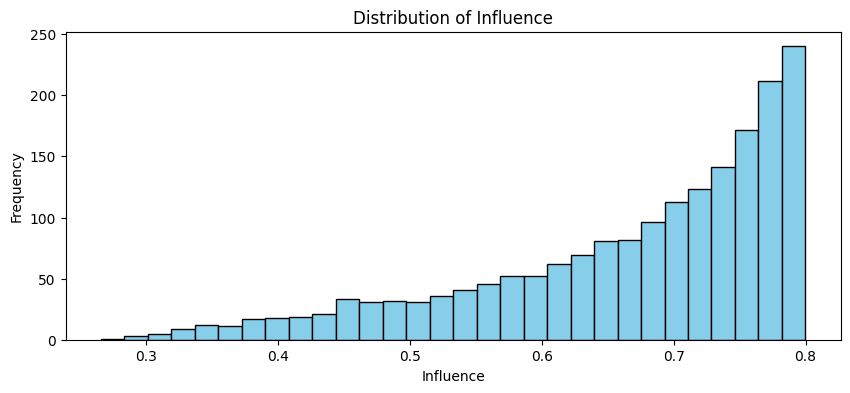

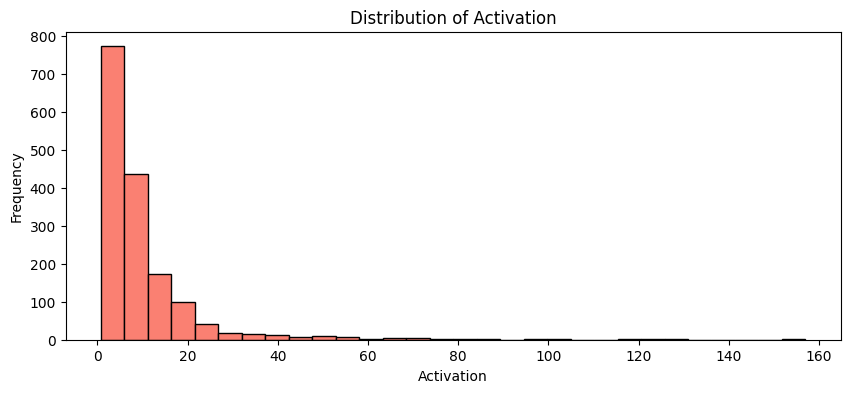

In [6]:
import matplotlib.pyplot as plt

# Assume 'academy_awards' is a dictionary with a 'nodes' key which is a list of node dicts
def safe_int(val):
    try:
        return int(val)
    except (ValueError, TypeError):
        return 0
nodes = academy_awards['nodes']
# Remove nodes based on the given criteria
filtered_nodes = [
    node for node in nodes
    if (safe_int(node.get('layer', 0)) >= 3 and safe_int(node.get('layer', 0)) <= 25)
]
nodes = filtered_nodes

influence_values = [
    node['influence']
    for node in nodes ]
influence_values = [v for v in influence_values if v is not None]

activation_values = [
    node['activation']
    for node in nodes ]
activation_values = [v for v in activation_values if v is not None]


# Plot distribution of influence
plt.figure(figsize=(10, 4))
plt.hist(influence_values, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Influence')
plt.xlabel('Influence')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of activation
plt.figure(figsize=(10, 4))
plt.hist(activation_values, bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of Activation')
plt.xlabel('Activation')
plt.ylabel('Frequency')
plt.show()

In [72]:
indian_TEST['metadata']

{'slug': "['IndianPremierLeaguePlayerAuction']_auctioncity",
 'scan': 'mntss/gemma-scope-transcoders',
 'transcoder_list': [],
 'prompt_tokens': ['<bos>',
  'In',
  ' ',
  '2',
  '0',
  '2',
  '4',
  ',',
  ' where',
  ' was',
  ' the',
  ' Indian',
  ' Premier',
  ' League',
  ' Player',
  ' Auction',
  ' held',
  '?',
  ' Answer',
  ':'],
 'prompt': '<bos>In 2024, where was the Indian Premier League Player Auction held? Answer:',
 'node_threshold': 0.8,
 'schema_version': 1}

In [47]:
len(unique_keys_1)

4112

Correlation between node_1 and node_2 influence (by (feature_id, node_id)): 0.2856
Correlation between node_1 and node_2 activation (by (feature_id, node_id)): 0.8456


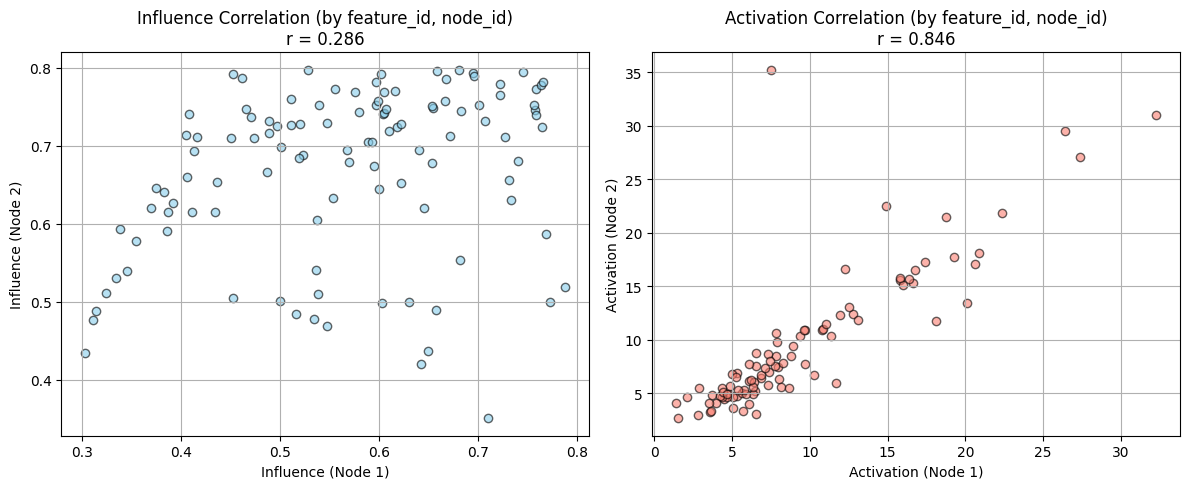

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The unique identifier will be the tuple (feature_id, node_id)
# Both node sets should include 'feature_id' and 'node_id' in their dict

def filter_influence_activation(nodes, context_ids=None):
    """
    Filters nodes based on the existence of 'layer', 'feature', and 'node_id'.
    Optionally filters by a list of context_ids: only nodes whose 'context_id' is in context_ids are included.
    """
    result = {}
    for node in nodes:
        feature_id = node.get('feature')
        node_id = node.get('node_id')
        layer = node.get('layer')
        
        # context_id filter: if list provided, must be in it
        if context_ids is not None:
            context_id = node.get('ctx_idx')
            if context_id not in context_ids:
                continue
        if node.get('layer') is not None and feature_id is not None and node_id is not None:
            key = (feature_id, layer)
            result[key] = {
                'influence': node.get('influence'),
                'activation': node.get('activation'),
                'feature_id': node.get('feature'),
                'layer': node.get('layer'),
                'node_id': node.get('node_id')
            }
    return result

# You should define nodes_set1 and nodes_set2 elsewhere, each node should have 'feature_id' and 'node_id'
filtered1 = filter_influence_activation(indian_TEST['nodes'], [5,6, 7])
filtered2 = filter_influence_activation(indian_PL_TEST['nodes'], [14,15, 16])

# Find the set of (feature_id, node_id) pairs present in both sets
common_ids = set(filtered1.keys()) & set(filtered2.keys())
unique_keys_1 = list(filtered1.keys())
unique_keys_2 = list(filtered2.keys())



# Gather corresponding metrics by (feature_id, node_id)
influence_1 = []
influence_2 = []
activation_1 = []
activation_2 = []

for key in common_ids:
    v1 = filtered1[key]
    v2 = filtered2[key]
    influence_1.append(v1.get('influence'))
    influence_2.append(v2.get('influence'))
    activation_1.append(v1.get('activation'))
    activation_2.append(v2.get('activation'))

influence_1 = np.array(influence_1)
influence_2 = np.array(influence_2)
activation_1 = np.array(activation_1)
activation_2 = np.array(activation_2)

# Remove pairs where either is None or NaN
valid_influence = (~pd.isna(influence_1)) & (~pd.isna(influence_2))
valid_activation = (~pd.isna(activation_1)) & (~pd.isna(activation_2))

influence_1_valid = np.asarray(influence_1[valid_influence], dtype=float).flatten()
influence_2_valid = np.asarray(influence_2[valid_influence], dtype=float).flatten()
activation_1_valid = np.asarray(activation_1[valid_activation], dtype=float).flatten()
activation_2_valid = np.asarray(activation_2[valid_activation], dtype=float).flatten()

# Compute correlations
if len(influence_1_valid) > 1 and len(influence_2_valid) > 1 and len(influence_1_valid) == len(influence_2_valid):
    try:
        corr_matrix = np.corrcoef(influence_1_valid, influence_2_valid)
        corr_influence = corr_matrix[0, 1] if corr_matrix.shape == (2, 2) else np.nan
    except:
        corr_influence = np.nan
else:
    corr_influence = np.nan

if len(activation_1_valid) > 1 and len(activation_2_valid) > 1 and len(activation_1_valid) == len(activation_2_valid):
    try:
        corr_matrix = np.corrcoef(activation_1_valid, activation_2_valid)
        corr_activation = corr_matrix[0, 1] if corr_matrix.shape == (2, 2) else np.nan
    except:
        corr_activation = np.nan
else:
    corr_activation = np.nan

print(f"Correlation between node_1 and node_2 influence (by (feature_id, node_id)): {corr_influence:.4f}")
print(f"Correlation between node_1 and node_2 activation (by (feature_id, node_id)): {corr_activation:.4f}")

# Plot the correlation graphs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(influence_1_valid, influence_2_valid, color='skyblue', edgecolor='black', alpha=0.6)
plt.xlabel('Influence (Node 1)')
plt.ylabel('Influence (Node 2)')
plt.title(f'Influence Correlation (by feature_id, node_id)\nr = {corr_influence:.3f}')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(activation_1_valid, activation_2_valid, color='salmon', edgecolor='black', alpha=0.6)
plt.xlabel('Activation (Node 1)')
plt.ylabel('Activation (Node 2)')
plt.title(f'Activation Correlation (by feature_id, node_id)\nr = {corr_activation:.3f}')
plt.grid(True)

plt.tight_layout()
plt.show()


In [123]:
# Find high correlation keys based on influence ratio
high_corr_keys = []

for key in common_ids:
    inf1 = filtered1[key].get('influence')
    inf2 = filtered2[key].get('influence')
    
    if inf1 is not None and inf2 is not None and not (pd.isna(inf1) or pd.isna(inf2)):
        if inf1 != 0 and inf2 != 0:  # Avoid division by zero
            ratio = abs(inf1 / inf2)
            if 0.9 <= ratio <= 1.1:
                high_corr_keys.append(key)

# Convert high_corr_keys to a dataframe with influence values
high_corr_df = []

for key in high_corr_keys:
    feature_id, layer = key
    inf1 = filtered1[key].get('influence')
    inf2 = filtered2[key].get('influence')
    abs_diff = abs(inf1 - inf2)
    
    high_corr_df.append({
        'feature_id': feature_id,
        'layer': layer,
        'influence_1': inf1,
        'influence_2': inf2,
        'abs_difference': abs_diff
    })

high_corr_df = pd.DataFrame(high_corr_df)
print(high_corr_df)

    feature_id layer  influence_1  influence_2  abs_difference
0      2278037     7     0.653523     0.677200        0.023677
1      2586668     6     0.622814     0.651714        0.028900
2           -1    13     0.646091     0.620329        0.025762
3           -1     3     0.536351     0.540477        0.004125
4    109942198     7     0.682979     0.744773        0.061793
5           -1    17     0.764616     0.723941        0.040675
6      8596715    15     0.758314     0.773208        0.014894
7           -1     4     0.499920     0.500337        0.000416
8           -1     2     0.515950     0.483616        0.032334
9      2584395     5     0.727831     0.710714        0.017117
10    13114878     2     0.701026     0.752507        0.051480
11     4831377     8     0.763985     0.777507        0.013522
12    66418569     5     0.722083     0.778822        0.056740
13    97615371     6     0.722774     0.764788        0.042014
14    18620246     6     0.640455     0.694692        0

In [ ]:
# Get all feature IDs from high_corr_df
feature_ids = high_corr_df['feature_id'].unique().tolist()
filtered1_subset = {k: v for k, v in filtered1.items() if k[0] in feature_ids}
filtered1_subset

In [67]:
graph = attribute(
    prompt=prompt,
    model=model,
    max_n_logits=max_n_logits,
    desired_logit_prob=desired_logit_prob,
    batch_size=batch_size,
    max_feature_nodes=max_feature_nodes,
    offload=offload,
    verbose=verbose
)

Phase 0: Precomputing activations and vectors
Precomputation completed in 0.22s
Found 12871 active features
Phase 1: Running forward pass
Forward pass completed in 1.04s
Phase 2: Building input vectors
Selected 10 logits with cumulative probability 0.8516
Will include 12871 of 12871 feature nodes
Input vectors built in 1.57s
Phase 3: Computing logit attributions
Logit attributions completed in 0.29s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 12871/12871 [00:06<00:00, 2116.13it/s]
Feature attributions completed in 6.09s
Attribution completed in 14.54s


We now have a graph object! We can save it as a .pt file, but be warned that it's large (~167MB).

In [68]:
graph_dir = 'graphs'
graph_name = 'current_president_graph.pt'
graph_dir = Path(graph_dir)
graph_dir.mkdir(exist_ok=True)
graph_path = graph_dir / graph_name

graph.to_pt(graph_path)

Given this object, we can create the graph files that we need to visualize the graph. Give it a slug (name), and set the node / edge thresholds for pruning. Pruning removes unimportant nodes and edges from your graph; lower thresholds (i.e., more aggressive pruning) results in smaller graphs. These may be easier to interpret, but explain less of the model's behavior.

In [69]:
slug = "current-us-president"  # this is the name that you assign to the graph
graph_file_dir = './graph_files'  # where to write the graph files. no need to make this one; create_graph_files does that for you
node_threshold=0.8  # keep only the minimum # of nodes whose cumulative influence is >= 0.8
edge_threshold=0.98  # keep only the minimum # of edges whose cumulative influence is >= 0.98

create_graph_files(
    graph_or_path=graph_path,  # the graph to create files for
    slug=slug,
    output_path=graph_file_dir,
    node_threshold=node_threshold,
    edge_threshold=edge_threshold
)

## Specialised time variantion set

In [12]:
## Import # Prime ministers
df = pd.read_parquet('./chronosalign/chronosalign.parquet')
model_name = "google/gemma-2-2b"
model_short_name = model_name.split('/')[1]

In [13]:
g7_leaders = df[(df['title'] == 'List of G7 leaders') & (df['relationship'] == 'president')]
g7_leaders.reset_index(inplace=True)

In [14]:
g7_leaders['single_answer'] = g7_leaders['answer'].apply(lambda x: str(x.item(0)))
g7_leaders['single_subject'] = g7_leaders['subject'].apply(lambda x: str(x.item(0)))
answers_throughout_time = g7_leaders.groupby('single_subject')['single_answer'].apply(lambda x: list(set(x))).reset_index()
g7_leaders = g7_leaders.merge(answers_throughout_time, on='single_subject', how='left', suffixes=('', '_throughout_time'))
g7_leaders.rename(columns={'single_answer_throughout_time': 'answers_throughout_time'}, inplace=True)


/jobfs/158595849.gadi-pbs/ipykernel_3276734/1735602605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g7_leaders['single_answer'] = g7_leaders['answer'].apply(lambda x: str(x.item(0)))
/jobfs/158595849.gadi-pbs/ipykernel_3276734/1735602605.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g7_leaders['single_subject'] = g7_leaders['subject'].apply(lambda x: str(x.item(0)))


## Time invariant tests

In [7]:
## Import all the datasets required.
# Invariant set from hernandez
# TriviaQa
# GSM8K
from transformers import pipeline, AutoTokenizer, LlamaForCausalLM, AutoModelForCausalLM
model_name = 'google/gemma-2-2b'

tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=hugging_face_cache_dir+'/hub', device_map='auto')
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
original_model = AutoModelForCausalLM.from_pretrained(model_name, cache_dir=hugging_face_cache_dir+'/hub', device_map='auto')

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

#### GMS8K

In [18]:
from alib.evaluation import evaluation_metrics
max_new_tokens= 10
temperature=0.1

gsm8k = pd.read_csv('./gsm8k/gsm8k_test.csv')
gsm8k['numerical_answer'] = gsm8k['answer'].apply(lambda x: x.split('\n####')[1].replace(' ',''))
gsm8k['altered_prompts'] = gsm8k['answer'].apply(lambda x: x + " Answer:")
normal_gsm8k_test = gsm8k.copy()


In [7]:
normal_gsm8k_test.count()

question            1319
answer              1319
numerical_answer    1319
altered_prompts     1319
dtype: int64

In [21]:
## Generate answers

pipe = pipeline("text-generation", original_model=model, tokenizer=tokenizer, max_new_tokens=20, temperature=0.1, batch_size=10)
question_set = normal_gsm8k_test['altered_prompts'].to_list()
output = pipe(question_set)
normal_gsm8k_test['generated_answer'] = output
normal_gsm8k_test['generated_answer'] = normal_gsm8k_test.apply(lambda x: x['generated_answer'][0]['generated_text'].replace(x['altered_prompts'], '').lstrip().split('\n', 1)[0].lower(), axis=1)

## Eval
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer
normal_gsm8k_test['f1_score'] = normal_gsm8k_test.apply(lambda x: eval_metrics._f1_eval_tokens(x['numerical_answer'], x['generated_answer']), axis=1)
normal_gsm8k_test['answer_contained'] = normal_gsm8k_test.apply(lambda x: 1 if x['numerical_answer'] in x['generated_answer'] else 0, axis=1)
normal_gsm8k_test

,question,answer,numerical_answer,altered_prompts,generated_answer,f1_score,answer_contained
0,Janet’s ducks lay 16 eggs per day. She eats th...,Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...,18,Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...,18,1.000000,1
1,A robe takes 2 bolts of blue fiber and half th...,It takes 2/2=<<2/2=1>>1 bolt of white fiber\nS...,3,It takes 2/2=<<2/2=1>>1 bolt of white fiber\nS...,3,1.000000,1
2,Josh decides to try flipping a house. He buys...,The cost of the house and repairs came out to ...,70000,The cost of the house and repairs came out to ...,"70,000",1.000000,0
3,James decides to run 3 sprints 3 times a week....,He sprints 3*3=<<3*3=9>>9 times\nSo he runs 9*...,540,He sprints 3*3=<<3*3=9>>9 times\nSo he runs 9*...,540 meters,0.857143,1
4,"Every day, Wendi feeds each of her chickens th...","If each chicken eats 3 cups of feed per day, t...",20,"If each chicken eats 3 cups of feed per day, t...",20 cups of feed.,0.571429,1
...,...,...,...,...,...,...,...
1314,John had a son James when he was 19. James is...,Dora is 12-3=<<12-3=9>>9\nSo James is 9*2=<<9*...,8,Dora is 12-3=<<12-3=9>>9\nSo James is 9*2=<<9*...,8,1.000000,1
1315,There are some oranges in a basket. Ana spends...,There are 60 minutes in an hour. Ana peels an ...,5,There are 60 minutes in an hour. Ana peels an ...,5,1.000000,1
1316,Mark's car breaks down and he needs to get a n...,The discount on the radiator was 400*.8=$<<400...,230,The discount on the radiator was 400*.8=$<<400...,$230,1.000000,1
1317,"Farmer Brown has 20 animals on his farm, all e...",Let C be the number of chickens.\nThere are 20...,5,Let C be the number of chickens.\nThere are 20...,5 chickens.,0.666667,1


In [13]:
normal_gsm8k_test.agg({'f1_score': 'mean', 'answer_contained': 'mean'})

f1_score            0.804001
answer_contained    0.970432
dtype: float64

In [ ]:

# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

model_name = 'google/gemma-2-2b'
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')
intervention_gsm8k_test = gsm8k.copy()

k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])

generated_answers = []
generations = []

for index, gsm8k_question in intervention_gsm8k_test.iterrows():

    question = gsm8k_question['altered_prompts']
    prompt_properties = tokenizer.tokenize(question)
    ## Create the node
    negative_supernode_features = []
    for temporal_feature in expressive_common_temporal_nodes:
        # if int(temporal_feature['layer']) >=6 & 
        if int(temporal_feature['layer']) <4: #DO NOT CHANGE\
            continue
        for index in range(1, len(prompt_properties)-4):
            negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=index, feature_idx=int(temporal_feature['feature_id'])))
            
    _, activations = model.get_activations(question, sparse=False)
   
    intervention_tuples = []
    intervention_tuples = intervention_tuples + [(*supernode_feature, -2*  (1+activations[supernode_feature])) for supernode_feature in negative_supernode_features]
    
    with torch.inference_mode():
        original_logits = model(question)
        new_logits, activation_cache = model.feature_intervention(question, intervention_tuples, freeze_attention = False)
        generation, _, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
    
    original_tokens = get_topk(original_logits, tokenizer, k)
    new_tokens = get_topk(new_logits, tokenizer, k)

    generated_answers.append((original_tokens, new_tokens))
    generations.append(generation[len(question):].split('\n')[0].strip())



In [ ]:
intervention_gsm8k_test['generated_answer'] = generations

In [22]:
intervention_gsm8k_test.to_csv('./intervention_gsm8k_test.csv')

In [ ]:
## Eval
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer
intervention_gsm8k_test['f1_score'] = intervention_gsm8k_test.apply(lambda x: eval_metrics._f1_eval_tokens(x['numerical_answer'], x['generated_answer']), axis=1)
intervention_gsm8k_test['answer_contained'] = intervention_gsm8k_test.apply(lambda x: 1 if x['numerical_answer'] in x['generated_answer'] else 0, axis=1)
intervention_gsm8k_test

In [ ]:
intervention_gsm8k_test['f1_score'].mean()

In [ ]:
intervention_gsm8k_test['answer_contained'].mean()

### Commonsense set

In [12]:
import pandas as pd

cs_df = pd.read_csv('./commonsense_dataset/commonsense_data.csv')
cs_df['altered_prompts'] = cs_df['prompt'].apply(lambda x: "Answer with a single word. Question:" + x.replace("They are a", "") + " Answer:")
cs_df = cs_df.drop_duplicates(subset='altered_prompts', keep='first')






In [30]:
cs_df

,subject,object,question,filename,prompt,altered_prompts
0,bananas,white,What color are {} on the inside? They are,fruit_inside_color.json,What color are bananas on the inside? They are,Provide a short answer. Question:What color ar...
1,apples,white,What color are {} on the inside? They are,fruit_inside_color.json,What color are apples on the inside? They are,Provide a short answer. Question:What color ar...
2,watermelons,red,What color are {} on the inside? They are,fruit_inside_color.json,What color are watermelons on the inside? They...,Provide a short answer. Question:What color ar...
3,kiwis,green,What color are {} on the inside? They are,fruit_inside_color.json,What color are kiwis on the inside? They are,Provide a short answer. Question:What color ar...
4,dragon fruits,white,What color are {} on the inside? They are,fruit_inside_color.json,What color are dragon fruits on the inside? Th...,Provide a short answer. Question:What color ar...
...,...,...,...,...,...,...
369,surgeon,hospital,A {} typically works at a,work_location.json,A surgeon typically works at a,Provide a short answer. Question:A surgeon typ...
370,trainer,gym,A {} typically works at a,work_location.json,A trainer typically works at a,Provide a short answer. Question:A trainer typ...
371,truck driver,truck,A {} typically works at a,work_location.json,A truck driver typically works at a,Provide a short answer. Question:A truck drive...
372,waitress,restaurant,A {} typically works at a,work_location.json,A waitress typically works at a,Provide a short answer. Question:A waitress ty...


In [ ]:
extracted_df = cs_df[cs_df['filename'] == 'substance_phase.json']
extracted_df

In [14]:
from alib.evaluation import evaluation_metrics
normal_cs_test = cs_df.copy()
## With normal
pipe = pipeline("text-generation", model=original_model, tokenizer=tokenizer, max_new_tokens=20, temperature=0.1, batch_size=10)
question_set = normal_cs_test['altered_prompts'].to_list()
normal_cs_test['answer'] = normal_cs_test['object']
output = pipe(question_set)
normal_cs_test['generated_answer'] = output
normal_cs_test['generated_answer'] = normal_cs_test.apply(lambda x: x['generated_answer'][0]['generated_text'].replace(x['altered_prompts'], '').lstrip().split('\n', 1)[0].lower(), axis=1)

eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer
normal_cs_test['f1_score'] = normal_cs_test.apply(lambda x: eval_metrics._f1_eval_tokens(x['answer'], x['generated_answer']), axis=1)
normal_cs_test['answer_contained'] = normal_cs_test.apply(lambda x: 1 if x['answer'] in x['generated_answer'] else 0, axis=1)


Device set to use cuda:0


In [15]:
normal_cs_test['f1_score'].mean()
# normal_cs_test['answer_contained'].mean()


0.14896926404327587

In [12]:
normal_cs_test['generated_answer']

0                                                yellow.
1                                                   red.
2                                                 green.
3                                                 green.
4                                                   red.
                             ...                        
369    a surgeon typically works at a. hospital. b. c...
370    a. gym b. school c. hospital d. office questio...
371    a truck driver typically works at a. a. 10-hou...
372    100% of the time. question:a waitress typicall...
373            a waiter typically works at a restaurant.
Name: generated_answer, Length: 361, dtype: object

In [14]:
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

model_name = 'google/gemma-2-2b'
save_path = hugging_face_cache_dir + '/local_gemma-2-2b'
tokenizer = AutoTokenizer.from_pretrained(save_path)

k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])

generated_answers = []
generations = []

counter = 0
for index, question_row in cs_df.iterrows():
    question = question_row['altered_prompts']
    prompt_properties = tokenizer.tokenize(question)
    negative_supernode_features = []
    ## Create the node
    for temporal_feature in expressive_common_temporal_nodes:
        # if int(temporal_feature['layer']) >=6 & 
        if int(temporal_feature['layer']) <4: #DO NOT CHANGE\
            continue
        for index in range(1, len(prompt_properties)-4):
            negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=index, feature_idx=int(temporal_feature['feature_id'])))
    activations = None
    _, activations = model.get_activations(question, sparse=False)
   
    intervention_tuples = []
    try:
        intervention_tuples = intervention_tuples + [(*supernode_feature, -2*  (1+activations[supernode_feature])) for supernode_feature in negative_supernode_features]

    except:
        counter = counter +1
        print(question)
        continue
    with torch.inference_mode():
        original_logits = model(question)
        new_logits, activation_cache = model.feature_intervention(question, intervention_tuples, freeze_attention = False)
        generation, _, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
    
    original_tokens = get_topk(original_logits, tokenizer, k)
    new_tokens = get_topk(new_logits, tokenizer, k)

    generated_answers.append((original_tokens, new_tokens))
    generations.append(generation[len(question):].split('\n')[0].strip())

In [15]:
from alib.evaluation import evaluation_metrics
intervention_cs_df_test = cs_df.copy()
intervention_cs_df_test['generated_answer'] = generations
## Eval
eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer
intervention_cs_df_test['f1_score'] = intervention_cs_df_test.apply(lambda x: eval_metrics._f1_eval_tokens(x['object'], x['generated_answer']), axis=1)
intervention_cs_df_test['answer_contained'] = intervention_cs_df_test.apply(lambda x: 1 if x['object'] in x['generated_answer'] else 0, axis=1)
intervention_cs_df_test['f1_score'].mean()


0.2988321927380099

In [16]:
intervention_cs_df_test['answer_contained'].mean()

0.407202216066482

### TriviaQa

In [ ]:
from datasets import load_dataset

# Load the dataset
trivia_qa = load_dataset("mandarjoshi/trivia_qa", name="rc", split="test", streaming=True)
trivia_qa.filter(lambda x: x["answer"]['normalized_value'] != '<unk>')

In [16]:
## Import and inspect set
import pandas as pd
import os
## Produce answers

    

# 9000 questions in the test set
question_batch_size = 1000


   
## Create prompting dataset
parquet_df_1000_alt = pd.read_csv('./TriviaQa/TriviaQa_1000.csv')
parquet_df_1000_alt["question_formed"] = parquet_df_1000_alt["question"].apply(
    lambda x: "Question: " + x + " Answer:" 
)
question_set = parquet_df_1000_alt["question_formed"].to_list()





In [17]:
generated_answer_file_name = f"{model_name.split('/')[1]}_temp_triviaqa_explicit_answers.json"
pipe = pipeline("text-generation", model=original_model, tokenizer=tokenizer, max_new_tokens=10, temperature=0.1, batch_size=20)
output = pipe(question_set)

## Save Answers to json
stored_output = pd.DataFrame(output)
stored_output.to_json(generated_answer_file_name,orient='records')

## Assign answers to taqa_test dataset
processed_data_file_name = f"./TriviaQa/{model_name.split('/')[1]}_triviaqa_explicit_with_answers.json"

imported_answers = pd.read_json(generated_answer_file_name)
parquet_df_1000_alt['generated_answer'] = imported_answers.apply(lambda x: x[0]['generated_text'], axis=1)
parquet_df_1000_alt['generated_answer'] = parquet_df_1000_alt.apply(lambda x: x['generated_answer'].replace(x['question_formed'], '').split(':')[0].lstrip().split('\n', 1)[0].lower(), axis=1)
parquet_df_1000_alt.to_json(processed_data_file_name, orient='records')


eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer
parquet_df_1000_alt['f1_score'] = parquet_df_1000_alt.apply(lambda x: eval_metrics._f1_eval_tokens(x['normalized_value'], x['answer']), axis=1)

Device set to use cuda:0


In [18]:
parquet_df_1000_alt['f1_score'].mean()

0.03885869297627045

In [48]:
# Intervention:
from collections import namedtuple

from transformers import AutoTokenizer
from utils import display_topk_token_predictions, display_generations_comparison, get_topk, get_logit_cumulative_probability

model_name = 'google/gemma-2-2b'
tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')




k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])


generated_answers = []
generations = []

counter = 0
for index, question_row in parquet_df_1000_alt.head(10).iterrows():
    question = question_row['question_formed']
    negative_supernode_features = []
    prompt_properties = tokenizer.tokenize(question)
    ## Create the node
    for temporal_feature in expressive_common_temporal_nodes:
        # if int(temporal_feature['layer']) >=6 & 
        if int(temporal_feature['layer']) <4: #DO NOT CHANGE\
            continue
        for index in range(1, len(prompt_properties)-4):
            negative_supernode_features.append(Feature(layer=int(temporal_feature['layer']), pos=index, feature_idx=int(temporal_feature['feature_id'])))
            
    _, activations = model.get_activations(question, sparse=False)
   
    intervention_tuples = []
    try:
        intervention_tuples = intervention_tuples + [(*supernode_feature, -2*  (1+activations[supernode_feature])) for supernode_feature in negative_supernode_features]

    except:
        counter = counter +1
        print('issue')
        continue
    with torch.inference_mode():
        original_logits = model(question)
        new_logits, activation_cache = model.feature_intervention(question, intervention_tuples, freeze_attention = False)
        generation, _, _ = model.feature_intervention_generate(question, intervention_tuples, freeze_attention = False, temperature=0.1, max_new_tokens=10, verbose = False)
    
    original_tokens = get_topk(original_logits, tokenizer, k)
    new_tokens = get_topk(new_logits, tokenizer, k)

    generated_answers.append((original_tokens, new_tokens))
    generations.append(generation[len(question):].split('\n')[0].strip())

In [49]:
parquet_df_1000_alt['generated_answer'] = generation
parquet_df_1000_alt['generated_answer'] = parquet_df_1000_alt.apply(lambda x: x['generated_answer'].replace(x['question_formed'], '').split(':')[0].lstrip().split('\n', 1)[0].lower(), axis=1)
parquet_df_1000_alt.to_json(processed_data_file_name, orient='records')

eval_metrics = evaluation_metrics()
eval_metrics.tokenizer = tokenizer
parquet_df_1000_alt['f1_score'] = parquet_df_1000_alt.apply(lambda x: eval_metrics._f1_eval_tokens(x['normalized_value'], x['answer']), axis=1)


['Operation Frequent Wind.',
 '"The maid of Orleans was the wife of the',
 '1825.',
 'Mikhail Gorbachev.',
 'Strasbourg, France.',
 'French.',
 'The United States.',
 '"Ford Motor Company."',
 'Algeria.',
 '"Rabbit" is the nickname of the main character']

In [ ]:
parquet_df_1000_alt['f1_score'].mean()

In [84]:
avg_diff = sum(a - b for a, b in cumulative_probs) / len(cumulative_probs)
avg_diff

0.00044830488131538006

In [ ]:

display_topk_token_predictions(prompt, original_logits, new_logits, tokenizer)
old_probs, new_probs = get_logit_cumulative_probability(original_logits, new_logits,["Jonas", "Tadej"], tokenizer)
print(old_probs)
print(new_probs)

In [ ]:
expressive_nodes = []
for layer,feature  in filtered1_subset.items():
    # print(feature)
    if feature['layer'] != '6':
        continue
    node_id_parts = feature['node_id'].split('_')
    layer = node_id_parts[0]
    feature_id = node_id_parts[1]
    pos = node_id_parts[2]
    expressive_nodes.append({'layer': int(layer), 'feature_id': int(feature_id), 'pos': int(pos)})
print(expressive_nodes)

[{'layer': 6, 'feature_id': 234, 'pos': 7}, {'layer': 6, 'feature_id': 2267, 'pos': 6}, {'layer': 6, 'feature_id': 3276, 'pos': 6}, {'layer': 6, 'feature_id': 5185, 'pos': 6}, {'layer': 6, 'feature_id': 6095, 'pos': 6}, {'layer': 6, 'feature_id': 9865, 'pos': 7}, {'layer': 6, 'feature_id': 13965, 'pos': 6}, {'layer': 0, 'feature_id': 6, 'pos': 7}]


In [ ]:
# Intervention:
from collections import namedtuple
from utils import display_topk_token_predictions, display_generations_comparison, get_topk

tokenizer = AutoTokenizer.from_pretrained(model_name, device_map='auto')
prompt = "who won the most recent F1 drivers championship? Answer:"
k = 5
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])

results = []  # Store results for each feature

for feature in expressive_nodes:
    supernode_features = [
        Feature(layer=feature['layer'], pos=5, feature_idx=int(feature['feature_id'])),    
        Feature(layer=feature['layer'], pos=6, feature_idx=int(feature['feature_id'])),    
        Feature(layer=feature['layer'], pos=7, feature_idx=int(feature['feature_id'])),    
        
    ]
    
    _, activations = model.get_activations(prompt, sparse=True)
    
    intervention_tuples = [(*supernode_feature, 5000 + activations[supernode_feature]) for supernode_feature in supernode_features]
    
    with torch.inference_mode():
        original_logits = model(prompt)
        new_logits, _ = model.feature_intervention(prompt, intervention_tuples)
    
    original_tokens = get_topk(original_logits, tokenizer, k)
    new_tokens = get_topk(new_logits, tokenizer, k)
    
    # Store results
    results.append({
        'feature': feature,
        'original_tokens': original_tokens,
        'new_tokens': new_tokens
    })


In [ ]:
results

In [ ]:
from utils import display_topk_token_predictions, display_generations_comparison, get_topk
k = 5
original_tokens = get_topk(original_logits, tokenizer, k)
new_tokens = get_topk(new_logits, tokenizer, k)

In [ ]:
original_tokens

[(' Lance', 0.1337890625),
 (' Chris', 0.10400390625),
 (' ', 0.0712890625),
 (' The', 0.0712890625),
 ('\n\n', 0.0556640625)]

In [ ]:
new_tokens

[(' Lance', 0.22265625),
 (' Chris', 0.08154296875),
 (' ', 0.072265625),
 (' The', 0.072265625),
 ('\n\n', 0.043701171875)]

In [ ]:
from transformers import  AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name,  device_map='auto')
with torch.inference_mode():
    original_logits = model(prompt)
    new_logits, _ = model.feature_intervention(prompt, intervention_tuples)

display_topk_token_predictions(prompt, original_logits, new_logits, tokenizer)

Token,Probability,Distribution
Lance,0.134,13.4%
Chris,0.104,10.4%
,0.071,7.1%
The,0.071,7.1%
,0.056,5.6%
Token,Probability,Distribution
Lance,0.223,22.3%
Chris,0.082,8.2%
,0.072,7.2%
The,0.072,7.2%


Once you're done, you can stop the server with the following command.

In [ ]:
# server.stop()

Congrats, you're done! Go to `intervention_demo.ipynb` to see how to perform interventions, or check out `gemma_demo.ipynb` and `llama_demo.ipynb` for examples of worked-out test examples. Read on for a bit more info aabout the Graph class and pruning.

## Graphs

Earlier, you created a graph object. Its adjacency matrix / edge weights are stored in `graph.adjacency_matrix` in a dense format; rows are target nodes and columns are source nodes. The first `len(graph.real_features)` entries of the matrix represent features; the `i`th entry corresponds to the `i`th feature in `graph.real_features`, given in `(layer, position, feature_idx)` format. The next `graph.cfg.n_layers * graph.n_pos` entries are error_nodes. The next `graph.n_pos` entries are token nodes. The final `len(graph.logit_tokens)` entries are logit nodes.

The value of the cell `graph.adjacency_matrix[target, source]` is the direct effect of the source node on the target node. That is, it tells you how much the target node's value would change if the source node were set to 0, while holding the attention patterns, layernorm denominators, and other feature activations constatnt. Thus, if the target node is a feature, this tells you how much the target feature would change; if the target node is a logit, this tells you how much the (de-meaned) value of the logit would change.

Note that `gemma-2-2b` is model (family) that uses logit softcapping. This means that a softcap function, `softcap(x) = t * tanh(x/t)` is used to constrain the logits to fall within (-t, t); `gemma-2-2b` uses `t=30`. For such models, we predict the change in logits *pre-softcap*, as the nonlinearity introduced by softcapping would cause our attribution to yield incorrect / approximate direct effect values.

### Pruning
Given a graph, you might want to prune it, as it will otherwise contain many low-impact nodes and edges that clutter the circuit diagram while adding little information. We enable you to prune nodes by absolute influence, i.e. the total impact that the nodes have on the logits, direct and indirect. The default threshold is 0.8: this means we will keep the minimum number of nodes required to capture 80% of all logit effects. Similarly, the edge_threshold, by default 0.98, means that we will keep the minimum number of edges required to capture 98% of all logit effects.

In [ ]:
from circuit_tracer.graph import prune_graph
prune_graph(graph, node_threshold=0.7, edge_threshold=0.95)